In [3]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_DIR = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")
WORK_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

MAIN_CLASSES = ["Early Blight", "Late Blight", "Healthy"]

def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("-", " ")
    text = text.replace("_", " ")
    text = text.replace("/", " ")
    text = " ".join(text.split())
    return text

def canonicalize_class(folder_name):
    norm = normalize_text(folder_name)

    if "earlyblt" in norm:
        return "Early Blight"
    if "lateblt" in norm:
        return "Late Blight"

    if "early" in norm and "blight" in norm:
        return "Early Blight"
    if "late" in norm and "blight" in norm:
        return "Late Blight"
    if "healthy" in norm:
        return "Healthy"

    return None

def infer_dataset_role(path):
    text = normalize_text(path)

    # Hard field / real target
    if "irishpotato" in text or "irish potato" in text:
        return "target_hard_irish"

    # Mild cross-dataset target
    if "potato leaf disease" in text:
        return "target_mild_pld"

    # Clean source dataset
    if "potato disease dataset" in text:
        return "source_clean"

    return "unknown"

rows = []

print("Scanning all Kaggle input image folders...\n")

for dataset_path in sorted(INPUT_DIR.iterdir()):
    if not dataset_path.is_dir():
        continue

    for root, dirs, files in os.walk(dataset_path):
        root_path = Path(root)
        image_files = [f for f in files if f.lower().endswith(IMAGE_EXTS)]

        if image_files:
            raw_class = root_path.name
            canonical_class = canonicalize_class(raw_class)
            dataset_role = infer_dataset_role(str(root_path))

            print(
                f"{root_path} -> {len(image_files)} images | "
                f"raw_class={raw_class} | mapped={canonical_class} | role={dataset_role}"
            )

            for f in image_files:
                rows.append({
                    "file_path": str(root_path / f),
                    "dataset_role": dataset_role,
                    "raw_class": raw_class,
                    "canonical_class": canonical_class
                })

df_all = pd.DataFrame(rows)

print("\nTotal images found:", len(df_all))

summary = (
    df_all.groupby(["dataset_role", "canonical_class"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_role", "canonical_class"])
)

print("\nSummary:")
display(summary)

df_all.to_csv(WORK_DIR / "all_image_manifest_raw.csv", index=False)
print("\nSaved:", WORK_DIR / "all_image_manifest_raw.csv")

Scanning all Kaggle input image folders...

/kaggle/input/datasets/manhhoangvan/irishpotato/earlyblt/earlyblt -> 17772 images | raw_class=earlyblt | mapped=Early Blight | role=target_hard_irish
/kaggle/input/datasets/manhhoangvan/irishpotato/lateblt/lateblt -> 20499 images | raw_class=lateblt | mapped=Late Blight | role=target_hard_irish
/kaggle/input/datasets/manhhoangvan/irishpotato/healthy/healthy -> 20438 images | raw_class=healthy | mapped=Healthy | role=target_hard_irish
/kaggle/input/datasets/shahadhossin567r7455/potato-leaf-disease-dataset/Potato Leaf DIsease/Potato Cyst Nematode -> 500 images | raw_class=Potato Cyst Nematode | mapped=None | role=target_mild_pld
/kaggle/input/datasets/shahadhossin567r7455/potato-leaf-disease-dataset/Potato Leaf DIsease/Potato Virus -> 500 images | raw_class=Potato Virus | mapped=None | role=target_mild_pld
/kaggle/input/datasets/shahadhossin567r7455/potato-leaf-disease-dataset/Potato Leaf DIsease/Plant Pests -> 500 images | raw_class=Plant Pest

,dataset_role,canonical_class,count
0,target_hard_irish,Early Blight,17772
1,target_hard_irish,Healthy,20438
2,target_hard_irish,Late Blight,20499
3,target_mild_pld,Early Blight,500
4,target_mild_pld,Healthy,500
5,target_mild_pld,Late Blight,500
6,target_mild_pld,NaN,2000
7,unknown,Early Blight,1000
8,unknown,Healthy,152
9,unknown,Late Blight,1000



Saved: /kaggle/working/all_image_manifest_raw.csv


In [4]:
# Keep only the three potato classes for closed-set adaptation
df_closed = df_all[df_all["canonical_class"].isin(MAIN_CLASSES)].copy()

source_df = df_closed[df_closed["dataset_role"] == "source_clean"].copy()
target_mild_df = df_closed[df_closed["dataset_role"] == "target_mild_pld"].copy()
target_hard_df = df_closed[df_closed["dataset_role"] == "target_hard_irish"].copy()

# Extra PLD classes for later OOD / Reject analysis
ood_df = df_all[
    (df_all["dataset_role"] == "target_mild_pld") &
    (df_all["canonical_class"].isna())
].copy()

print("Source clean:", len(source_df))
display(source_df["canonical_class"].value_counts())

print("\nTarget mild PLD:", len(target_mild_df))
display(target_mild_df["canonical_class"].value_counts())

print("\nTarget hard Irish:", len(target_hard_df))
display(target_hard_df["canonical_class"].value_counts())

print("\nOOD / extra PLD classes:", len(ood_df))
display(ood_df["raw_class"].value_counts())

source_df.to_csv(WORK_DIR / "source_clean_manifest.csv", index=False)
target_mild_df.to_csv(WORK_DIR / "target_mild_pld_manifest.csv", index=False)
target_hard_df.to_csv(WORK_DIR / "target_hard_irish_manifest.csv", index=False)
ood_df.to_csv(WORK_DIR / "ood_pld_extra_manifest.csv", index=False)

print("\nSaved clean manifests.")

Source clean: 0


Series([], Name: count, dtype: int64)


Target mild PLD: 1500


canonical_class
Early Blight    500
Healthy         500
Late Blight     500
Name: count, dtype: int64


Target hard Irish: 58709


canonical_class
Late Blight     20499
Healthy         20438
Early Blight    17772
Name: count, dtype: int64


OOD / extra PLD classes: 2000


raw_class
Potato Cyst Nematode    500
Potato Virus            500
Plant Pests             500
Fungal Diseases         500
Name: count, dtype: int64


Saved clean manifests.


In [5]:
# Fix source role for the potato-only PlantVillage-style dataset
df_all.loc[
    df_all["file_path"].str.contains("faysalmiah1721758/potato-dataset", case=False, na=False),
    "dataset_role"
] = "source_clean"

# Recreate clean closed-set manifests
MAIN_CLASSES = ["Early Blight", "Late Blight", "Healthy"]

df_closed = df_all[df_all["canonical_class"].isin(MAIN_CLASSES)].copy()

source_df = df_closed[df_closed["dataset_role"] == "source_clean"].copy()
target_mild_df = df_closed[df_closed["dataset_role"] == "target_mild_pld"].copy()
target_hard_df = df_closed[df_closed["dataset_role"] == "target_hard_irish"].copy()

ood_df = df_all[
    (df_all["dataset_role"] == "target_mild_pld") &
    (df_all["canonical_class"].isna())
].copy()

print("Source clean:", len(source_df))
display(source_df["canonical_class"].value_counts())

print("\nTarget mild PLD:", len(target_mild_df))
display(target_mild_df["canonical_class"].value_counts())

print("\nTarget hard Irish:", len(target_hard_df))
display(target_hard_df["canonical_class"].value_counts())

print("\nOOD / extra PLD classes:", len(ood_df))
display(ood_df["raw_class"].value_counts())

source_df.to_csv(WORK_DIR / "source_clean_manifest.csv", index=False)
target_mild_df.to_csv(WORK_DIR / "target_mild_pld_manifest.csv", index=False)
target_hard_df.to_csv(WORK_DIR / "target_hard_irish_manifest.csv", index=False)
ood_df.to_csv(WORK_DIR / "ood_pld_extra_manifest.csv", index=False)

print("\nSaved corrected clean manifests.")

Source clean: 2152


canonical_class
Late Blight     1000
Early Blight    1000
Healthy          152
Name: count, dtype: int64


Target mild PLD: 1500


canonical_class
Early Blight    500
Healthy         500
Late Blight     500
Name: count, dtype: int64


Target hard Irish: 58709


canonical_class
Late Blight     20499
Healthy         20438
Early Blight    17772
Name: count, dtype: int64


OOD / extra PLD classes: 2000


raw_class
Potato Cyst Nematode    500
Potato Virus            500
Plant Pests             500
Fungal Diseases         500
Name: count, dtype: int64


Saved corrected clean manifests.


In [6]:
from sklearn.model_selection import train_test_split

CLASS_TO_ID = {
    "Early Blight": 0,
    "Late Blight": 1,
    "Healthy": 2
}

def add_label_id(df):
    df = df.copy()
    df["label"] = df["canonical_class"].map(CLASS_TO_ID)
    return df

source_df = add_label_id(source_df)
target_mild_df = add_label_id(target_mild_df)
target_hard_df = add_label_id(target_hard_df)

def stratified_split(df, test_size, seed=42):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df["label"],
        random_state=seed
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

# Source split: train / val / test = 70 / 15 / 15
source_train_df, source_temp_df = stratified_split(source_df, test_size=0.30, seed=SEED)
source_val_df, source_test_df = stratified_split(source_temp_df, test_size=0.50, seed=SEED)

# Target mild split: train unlabeled / test labeled = 70 / 30
target_mild_train_df, target_mild_test_df = stratified_split(target_mild_df, test_size=0.30, seed=SEED)

# For Irish, make a balanced manageable split first.
# This avoids overloading Kaggle during development.
def balanced_sample(df, per_class, seed=42):
    return (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(n=min(per_class, len(x)), random_state=seed))
          .reset_index(drop=True)
    )

target_hard_balanced_df = balanced_sample(target_hard_df, per_class=3000, seed=SEED)

# Hard target split: 2400/class train unlabeled, 600/class test labeled
target_hard_train_df, target_hard_test_df = stratified_split(
    target_hard_balanced_df,
    test_size=0.20,
    seed=SEED
)

# OOD set: keep all 2000 extra PLD images for later Reject/OOD analysis
ood_test_df = ood_df.copy()

splits = {
    "source_train": source_train_df,
    "source_val": source_val_df,
    "source_test": source_test_df,
    "target_mild_train_unlabeled": target_mild_train_df,
    "target_mild_test_labeled": target_mild_test_df,
    "target_hard_train_unlabeled": target_hard_train_df,
    "target_hard_test_labeled": target_hard_test_df,
    "ood_extra_test": ood_test_df
}

for name, df in splits.items():
    print("\n" + "="*70)
    print(name, ":", len(df))
    if "label" in df.columns:
        display(df["canonical_class"].value_counts())
    elif "raw_class" in df.columns:
        display(df["raw_class"].value_counts())
    df.to_csv(WORK_DIR / f"{name}.csv", index=False)

print("\nAll split CSV files saved to /kaggle/working/")


source_train : 1506


/tmp/ipykernel_58/1739808543.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(per_class, len(x)), random_state=seed))


canonical_class
Early Blight    700
Late Blight     700
Healthy         106
Name: count, dtype: int64


source_val : 323


canonical_class
Late Blight     150
Early Blight    150
Healthy          23
Name: count, dtype: int64

...


target_hard_test_labeled : 1800


canonical_class
Late Blight     600
Early Blight    600
Healthy         600
Name: count, dtype: int64


ood_extra_test : 2000


raw_class
Potato Cyst Nematode    500
Potato Virus            500
Plant Pests             500
Fungal Diseases         500
Name: count, dtype: int64


All split CSV files saved to /kaggle/working/


In [7]:
from pathlib import Path
import pandas as pd

WORK_DIR = Path("/kaggle/working")

split_names = [
    "source_train",
    "source_val",
    "source_test",
    "target_mild_train_unlabeled",
    "target_mild_test_labeled",
    "target_hard_train_unlabeled",
    "target_hard_test_labeled",
    "ood_extra_test"
]

splits = {
    name: pd.read_csv(WORK_DIR / f"{name}.csv")
    for name in split_names
}

# Check file-path overlap between splits
for i, name_i in enumerate(split_names):
    paths_i = set(splits[name_i]["file_path"])
    for name_j in split_names[i+1:]:
        paths_j = set(splits[name_j]["file_path"])
        overlap = paths_i.intersection(paths_j)
        if overlap:
            print(f"WARNING: overlap between {name_i} and {name_j}: {len(overlap)}")
        else:
            print(f"OK: no overlap between {name_i} and {name_j}")

print("\nDone leakage check.")

OK: no overlap between source_train and source_val
OK: no overlap between source_train and source_test
OK: no overlap between source_train and target_mild_train_unlabeled
OK: no overlap between source_train and target_mild_test_labeled
OK: no overlap between source_train and target_hard_train_unlabeled
OK: no overlap between source_train and target_hard_test_labeled
OK: no overlap between source_train and ood_extra_test
OK: no overlap between source_val and source_test
OK: no overlap between source_val and target_mild_train_unlabeled
OK: no overlap between source_val and target_mild_test_labeled
OK: no overlap between source_val and target_hard_train_unlabeled
OK: no overlap between source_val and target_hard_test_labeled
OK: no overlap between source_val and ood_extra_test
OK: no overlap between source_test and target_mild_train_unlabeled
OK: no overlap between source_test and target_mild_test_labeled
OK: no overlap between source_test and target_hard_train_unlabeled
OK: no overlap be

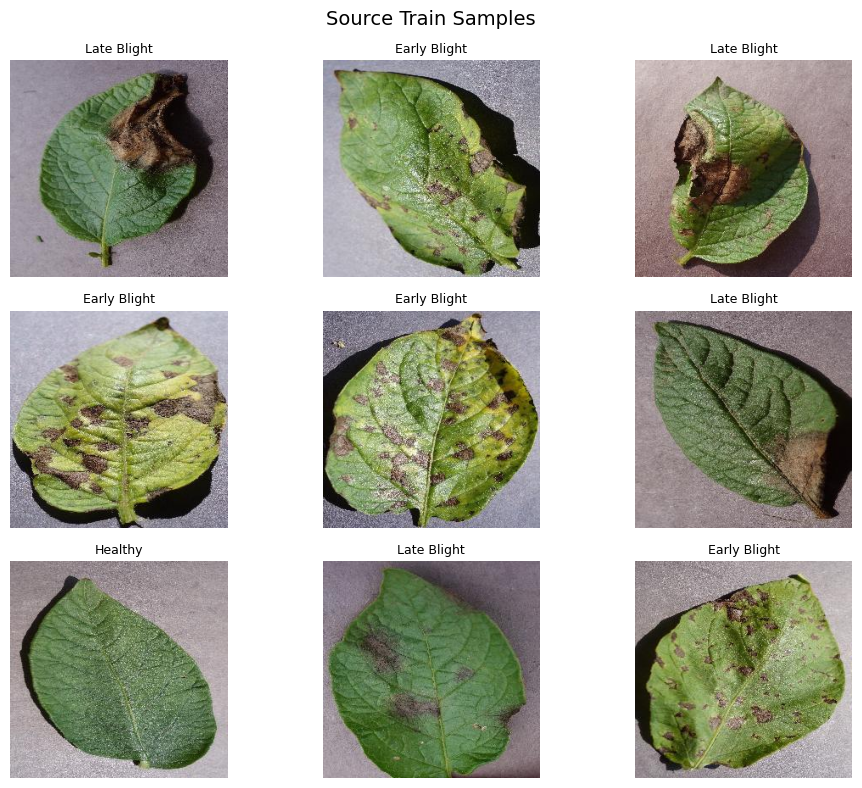

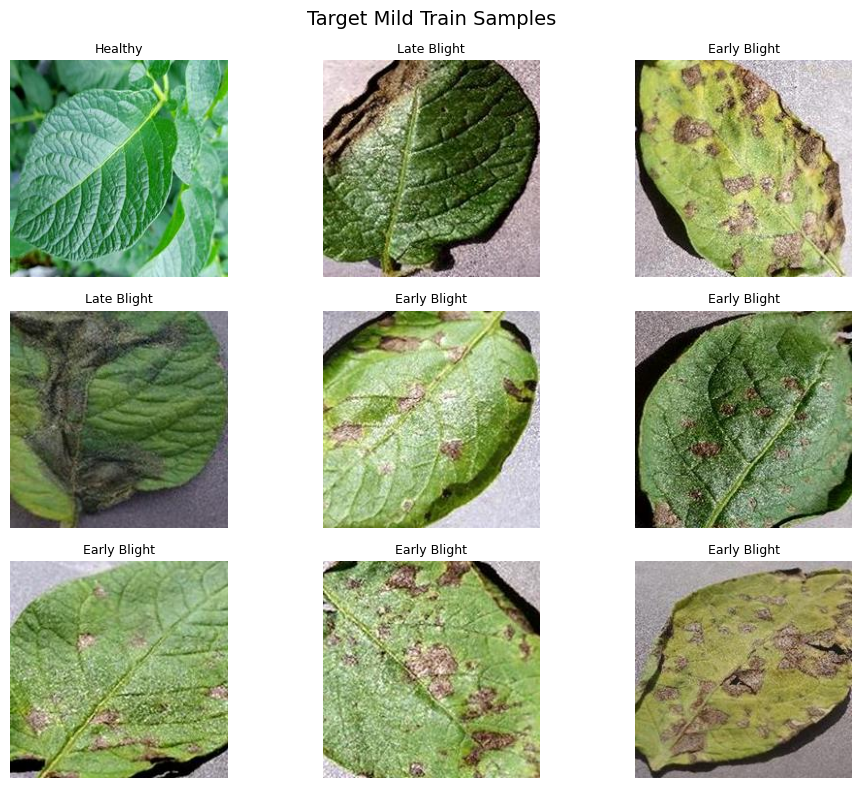

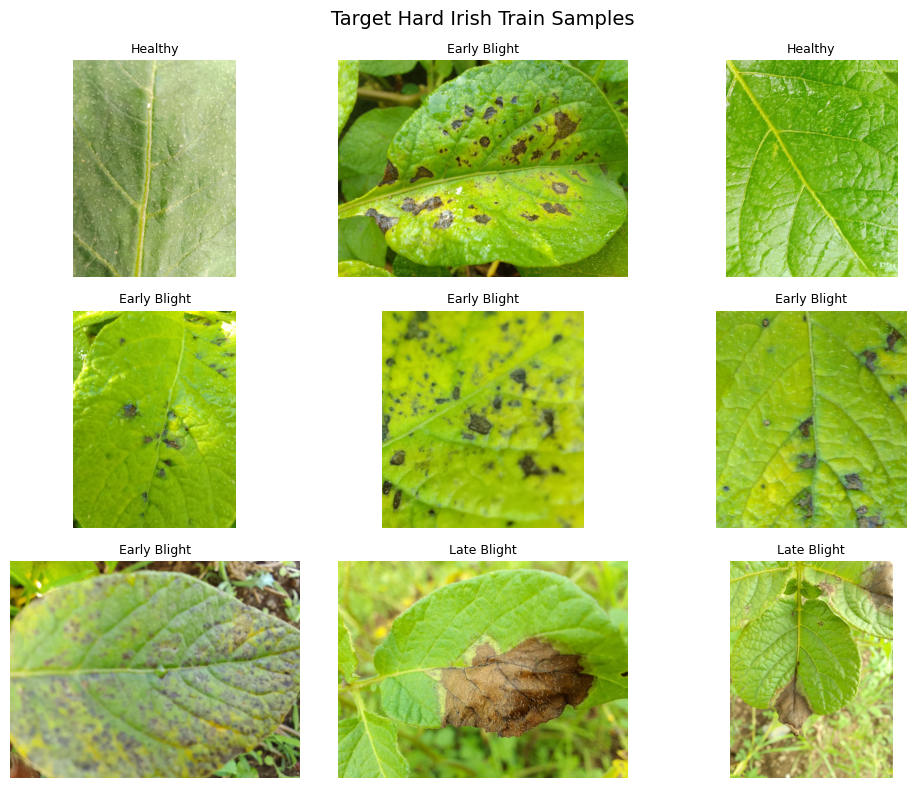

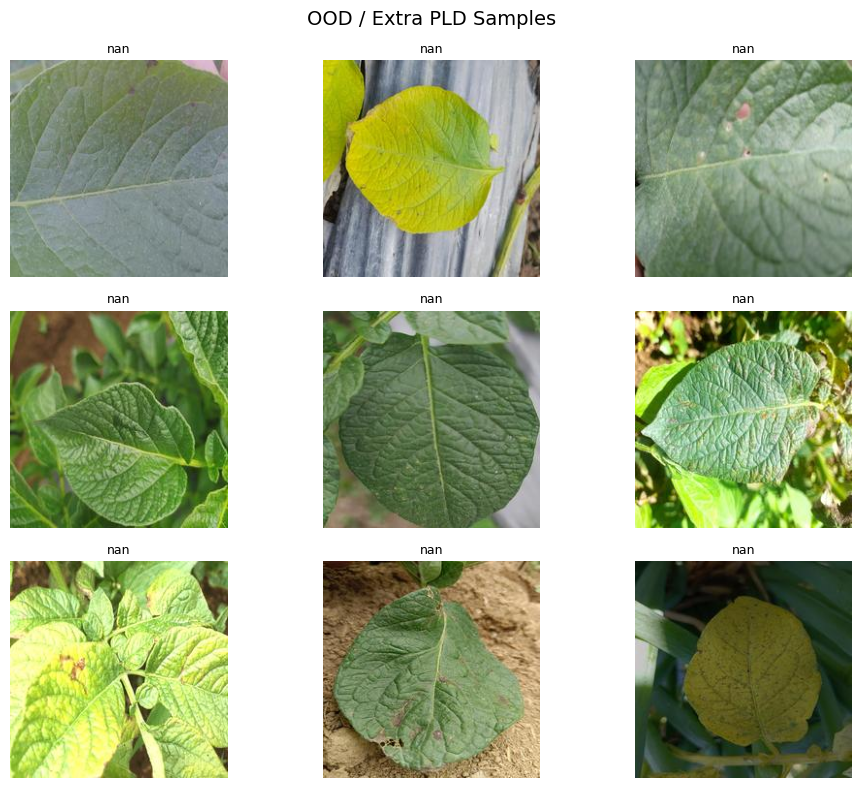

In [8]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_samples(df, title, n=9):
    sample_df = df.sample(n=min(n, len(df)), random_state=42)

    plt.figure(figsize=(10, 8))
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["file_path"]).convert("RGB")
        plt.subplot(3, 3, idx + 1)
        plt.imshow(img)
        label = row.get("canonical_class", row.get("raw_class", ""))
        plt.title(str(label), fontsize=9)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples(splits["source_train"], "Source Train Samples")
show_samples(splits["target_mild_train_unlabeled"], "Target Mild Train Samples")
show_samples(splits["target_hard_train_unlabeled"], "Target Hard Irish Train Samples")
show_samples(splits["ood_extra_test"], "OOD / Extra PLD Samples")

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

source_train_df = splits["source_train"]

classes = np.array([0, 1, 2])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=source_train_df["label"].values
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Class weights:", class_weights)

Class weights: {0: 0.7171428571428572, 1: 0.7171428571428572, 2: 4.735849056603773}


In [10]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
NUM_CLASSES = len(CLASS_NAMES)

def load_image_labeled(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)

def load_image_unlabeled(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

def make_labeled_ds(df, shuffle=False):
    file_paths = df["file_path"].values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(load_image_labeled, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def make_unlabeled_ds(df, shuffle=False):
    file_paths = df["file_path"].values

    ds = tf.data.Dataset.from_tensor_slices(file_paths)
    ds = ds.map(load_image_unlabeled, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

source_train_ds = make_labeled_ds(splits["source_train"], shuffle=True)
source_val_ds = make_labeled_ds(splits["source_val"], shuffle=False)
source_test_ds = make_labeled_ds(splits["source_test"], shuffle=False)

target_mild_train_unlabeled_ds = make_unlabeled_ds(
    splits["target_mild_train_unlabeled"], shuffle=False
)
target_mild_test_ds = make_labeled_ds(
    splits["target_mild_test_labeled"], shuffle=False
)

target_hard_train_unlabeled_ds = make_unlabeled_ds(
    splits["target_hard_train_unlabeled"], shuffle=False
)
target_hard_test_ds = make_labeled_ds(
    splits["target_hard_test_labeled"], shuffle=False
)

print("TensorFlow datasets created.")

I0000 00:00:1788632053.325666      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788632053.333562      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TensorFlow datasets created.


In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = WORK_DIR / "results_source_only"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def expected_calibration_error(y_true, probs, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == y_true)

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.mean(mask) * abs(bin_acc - bin_conf)

    return float(ece)

def brier_score_multiclass(y_true, probs, num_classes=3):
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))

def nll_score(y_true, probs, eps=1e-12):
    probs = np.clip(probs, eps, 1.0)
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true])))

def predict_dataframe(model, df, batch_size=32):
    infer_ds = make_unlabeled_ds(df, shuffle=False)
    probs = model.predict(infer_ds, verbose=1)
    y_true = df["label"].values.astype(int)
    y_pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)

    pred_df = df.copy()
    pred_df["pred_label"] = y_pred
    pred_df["confidence"] = conf
    for i, cls_name in enumerate(CLASS_NAMES):
        pred_df[f"prob_{cls_name}"] = probs[:, i]

    return y_true, y_pred, probs, pred_df

def evaluate_model_on_df(model, df, dataset_name, model_name):
    y_true, y_pred, probs, pred_df = predict_dataframe(model, df)

    metrics = {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "ece": expected_calibration_error(y_true, probs),
        "brier": brier_score_multiclass(y_true, probs, num_classes=NUM_CLASSES),
        "nll": nll_score(y_true, probs),
    }

    print("\n" + "=" * 80)
    print(f"{model_name} on {dataset_name}")
    print("=" * 80)
    print(metrics)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    pred_path = RESULTS_DIR / f"predictions_{model_name}_{dataset_name}.csv"
    pred_df.to_csv(pred_path, index=False)

    return metrics

In [12]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau

tf.keras.utils.set_random_seed(SEED)

def build_transfer_model(backbone_name, num_classes=3, img_size=224):
    inputs = layers.Input(shape=(img_size, img_size, 3))

    if backbone_name == "ResNet50":
        x = tf.keras.applications.resnet50.preprocess_input(inputs)
        base = tf.keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )

    elif backbone_name == "EfficientNetB0":
        # EfficientNet in tf.keras expects image values in 0-255 range.
        x = tf.keras.applications.efficientnet.preprocess_input(inputs)
        base = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=f"{backbone_name}_potato_source")
    return model, base

In [13]:
def train_source_model(backbone_name):
    print("\n" + "#" * 90)
    print(f"Training source model: {backbone_name}")
    print("#" * 90)

    model, base = build_transfer_model(backbone_name, num_classes=NUM_CLASSES, img_size=IMG_SIZE)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    model_dir = WORK_DIR / f"model_{backbone_name}"
    model_dir.mkdir(parents=True, exist_ok=True)

    callbacks_head = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        CSVLogger(str(model_dir / "history_head.csv"))
    ]

    print("\nStage 1: training classifier head")
    history_head = model.fit(
        source_train_ds,
        validation_data=source_val_ds,
        epochs=20,
        class_weight=class_weights,
        callbacks=callbacks_head,
        verbose=1
    )

    print("\nStage 2: fine-tuning backbone")

    base.trainable = True

    # Keep BatchNorm frozen for stable fine-tuning on small source data.
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    callbacks_ft = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
        CSVLogger(str(model_dir / "history_finetune.csv"))
    ]

    history_ft = model.fit(
        source_train_ds,
        validation_data=source_val_ds,
        epochs=30,
        class_weight=class_weights,
        callbacks=callbacks_ft,
        verbose=1
    )

    model.save(model_dir / f"{backbone_name}_source_model.keras")
    model.save_weights(model_dir / f"{backbone_name}_source_weights.weights.h5")

    print(f"\nSaved model to: {model_dir}")

    return model

In [14]:
all_source_only_metrics = []

trained_models = {}

for backbone in ["ResNet50", "EfficientNetB0"]:
    model = train_source_model(backbone)
    trained_models[backbone] = model

    all_source_only_metrics.append(
        evaluate_model_on_df(model, splits["source_test"], "source_test", backbone)
    )

    all_source_only_metrics.append(
        evaluate_model_on_df(model, splits["target_mild_test_labeled"], "target_mild_test", backbone)
    )

    all_source_only_metrics.append(
        evaluate_model_on_df(model, splits["target_hard_test_labeled"], "target_hard_test", backbone)
    )

metrics_df = pd.DataFrame(all_source_only_metrics)
display(metrics_df)

metrics_path = RESULTS_DIR / "source_only_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\nSaved source-only metrics to:", metrics_path)


##########################################################################################
Training source model: ResNet50
##########################################################################################
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Stage 1: training classifier head
Epoch 1/20
 1/48 ━━━━━━━━━━━━━━━━━━━━ 15:34 20s/step - accuracy: 0.2188 - loss: 2.9624

I0000 00:00:1788632297.383230     161 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 344ms/step - accuracy: 0.7497 - loss: 0.6129 - val_accuracy: 0.9474 - val_loss: 0.1508 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9323 - loss: 0.1790 - val_accuracy: 0.9474 - val_loss: 0.1235 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9522 - loss: 0.1332 - val_accuracy: 0.9690 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9568 - loss: 0.1080 - val_accuracy: 0.9845 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9774 - loss: 0.0732 - val_accuracy: 0.9845 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.9807 - loss: 0.0630 - val_accuracy: 0.9814 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9814 - loss: 0.0574 - val_accura

2026-09-05 18:25:42.602620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:25:42.746784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:25:43.105348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:25:43.250619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:25:43.393228: E external/local_xla/xla/stream_

46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6582 - loss: 0.7970

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 96s 910ms/step - accuracy: 0.9854 - loss: 0.0432 - val_accuracy: 0.9876 - val_loss: 0.0317 - learning_rate: 1.0000e-05
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9927 - loss: 0.0234 - val_accuracy: 0.9938 - val_loss: 0.0165 - learning_rate: 1.0000e-05
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.9954 - loss: 0.0161 - val_accuracy: 0.9938 - val_loss: 0.0137 - learning_rate: 1.0000e-05
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9973 - loss: 0.0120 - val_accuracy: 0.9938 - val_loss: 0.0123 - learning_rate: 1.0000e-05
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9980 - loss: 0.0086 - val_accuracy: 0.9969 - val_loss: 0.0090 - learning_rate: 1.0000e-05
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.9980 - loss: 0.0063 - val_accuracy: 0.9969 - val_loss: 0.0073 - learning_rate: 1.0000e-05
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.9980 - l

2026-09-05 18:32:16.245574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:32:16.382325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:32:16.698169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:32:16.838677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-05 18:32:17.656990: E external/local_xla/xla/stream_

57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step

EfficientNetB0 on target_hard_test
{'model': 'EfficientNetB0', 'dataset': 'target_hard_test', 'accuracy': 0.7155555555555555, 'macro_f1': 0.6762728889522207, 'weighted_f1': 0.6762728889522207, 'ece': 0.17120755372775928, 'brier': 0.38793851195313156, 'nll': 0.6629317998886108}

Classification report:
              precision    recall  f1-score   support

Early Blight     0.5593    0.9433    0.7022       600
 Late Blight     0.8962    0.9500    0.9223       600
     Healthy     1.0000    0.2533    0.4043       600

    accuracy                         0.7156      1800
   macro avg     0.8185    0.7156    0.6763      1800
weighted avg     0.8185    0.7156    0.6763      1800


Confusion matrix:
[[566  34   0]
 [ 30 570   0]
 [416  32 152]]


,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50,source_test,1.000000,1.000000,1.000000,0.000788,0.000074,0.000808
1,ResNet50,target_mild_test,0.908889,0.906619,0.906619,0.074124,0.162400,0.648636
2,ResNet50,target_hard_test,0.836667,0.832527,0.832527,0.107853,0.267570,0.778951
3,EfficientNetB0,source_test,1.000000,1.000000,1.000000,0.002504,0.000357,0.002600
4,EfficientNetB0,target_mild_test,0.895556,0.892603,0.892603,0.072685,0.165743,0.344333
5,EfficientNetB0,target_hard_test,0.715556,0.676273,0.676273,0.171208,0.387939,0.662932



Saved source-only metrics to: /kaggle/working/results_source_only/source_only_metrics.csv


with logits

In [15]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ReduceLROnPlateau
import tensorflow as tf
import numpy as np
import pandas as pd

tf.keras.utils.set_random_seed(SEED)

def build_transfer_model_logits(backbone_name, num_classes=3, img_size=224):
    inputs = layers.Input(shape=(img_size, img_size, 3))

    if backbone_name == "ResNet50":
        x = tf.keras.applications.resnet50.preprocess_input(inputs)
        base = tf.keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )

    elif backbone_name == "EfficientNetB0":
        x = tf.keras.applications.efficientnet.preprocess_input(inputs)
        base = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)

    # Important: no softmax here. This outputs logits.
    logits = layers.Dense(num_classes, activation=None, name="logits")(x)

    model = models.Model(inputs, logits, name=f"{backbone_name}_logit_model")
    return model, base

In [16]:
def train_source_model_logits(backbone_name):
    print("\n" + "#" * 90)
    print(f"Training logit source model: {backbone_name}")
    print("#" * 90)

    model, base = build_transfer_model_logits(
        backbone_name,
        num_classes=NUM_CLASSES,
        img_size=IMG_SIZE
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    model_dir = WORK_DIR / f"logit_model_{backbone_name}"
    model_dir.mkdir(parents=True, exist_ok=True)

    callbacks_head = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        CSVLogger(str(model_dir / "history_head.csv"))
    ]

    print("\nStage 1: training classifier head")
    model.fit(
        source_train_ds,
        validation_data=source_val_ds,
        epochs=20,
        class_weight=class_weights,
        callbacks=callbacks_head,
        verbose=1
    )

    print("\nStage 2: fine-tuning backbone")
    base.trainable = True

    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    callbacks_ft = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
        CSVLogger(str(model_dir / "history_finetune.csv"))
    ]

    model.fit(
        source_train_ds,
        validation_data=source_val_ds,
        epochs=30,
        class_weight=class_weights,
        callbacks=callbacks_ft,
        verbose=1
    )

    model.save(model_dir / f"{backbone_name}_source_logit_model.keras")
    print(f"\nSaved logit model to: {model_dir}")

    return model

In [17]:
def predict_dataframe_logits(model, df, batch_size=32):
    infer_ds = make_unlabeled_ds(df, shuffle=False)

    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    y_true = df["label"].values.astype(int)
    y_pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)

    pred_df = df.copy()
    pred_df["pred_label"] = y_pred
    pred_df["confidence"] = conf

    for i, cls_name in enumerate(CLASS_NAMES):
        pred_df[f"logit_{cls_name}"] = logits[:, i]
        pred_df[f"prob_{cls_name}"] = probs[:, i]

    return y_true, y_pred, probs, logits, pred_df

In [18]:
logit_trained_models = {}

for backbone in ["ResNet50", "EfficientNetB0"]:
    logit_trained_models[backbone] = train_source_model_logits(backbone)


##########################################################################################
Training logit source model: ResNet50
##########################################################################################

Stage 1: training classifier head
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 33s 334ms/step - accuracy: 0.7424 - loss: 0.6564 - val_accuracy: 0.9443 - val_loss: 0.1471 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.9382 - loss: 0.1697 - val_accuracy: 0.9783 - val_loss: 0.0834 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.9575 - loss: 0.1312 - val_accuracy: 0.9659 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.9575 - loss: 0.1086 - val_accuracy: 0.9814 - val_loss: 0.0596 - learning_rate: 0.0010
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.9721 - loss: 0.0750 - val_accuracy: 0.9876 - val_loss: 0.0384 - l

In [21]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

LOGIT_RESULTS_DIR = WORK_DIR / "results_logit_source_only"
LOGIT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def expected_calibration_error(y_true, probs, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == y_true)

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.mean(mask) * abs(bin_acc - bin_conf)

    return float(ece)

def brier_score_multiclass(y_true, probs, num_classes=3):
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))

def nll_score(y_true, probs, eps=1e-12):
    probs = np.clip(probs, eps, 1.0)
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true])))

def predict_dataframe_logits(model, df):
    infer_ds = make_unlabeled_ds(df, shuffle=False)

    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    y_true = df["label"].values.astype(int)
    y_pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)

    pred_df = df.copy()
    pred_df["pred_label"] = y_pred
    pred_df["confidence"] = conf

    for i, cls_name in enumerate(CLASS_NAMES):
        pred_df[f"logit_{cls_name}"] = logits[:, i]
        pred_df[f"prob_{cls_name}"] = probs[:, i]

    return y_true, y_pred, probs, logits, pred_df

def evaluate_logit_model_on_df(model, df, dataset_name, model_name):
    y_true, y_pred, probs, logits, pred_df = predict_dataframe_logits(model, df)

    metrics = {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "ece": expected_calibration_error(y_true, probs),
        "brier": brier_score_multiclass(y_true, probs, num_classes=NUM_CLASSES),
        "nll": nll_score(y_true, probs),
    }

    print("\n" + "=" * 80)
    print(f"{model_name} on {dataset_name}")
    print("=" * 80)
    print(metrics)

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    pred_path = LOGIT_RESULTS_DIR / f"predictions_{model_name}_{dataset_name}.csv"
    pred_df.to_csv(pred_path, index=False)

    return metrics

logit_models = {}

for backbone in ["ResNet50", "EfficientNetB0"]:
    model_path = WORK_DIR / f"logit_model_{backbone}" / f"{backbone}_source_logit_model.keras"
    print("Loading:", model_path)
    logit_models[backbone] = tf.keras.models.load_model(model_path)

all_logit_metrics = []

for backbone, model in logit_models.items():
    all_logit_metrics.append(
        evaluate_logit_model_on_df(model, splits["source_test"], "source_test", backbone)
    )
    all_logit_metrics.append(
        evaluate_logit_model_on_df(model, splits["target_mild_test_labeled"], "target_mild_test", backbone)
    )
    all_logit_metrics.append(
        evaluate_logit_model_on_df(model, splits["target_hard_test_labeled"], "target_hard_test", backbone)
    )

logit_metrics_df = pd.DataFrame(all_logit_metrics)
display(logit_metrics_df)

metrics_path = LOGIT_RESULTS_DIR / "logit_source_only_metrics.csv"
logit_metrics_df.to_csv(metrics_path, index=False)

print("\nSaved logit source-only metrics to:", metrics_path)

Loading: /kaggle/working/logit_model_ResNet50/ResNet50_source_logit_model.keras
Loading: /kaggle/working/logit_model_EfficientNetB0/EfficientNetB0_source_logit_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 492ms/step

ResNet50 on source_test
{'model': 'ResNet50', 'dataset': 'source_test', 'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0, 'ece': 0.0018733141961112482, 'brier': 0.001130220565368894, 'nll': 0.0022658747620880604}

Classification report:
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     1.0000    1.0000    1.0000       150
     Healthy     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       323
   macro avg     1.0000    1.0000    1.0000       323
weighted avg     1.0000    1.0000    1.0000       323


Confusion matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0  23]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step

ResNet50 on target_mild_test
{'model': 'ResNet50', 'datas

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50,source_test,1.000000,1.000000,1.000000,0.001873,0.001130,0.002266
1,ResNet50,target_mild_test,0.893333,0.890609,0.890609,0.088762,0.186112,0.810171
2,ResNet50,target_hard_test,0.813333,0.805141,0.805141,0.131565,0.315410,0.990472
3,EfficientNetB0,source_test,1.000000,1.000000,1.000000,0.001502,0.000227,0.001563
4,EfficientNetB0,target_mild_test,0.886667,0.882789,0.882789,0.079403,0.177108,0.384284
5,EfficientNetB0,target_hard_test,0.729444,0.701220,0.701220,0.157676,0.377752,0.678304



Saved logit source-only metrics to: /kaggle/working/results_logit_source_only/logit_source_only_metrics.csv


In [22]:
TWD_RESULTS_DIR = WORK_DIR / "results_zero_shot_twd"
TWD_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Cost-sensitive example setting
# C = correct pseudo-label, W = wrong pseudo-label
costs = {
    "AC": 0.0,  # accept correct
    "AW": 1.0,  # accept wrong
    "DC": 0.1,  # defer correct
    "DW": 0.2,  # defer wrong
    "RC": 0.2,  # reject correct
    "RW": 0.0   # reject wrong
}

def compute_cost_sensitive_thresholds(costs):
    lambda_AC = costs["AC"]
    lambda_AW = costs["AW"]
    lambda_DC = costs["DC"]
    lambda_DW = costs["DW"]
    lambda_RC = costs["RC"]
    lambda_RW = costs["RW"]

    alpha = (lambda_AW - lambda_DW) / (
        (lambda_AW - lambda_DW) + (lambda_DC - lambda_AC)
    )

    beta = (lambda_DW - lambda_RW) / (
        (lambda_DW - lambda_RW) + (lambda_RC - lambda_DC)
    )

    return float(alpha), float(beta)

ALPHA, BETA = compute_cost_sensitive_thresholds(costs)

print("Cost-sensitive thresholds")
print("alpha =", ALPHA)
print("beta  =", BETA)

assert ALPHA > BETA, "alpha must be greater than beta"

Cost-sensitive thresholds
alpha = 0.888888888888889
beta  = 0.6666666666666666


In [24]:
def add_logit_margin(pred_df):
    logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
    logits = pred_df[logit_cols].values

    sorted_logits = np.sort(logits, axis=1)
    margin = sorted_logits[:, -1] - sorted_logits[:, -2]

    pred_df = pred_df.copy()
    pred_df["logit_margin"] = margin
    return pred_df

def assign_twd_region(confidence, alpha=ALPHA, beta=BETA):
    if confidence >= alpha:
        return "Accept"
    elif confidence >= beta:
        return "Defer"
    else:
        return "Reject"

def add_twd_regions(pred_df, alpha=ALPHA, beta=BETA):
    pred_df = pred_df.copy()
    pred_df["region"] = pred_df["confidence"].apply(
        lambda x: assign_twd_region(x, alpha=alpha, beta=beta)
    )

    if "label" in pred_df.columns:
        pred_df["correct"] = pred_df["pred_label"] == pred_df["label"]

    pred_df = add_logit_margin(pred_df)
    return pred_df

def summarize_twd_regions(pred_df, model_name, dataset_name):
    total = len(pred_df)

    rows = []
    for region in ["Accept", "Defer", "Reject"]:
        sub = pred_df[pred_df["region"] == region]
        row = {
            "model": model_name,
            "dataset": dataset_name,
            "region": region,
            "count": len(sub),
            "coverage": len(sub) / total if total > 0 else 0,
            "mean_confidence": sub["confidence"].mean() if len(sub) > 0 else np.nan,
            "mean_logit_margin": sub["logit_margin"].mean() if len(sub) > 0 else np.nan,
        }

        if "correct" in pred_df.columns:
            row["region_accuracy"] = sub["correct"].mean() if len(sub) > 0 else np.nan

        rows.append(row)

    return pd.DataFrame(rows)

def classwise_twd_summary(pred_df, model_name, dataset_name):
    if "canonical_class" not in pred_df.columns:
        return pd.DataFrame()

    rows = []
    total = len(pred_df)

    for cls in CLASS_NAMES:
        for region in ["Accept", "Defer", "Reject"]:
            sub = pred_df[
                (pred_df["canonical_class"] == cls) &
                (pred_df["region"] == region)
            ]

            row = {
                "model": model_name,
                "dataset": dataset_name,
                "class": cls,
                "region": region,
                "count": len(sub),
                "coverage_total": len(sub) / total if total > 0 else 0,
                "mean_confidence": sub["confidence"].mean() if len(sub) > 0 else np.nan,
            }

            if "correct" in pred_df.columns:
                row["region_accuracy"] = sub["correct"].mean() if len(sub) > 0 else np.nan

            rows.append(row)

    return pd.DataFrame(rows)

In [25]:
diagnosis_sets = {
    "target_mild_train_unlabeled": splits["target_mild_train_unlabeled"],
    "target_mild_test_labeled": splits["target_mild_test_labeled"],
    "target_hard_train_unlabeled": splits["target_hard_train_unlabeled"],
    "target_hard_test_labeled": splits["target_hard_test_labeled"],
}

all_region_summaries = []
all_classwise_summaries = []

for backbone, model in logit_models.items():
    for dataset_name, df in diagnosis_sets.items():
        print("\n" + "=" * 90)
        print(f"Zero-shot TWD diagnosis: {backbone} on {dataset_name}")
        print("=" * 90)

        y_true, y_pred, probs, logits, pred_df = predict_dataframe_logits(model, df)
        pred_df = add_twd_regions(pred_df, alpha=ALPHA, beta=BETA)

        pred_path = TWD_RESULTS_DIR / f"twd_predictions_{backbone}_{dataset_name}.csv"
        pred_df.to_csv(pred_path, index=False)

        region_summary = summarize_twd_regions(pred_df, backbone, dataset_name)
        class_summary = classwise_twd_summary(pred_df, backbone, dataset_name)

        display(region_summary)
        display(class_summary)

        all_region_summaries.append(region_summary)
        all_classwise_summaries.append(class_summary)

region_summary_df = pd.concat(all_region_summaries, ignore_index=True)
classwise_region_summary_df = pd.concat(all_classwise_summaries, ignore_index=True)

region_summary_df.to_csv(TWD_RESULTS_DIR / "zero_shot_twd_region_summary.csv", index=False)
classwise_region_summary_df.to_csv(TWD_RESULTS_DIR / "zero_shot_twd_classwise_summary.csv", index=False)

print("\nSaved:")
print(TWD_RESULTS_DIR / "zero_shot_twd_region_summary.csv")
print(TWD_RESULTS_DIR / "zero_shot_twd_classwise_summary.csv")


Zero-shot TWD diagnosis: ResNet50 on target_mild_train_unlabeled
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step


,model,dataset,region,count,coverage,mean_confidence,mean_logit_margin,region_accuracy
0,ResNet50,target_mild_train_unlabeled,Accept,998,0.950476,0.996972,15.095293,0.903808
1,ResNet50,target_mild_train_unlabeled,Defer,27,0.025714,0.802501,1.634702,0.555556
2,ResNet50,target_mild_train_unlabeled,Reject,25,0.023810,0.588502,0.523519,0.400000


,model,dataset,class,region,count,coverage_total,mean_confidence,region_accuracy
0,ResNet50,target_mild_train_unlabeled,Early Blight,Accept,349,0.332381,0.998392,0.991404
1,ResNet50,target_mild_train_unlabeled,Early Blight,Defer,0,0.000000,NaN,NaN
2,ResNet50,target_mild_train_unlabeled,Early Blight,Reject,1,0.000952,0.619965,1.000000
3,ResNet50,target_mild_train_unlabeled,Late Blight,Accept,342,0.325714,0.998494,1.000000
4,ResNet50,target_mild_train_unlabeled,Late Blight,Defer,6,0.005714,0.767561,0.666667
5,ResNet50,target_mild_train_unlabeled,Late Blight,Reject,2,0.001905,0.653523,0.500000
6,ResNet50,target_mild_train_unlabeled,Healthy,Accept,307,0.292381,0.993661,0.697068
7,ResNet50,target_mild_train_unlabeled,Healthy,Defer,21,0.020000,0.812484,0.523810
8,ResNet50,target_mild_train_unlabeled,Healthy,Reject,22,0.020952,0.581160,0.363636



Zero-shot TWD diagnosis: ResNet50 on target_mild_test_labeled
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


,model,dataset,region,count,coverage,mean_confidence,mean_logit_margin,region_accuracy
0,ResNet50,target_mild_test_labeled,Accept,425,0.944444,0.997250,15.083461,0.924706
1,ResNet50,target_mild_test_labeled,Defer,14,0.031111,0.826130,1.718198,0.500000
2,ResNet50,target_mild_test_labeled,Reject,11,0.024444,0.545005,0.378067,0.181818


...

,model,dataset,class,region,count,coverage_total,mean_confidence,region_accuracy
0,EfficientNetB0,target_hard_train_unlabeled,Early Blight,Accept,2239,0.310972,0.993971,0.987494
1,EfficientNetB0,target_hard_train_unlabeled,Early Blight,Defer,108,0.015000,0.804686,0.842593
2,EfficientNetB0,target_hard_train_unlabeled,Early Blight,Reject,53,0.007361,0.609484,0.584906
3,EfficientNetB0,target_hard_train_unlabeled,Late Blight,Accept,2074,0.288056,0.988625,0.955159
4,EfficientNetB0,target_hard_train_unlabeled,Late Blight,Defer,228,0.031667,0.803130,0.745614
5,EfficientNetB0,target_hard_train_unlabeled,Late Blight,Reject,98,0.013611,0.590384,0.642857
6,EfficientNetB0,target_hard_train_unlabeled,Healthy,Accept,452,0.062778,0.940509,0.139381
7,EfficientNetB0,target_hard_train_unlabeled,Healthy,Defer,1036,0.143889,0.775952,0.316602
8,EfficientNetB0,target_hard_train_unlabeled,Healthy,Reject,912,0.126667,0.572343,0.434211



Zero-shot TWD diagnosis: EfficientNetB0 on target_hard_test_labeled
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step


,model,dataset,region,count,coverage,mean_confidence,mean_logit_margin,region_accuracy
0,EfficientNetB0,target_hard_test_labeled,Accept,1205,0.669444,0.987720,7.965152,0.880498
1,EfficientNetB0,target_hard_test_labeled,Defer,323,0.179444,0.773967,1.377269,0.414861
2,EfficientNetB0,target_hard_test_labeled,Reject,272,0.151111,0.574150,0.394910,0.433824


,model,dataset,class,region,count,coverage_total,mean_confidence,region_accuracy
0,EfficientNetB0,target_hard_test_labeled,Early Blight,Accept,568,0.315556,0.994510,0.982394
1,EfficientNetB0,target_hard_test_labeled,Early Blight,Defer,20,0.011111,0.779170,0.800000
2,EfficientNetB0,target_hard_test_labeled,Early Blight,Reject,12,0.006667,0.601078,0.500000
3,EfficientNetB0,target_hard_test_labeled,Late Blight,Accept,516,0.286667,0.989150,0.949612
4,EfficientNetB0,target_hard_test_labeled,Late Blight,Defer,45,0.025000,0.795397,0.755556
5,EfficientNetB0,target_hard_test_labeled,Late Blight,Reject,39,0.021667,0.576590,0.589744
6,EfficientNetB0,target_hard_test_labeled,Healthy,Accept,121,0.067222,0.949744,0.107438
7,EfficientNetB0,target_hard_test_labeled,Healthy,Defer,258,0.143333,0.769826,0.325581
8,EfficientNetB0,target_hard_test_labeled,Healthy,Reject,221,0.122778,0.572257,0.402715



Saved:
/kaggle/working/results_zero_shot_twd/zero_shot_twd_region_summary.csv
/kaggle/working/results_zero_shot_twd/zero_shot_twd_classwise_summary.csv


In [26]:
ERROR_ANALYSIS_DIR = WORK_DIR / "results_zero_shot_twd_error_analysis"
ERROR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

def predicted_class_region_summary(pred_df, model_name, dataset_name):
    df = pred_df.copy()
    df["pred_class"] = df["pred_label"].map({0: "Early Blight", 1: "Late Blight", 2: "Healthy"})
    df["true_class"] = df["label"].map({0: "Early Blight", 1: "Late Blight", 2: "Healthy"})

    summary = (
        df.groupby(["region", "pred_class", "true_class"])
        .size()
        .reset_index(name="count")
        .sort_values(["region", "pred_class", "true_class"])
    )

    summary["model"] = model_name
    summary["dataset"] = dataset_name

    return summary

def accepted_error_summary(pred_df, model_name, dataset_name):
    df = pred_df.copy()
    df["pred_class"] = df["pred_label"].map({0: "Early Blight", 1: "Late Blight", 2: "Healthy"})
    df["true_class"] = df["label"].map({0: "Early Blight", 1: "Late Blight", 2: "Healthy"})
    df["correct"] = df["pred_label"] == df["label"]

    accept_df = df[df["region"] == "Accept"].copy()

    summary = (
        accept_df.groupby(["pred_class", "true_class"])
        .size()
        .reset_index(name="count")
        .sort_values(["pred_class", "true_class"])
    )

    summary["model"] = model_name
    summary["dataset"] = dataset_name

    return summary

all_pred_class_summaries = []
all_accept_error_summaries = []

for backbone, model in logit_models.items():
    for dataset_name in ["target_mild_test_labeled", "target_hard_test_labeled"]:
        df = splits[dataset_name]

        print("\n" + "=" * 90)
        print(f"Predicted-class error analysis: {backbone} on {dataset_name}")
        print("=" * 90)

        y_true, y_pred, probs, logits, pred_df = predict_dataframe_logits(model, df)
        pred_df = add_twd_regions(pred_df, alpha=ALPHA, beta=BETA)

        pred_class_summary = predicted_class_region_summary(pred_df, backbone, dataset_name)
        accept_error = accepted_error_summary(pred_df, backbone, dataset_name)

        print("\nRegion x predicted class x true class:")
        display(pred_class_summary)

        print("\nAccepted samples: predicted class x true class:")
        display(accept_error)

        pred_class_summary.to_csv(
            ERROR_ANALYSIS_DIR / f"pred_class_region_{backbone}_{dataset_name}.csv",
            index=False
        )

        accept_error.to_csv(
            ERROR_ANALYSIS_DIR / f"accept_error_{backbone}_{dataset_name}.csv",
            index=False
        )

        all_pred_class_summaries.append(pred_class_summary)
        all_accept_error_summaries.append(accept_error)

all_pred_class_summaries_df = pd.concat(all_pred_class_summaries, ignore_index=True)
all_accept_error_summaries_df = pd.concat(all_accept_error_summaries, ignore_index=True)

all_pred_class_summaries_df.to_csv(
    ERROR_ANALYSIS_DIR / "all_pred_class_region_summary.csv",
    index=False
)

all_accept_error_summaries_df.to_csv(
    ERROR_ANALYSIS_DIR / "all_accept_error_summary.csv",
    index=False
)

print("\nSaved error-analysis files to:", ERROR_ANALYSIS_DIR)


Predicted-class error analysis: ResNet50 on target_mild_test_labeled
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step

Region x predicted class x true class:


,region,pred_class,true_class,count,model,dataset
0,Accept,Early Blight,Early Blight,148,ResNet50,target_mild_test_labeled
1,Accept,Early Blight,Late Blight,2,ResNet50,target_mild_test_labeled
2,Accept,Healthy,Healthy,99,ResNet50,target_mild_test_labeled
3,Accept,Late Blight,Healthy,30,ResNet50,target_mild_test_labeled
4,Accept,Late Blight,Late Blight,146,ResNet50,target_mild_test_labeled
5,Defer,Early Blight,Early Blight,1,ResNet50,target_mild_test_labeled
6,Defer,Early Blight,Healthy,1,ResNet50,target_mild_test_labeled
7,Defer,Healthy,Healthy,5,ResNet50,target_mild_test_labeled
8,Defer,Late Blight,Healthy,6,ResNet50,target_mild_test_labeled
9,Defer,Late Blight,Late Blight,1,ResNet50,target_mild_test_labeled



Accepted samples: predicted class x true class:


,pred_class,true_class,count,model,dataset
0,Early Blight,Early Blight,148,ResNet50,target_mild_test_labeled
1,Early Blight,Late Blight,2,ResNet50,target_mild_test_labeled
2,Healthy,Healthy,99,ResNet50,target_mild_test_labeled
3,Late Blight,Healthy,30,ResNet50,target_mild_test_labeled
4,Late Blight,Late Blight,146,ResNet50,target_mild_test_labeled



Predicted-class error analysis: ResNet50 on target_hard_test_labeled
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step

Region x predicted class x true class:


...


Predicted-class error analysis: EfficientNetB0 on target_hard_test_labeled
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step

Region x predicted class x true class:


,region,pred_class,true_class,count,model,dataset
0,Accept,Early Blight,Early Blight,558,EfficientNetB0,target_hard_test_labeled
1,Accept,Early Blight,Healthy,100,EfficientNetB0,target_hard_test_labeled
2,Accept,Early Blight,Late Blight,26,EfficientNetB0,target_hard_test_labeled
3,Accept,Healthy,Healthy,13,EfficientNetB0,target_hard_test_labeled
4,Accept,Late Blight,Early Blight,10,EfficientNetB0,target_hard_test_labeled
5,Accept,Late Blight,Healthy,8,EfficientNetB0,target_hard_test_labeled
6,Accept,Late Blight,Late Blight,490,EfficientNetB0,target_hard_test_labeled
7,Defer,Early Blight,Early Blight,16,EfficientNetB0,target_hard_test_labeled
8,Defer,Early Blight,Healthy,166,EfficientNetB0,target_hard_test_labeled
9,Defer,Early Blight,Late Blight,11,EfficientNetB0,target_hard_test_labeled



Accepted samples: predicted class x true class:


,pred_class,true_class,count,model,dataset
0,Early Blight,Early Blight,558,EfficientNetB0,target_hard_test_labeled
1,Early Blight,Healthy,100,EfficientNetB0,target_hard_test_labeled
2,Early Blight,Late Blight,26,EfficientNetB0,target_hard_test_labeled
3,Healthy,Healthy,13,EfficientNetB0,target_hard_test_labeled
4,Late Blight,Early Blight,10,EfficientNetB0,target_hard_test_labeled
5,Late Blight,Healthy,8,EfficientNetB0,target_hard_test_labeled
6,Late Blight,Late Blight,490,EfficientNetB0,target_hard_test_labeled



Saved error-analysis files to: /kaggle/working/results_zero_shot_twd_error_analysis


In [27]:
SWEEP_DIR = WORK_DIR / "results_accept_gate_sweep"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

CONF_THRESHOLDS = [0.8889, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]
MARGIN_THRESHOLDS = [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 12.0]

ID_TO_CLASS = {
    0: "Early Blight",
    1: "Late Blight",
    2: "Healthy"
}

def accept_gate_sweep(pred_df, model_name, dataset_name):
    df = pred_df.copy()

    df["correct"] = df["pred_label"] == df["label"]
    df["pred_class"] = df["pred_label"].map(ID_TO_CLASS)
    df["true_class"] = df["label"].map(ID_TO_CLASS)

    rows = []

    for conf_th in CONF_THRESHOLDS:
        for margin_th in MARGIN_THRESHOLDS:
            accept_df = df[
                (df["confidence"] >= conf_th) &
                (df["logit_margin"] >= margin_th)
            ]

            if len(accept_df) == 0:
                acc = np.nan
                healthy_as_disease = np.nan
                accept_healthy_recall = np.nan
            else:
                acc = accept_df["correct"].mean()

                healthy_as_disease = len(
                    accept_df[
                        (accept_df["true_class"] == "Healthy") &
                        (accept_df["pred_class"].isin(["Early Blight", "Late Blight"]))
                    ]
                )

                total_true_healthy = len(df[df["true_class"] == "Healthy"])
                accepted_true_healthy_correct = len(
                    accept_df[
                        (accept_df["true_class"] == "Healthy") &
                        (accept_df["pred_class"] == "Healthy")
                    ]
                )

                accept_healthy_recall = (
                    accepted_true_healthy_correct / total_true_healthy
                    if total_true_healthy > 0 else np.nan
                )

            rows.append({
                "model": model_name,
                "dataset": dataset_name,
                "confidence_threshold": conf_th,
                "margin_threshold": margin_th,
                "accept_count": len(accept_df),
                "accept_coverage": len(accept_df) / len(df),
                "accept_accuracy": acc,
                "healthy_as_disease_count": healthy_as_disease,
                "accepted_correct_healthy_recall": accept_healthy_recall
            })

    return pd.DataFrame(rows)

all_sweep_results = []

for backbone in ["ResNet50", "EfficientNetB0"]:
    for dataset_name in ["target_mild_test_labeled", "target_hard_test_labeled"]:
        pred_path = TWD_RESULTS_DIR / f"twd_predictions_{backbone}_{dataset_name}.csv"
        pred_df = pd.read_csv(pred_path)

        sweep_df = accept_gate_sweep(pred_df, backbone, dataset_name)
        all_sweep_results.append(sweep_df)

        print("\n" + "=" * 90)
        print(f"Accept gate sweep: {backbone} on {dataset_name}")
        print("=" * 90)

        print("\nBest rows with accept accuracy >= 95%, sorted by coverage:")
        display(
            sweep_df[sweep_df["accept_accuracy"] >= 0.95]
            .sort_values("accept_coverage", ascending=False)
            .head(15)
        )

        print("\nOriginal confidence-only setting:")
        display(
            sweep_df[
                (sweep_df["confidence_threshold"] == 0.8889) &
                (sweep_df["margin_threshold"] == 0.0)
            ]
        )

        sweep_df.to_csv(
            SWEEP_DIR / f"accept_gate_sweep_{backbone}_{dataset_name}.csv",
            index=False
        )

all_sweep_results_df = pd.concat(all_sweep_results, ignore_index=True)
all_sweep_results_df.to_csv(SWEEP_DIR / "all_accept_gate_sweep.csv", index=False)

print("\nSaved sweep results to:", SWEEP_DIR)


Accept gate sweep: ResNet50 on target_mild_test_labeled

Best rows with accept accuracy >= 95%, sorted by coverage:


,model,dataset,confidence_threshold,margin_threshold,accept_count,accept_coverage,accept_accuracy,healthy_as_disease_count,accepted_correct_healthy_recall
4,ResNet50,target_mild_test_labeled,0.8889,5.0,393,0.873333,0.954198,18,0.606667
36,ResNet50,target_mild_test_labeled,0.9900,5.0,393,0.873333,0.954198,18,0.606667
20,ResNet50,target_mild_test_labeled,0.9700,5.0,393,0.873333,0.954198,18,0.606667
12,ResNet50,target_mild_test_labeled,0.9500,5.0,393,0.873333,0.954198,18,0.606667
28,ResNet50,target_mild_test_labeled,0.9800,5.0,393,0.873333,0.954198,18,0.606667
44,ResNet50,target_mild_test_labeled,0.9950,5.0,390,0.866667,0.958974,16,0.600000
41,ResNet50,target_mild_test_labeled,0.9950,1.0,390,0.866667,0.958974,16,0.600000
42,ResNet50,target_mild_test_labeled,0.9950,2.0,390,0.866667,0.958974,16,0.600000
43,ResNet50,target_mild_test_labeled,0.9950,3.0,390,0.866667,0.958974,16,0.600000
40,ResNet50,target_mild_test_labeled,0.9950,0.0,390,0.866667,0.958974,16,0.600000



Original confidence-only setting:


,model,dataset,confidence_threshold,margin_threshold,accept_count,accept_coverage,accept_accuracy,healthy_as_disease_count,accepted_correct_healthy_recall
0,ResNet50,target_mild_test_labeled,0.8889,0.0,425,0.944444,0.924706,30,0.66



Accept gate sweep: ResNet50 on target_hard_test_labeled

Best rows with accept accuracy >= 95%, sorted by coverage:


...


Accept gate sweep: EfficientNetB0 on target_hard_test_labeled

Best rows with accept accuracy >= 95%, sorted by coverage:


,model,dataset,confidence_threshold,margin_threshold,accept_count,accept_coverage,accept_accuracy,healthy_as_disease_count,accepted_correct_healthy_recall
27,EfficientNetB0,target_hard_test_labeled,0.9800,3.0,983,0.546111,0.952187,27,0.001667
26,EfficientNetB0,target_hard_test_labeled,0.9800,2.0,983,0.546111,0.952187,27,0.001667
25,EfficientNetB0,target_hard_test_labeled,0.9800,1.0,983,0.546111,0.952187,27,0.001667
24,EfficientNetB0,target_hard_test_labeled,0.9800,0.0,983,0.546111,0.952187,27,0.001667
32,EfficientNetB0,target_hard_test_labeled,0.9900,0.0,913,0.507222,0.968237,13,0.000000
33,EfficientNetB0,target_hard_test_labeled,0.9900,1.0,913,0.507222,0.968237,13,0.000000
34,EfficientNetB0,target_hard_test_labeled,0.9900,2.0,913,0.507222,0.968237,13,0.000000
35,EfficientNetB0,target_hard_test_labeled,0.9900,3.0,913,0.507222,0.968237,13,0.000000
4,EfficientNetB0,target_hard_test_labeled,0.8889,5.0,873,0.485000,0.972509,10,0.000000
12,EfficientNetB0,target_hard_test_labeled,0.9500,5.0,873,0.485000,0.972509,10,0.000000



Original confidence-only setting:


,model,dataset,confidence_threshold,margin_threshold,accept_count,accept_coverage,accept_accuracy,healthy_as_disease_count,accepted_correct_healthy_recall
0,EfficientNetB0,target_hard_test_labeled,0.8889,0.0,1205,0.669444,0.880498,108,0.021667



Saved sweep results to: /kaggle/working/results_accept_gate_sweep


In [28]:
OOD_RESULTS_DIR = WORK_DIR / "results_zero_shot_twd"
OOD_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

all_ood_summaries = []

for backbone, model in logit_models.items():
    print("\n" + "=" * 90)
    print(f"OOD / extra-class TWD diagnosis: {backbone}")
    print("=" * 90)

    ood_tmp = splits["ood_extra_test"].copy()

    # OOD images do not have closed-set labels.
    # We only check predicted class, confidence, and TWD region.
    infer_ds = make_unlabeled_ds(ood_tmp, shuffle=False)
    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    ood_tmp["pred_label"] = np.argmax(probs, axis=1)
    ood_tmp["confidence"] = np.max(probs, axis=1)

    for i, cls_name in enumerate(CLASS_NAMES):
        ood_tmp[f"logit_{cls_name}"] = logits[:, i]
        ood_tmp[f"prob_{cls_name}"] = probs[:, i]

    # Add logit margin
    logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
    sorted_logits = np.sort(ood_tmp[logit_cols].values, axis=1)
    ood_tmp["logit_margin"] = sorted_logits[:, -1] - sorted_logits[:, -2]

    # Assign Accept / Defer / Reject
    ood_tmp["region"] = ood_tmp["confidence"].apply(
        lambda x: assign_twd_region(x, alpha=ALPHA, beta=BETA)
    )

    ood_tmp["pred_class"] = ood_tmp["pred_label"].map({
        0: "Early Blight",
        1: "Late Blight",
        2: "Healthy"
    })

    # Summary by true OOD class and TWD region
    ood_summary = (
        ood_tmp.groupby(["raw_class", "region"])
        .size()
        .reset_index(name="count")
    )

    ood_summary["model"] = backbone
    ood_summary["total_in_raw_class"] = ood_summary.groupby("raw_class")["count"].transform("sum")
    ood_summary["within_class_rate"] = ood_summary["count"] / ood_summary["total_in_raw_class"]

    display(ood_summary)

    # Also check which closed-set class the model predicts for OOD images
    ood_pred_summary = (
        ood_tmp.groupby(["raw_class", "region", "pred_class"])
        .size()
        .reset_index(name="count")
        .sort_values(["raw_class", "region", "pred_class"])
    )

    print("\nOOD predicted class summary:")
    display(ood_pred_summary)

    ood_tmp.to_csv(
        OOD_RESULTS_DIR / f"twd_predictions_{backbone}_ood_extra.csv",
        index=False
    )

    ood_summary.to_csv(
        OOD_RESULTS_DIR / f"ood_region_summary_{backbone}.csv",
        index=False
    )

    ood_pred_summary.to_csv(
        OOD_RESULTS_DIR / f"ood_pred_class_summary_{backbone}.csv",
        index=False
    )

    all_ood_summaries.append(ood_summary)

ood_summary_df = pd.concat(all_ood_summaries, ignore_index=True)
ood_summary_df.to_csv(OOD_RESULTS_DIR / "zero_shot_twd_ood_summary.csv", index=False)

print("\nSaved OOD summary:")
print(OOD_RESULTS_DIR / "zero_shot_twd_ood_summary.csv")


OOD / extra-class TWD diagnosis: ResNet50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step


,raw_class,region,count,model,total_in_raw_class,within_class_rate
0,Fungal Diseases,Accept,373,ResNet50,500,0.746
1,Fungal Diseases,Defer,71,ResNet50,500,0.142
2,Fungal Diseases,Reject,56,ResNet50,500,0.112
3,Plant Pests,Accept,320,ResNet50,500,0.640
4,Plant Pests,Defer,114,ResNet50,500,0.228
5,Plant Pests,Reject,66,ResNet50,500,0.132
6,Potato Cyst Nematode,Accept,338,ResNet50,500,0.676
7,Potato Cyst Nematode,Defer,111,ResNet50,500,0.222
8,Potato Cyst Nematode,Reject,51,ResNet50,500,0.102
9,Potato Virus,Accept,331,ResNet50,500,0.662



OOD predicted class summary:


,raw_class,region,pred_class,count
0,Fungal Diseases,Accept,Early Blight,130
1,Fungal Diseases,Accept,Healthy,3
2,Fungal Diseases,Accept,Late Blight,240
3,Fungal Diseases,Defer,Early Blight,32
4,Fungal Diseases,Defer,Healthy,4
5,Fungal Diseases,Defer,Late Blight,35
6,Fungal Diseases,Reject,Early Blight,24
7,Fungal Diseases,Reject,Healthy,1
8,Fungal Diseases,Reject,Late Blight,31
9,Plant Pests,Accept,Early Blight,121



OOD / extra-class TWD diagnosis: EfficientNetB0
61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step


,raw_class,region,count,model,total_in_raw_class,within_class_rate
0,Fungal Diseases,Accept,320,EfficientNetB0,500,0.640
1,Fungal Diseases,Defer,119,EfficientNetB0,500,0.238
2,Fungal Diseases,Reject,61,EfficientNetB0,500,0.122
3,Plant Pests,Accept,281,EfficientNetB0,500,0.562
4,Plant Pests,Defer,134,EfficientNetB0,500,0.268
5,Plant Pests,Reject,85,EfficientNetB0,500,0.170
6,Potato Cyst Nematode,Accept,287,EfficientNetB0,500,0.574
7,Potato Cyst Nematode,Defer,135,EfficientNetB0,500,0.270
8,Potato Cyst Nematode,Reject,78,EfficientNetB0,500,0.156
9,Potato Virus,Accept,314,EfficientNetB0,500,0.628



OOD predicted class summary:


,raw_class,region,pred_class,count
0,Fungal Diseases,Accept,Early Blight,136
1,Fungal Diseases,Accept,Healthy,5
2,Fungal Diseases,Accept,Late Blight,179
3,Fungal Diseases,Defer,Early Blight,58
4,Fungal Diseases,Defer,Healthy,4
5,Fungal Diseases,Defer,Late Blight,57
6,Fungal Diseases,Reject,Early Blight,29
7,Fungal Diseases,Reject,Healthy,3
8,Fungal Diseases,Reject,Late Blight,29
9,Plant Pests,Accept,Early Blight,154



Saved OOD summary:
/kaggle/working/results_zero_shot_twd/zero_shot_twd_ood_summary.csv


In [29]:
OOD_GATE_DIR = WORK_DIR / "results_ood_gate_sweep"
OOD_GATE_DIR.mkdir(parents=True, exist_ok=True)

CONF_THRESHOLDS = [0.8889, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9995, 0.9999]
MARGIN_THRESHOLDS = [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 12.0, 15.0, 20.0]

def load_prediction_file(backbone, dataset_name):
    path = TWD_RESULTS_DIR / f"twd_predictions_{backbone}_{dataset_name}.csv"
    return pd.read_csv(path)

def ood_accept_gate_sweep(known_df, ood_df, model_name, known_dataset_name):
    known = known_df.copy()
    ood = ood_df.copy()

    known["correct"] = known["pred_label"] == known["label"]
    known["pred_class"] = known["pred_label"].map(ID_TO_CLASS)
    known["true_class"] = known["label"].map(ID_TO_CLASS)

    rows = []

    for conf_th in CONF_THRESHOLDS:
        for margin_th in MARGIN_THRESHOLDS:

            known_accept = known[
                (known["confidence"] >= conf_th) &
                (known["logit_margin"] >= margin_th)
            ]

            ood_accept = ood[
                (ood["confidence"] >= conf_th) &
                (ood["logit_margin"] >= margin_th)
            ]

            if len(known_accept) > 0:
                known_accept_accuracy = known_accept["correct"].mean()

                healthy_as_disease_count = len(
                    known_accept[
                        (known_accept["true_class"] == "Healthy") &
                        (known_accept["pred_class"].isin(["Early Blight", "Late Blight"]))
                    ]
                )
            else:
                known_accept_accuracy = np.nan
                healthy_as_disease_count = np.nan

            rows.append({
                "model": model_name,
                "known_dataset": known_dataset_name,
                "confidence_threshold": conf_th,
                "margin_threshold": margin_th,

                "known_accept_count": len(known_accept),
                "known_accept_coverage": len(known_accept) / len(known),
                "known_accept_accuracy": known_accept_accuracy,
                "healthy_as_disease_count": healthy_as_disease_count,

                "ood_accept_count": len(ood_accept),
                "ood_false_accept_rate": len(ood_accept) / len(ood)
            })

    return pd.DataFrame(rows)

all_ood_gate_results = []

for backbone in ["ResNet50", "EfficientNetB0"]:
    known_df = load_prediction_file(backbone, "target_hard_test_labeled")
    ood_df = pd.read_csv(TWD_RESULTS_DIR / f"twd_predictions_{backbone}_ood_extra.csv")

    sweep_df = ood_accept_gate_sweep(
        known_df=known_df,
        ood_df=ood_df,
        model_name=backbone,
        known_dataset_name="target_hard_test_labeled"
    )

    all_ood_gate_results.append(sweep_df)

    print("\n" + "=" * 90)
    print(f"OOD false-Accept sweep: {backbone}")
    print("=" * 90)

    print("\nBest safe rows: known Accept accuracy >= 95%, sorted by OOD false Accept rate")
    display(
        sweep_df[sweep_df["known_accept_accuracy"] >= 0.95]
        .sort_values(["ood_false_accept_rate", "known_accept_coverage"], ascending=[True, False])
        .head(20)
    )

    print("\nBest balanced rows: known Accept accuracy >= 95%, OOD false Accept <= 30%")
    display(
        sweep_df[
            (sweep_df["known_accept_accuracy"] >= 0.95) &
            (sweep_df["ood_false_accept_rate"] <= 0.30)
        ]
        .sort_values("known_accept_coverage", ascending=False)
        .head(20)
    )

    sweep_df.to_csv(
        OOD_GATE_DIR / f"ood_accept_gate_sweep_{backbone}.csv",
        index=False
    )

all_ood_gate_results_df = pd.concat(all_ood_gate_results, ignore_index=True)
all_ood_gate_results_df.to_csv(OOD_GATE_DIR / "all_ood_accept_gate_sweep.csv", index=False)

print("\nSaved OOD gate sweep to:", OOD_GATE_DIR)


OOD false-Accept sweep: ResNet50

Best safe rows: known Accept accuracy >= 95%, sorted by OOD false Accept rate


,model,known_dataset,confidence_threshold,margin_threshold,known_accept_count,known_accept_coverage,known_accept_accuracy,healthy_as_disease_count,ood_accept_count,ood_false_accept_rate
9,ResNet50,target_hard_test_labeled,0.8889,20.0,87,0.048333,1.000000,0,10,0.0050
19,ResNet50,target_hard_test_labeled,0.9500,20.0,87,0.048333,1.000000,0,10,0.0050
29,ResNet50,target_hard_test_labeled,0.9700,20.0,87,0.048333,1.000000,0,10,0.0050
39,ResNet50,target_hard_test_labeled,0.9800,20.0,87,0.048333,1.000000,0,10,0.0050
49,ResNet50,target_hard_test_labeled,0.9900,20.0,87,0.048333,1.000000,0,10,0.0050
59,ResNet50,target_hard_test_labeled,0.9950,20.0,87,0.048333,1.000000,0,10,0.0050
69,ResNet50,target_hard_test_labeled,0.9990,20.0,87,0.048333,1.000000,0,10,0.0050
79,ResNet50,target_hard_test_labeled,0.9995,20.0,87,0.048333,1.000000,0,10,0.0050
89,ResNet50,target_hard_test_labeled,0.9999,20.0,87,0.048333,1.000000,0,10,0.0050
8,ResNet50,target_hard_test_labeled,0.8889,15.0,289,0.160556,0.986159,3,41,0.0205



Best balanced rows: known Accept accuracy >= 95%, OOD false Accept <= 30%


,model,known_dataset,confidence_threshold,margin_threshold,known_accept_count,known_accept_coverage,known_accept_accuracy,healthy_as_disease_count,ood_accept_count,ood_false_accept_rate
62,ResNet50,target_hard_test_labeled,0.9990,2.0,940,0.522222,0.955319,33,519,0.2595
63,ResNet50,target_hard_test_labeled,0.9990,3.0,940,0.522222,0.955319,33,519,0.2595
60,ResNet50,target_hard_test_labeled,0.9990,0.0,940,0.522222,0.955319,33,519,0.2595
61,ResNet50,target_hard_test_labeled,0.9990,1.0,940,0.522222,0.955319,33,519,0.2595
64,ResNet50,target_hard_test_labeled,0.9990,5.0,940,0.522222,0.955319,33,519,0.2595
45,ResNet50,target_hard_test_labeled,0.9900,7.0,935,0.519444,0.955080,33,522,0.2610
25,ResNet50,target_hard_test_labeled,0.9700,7.0,935,0.519444,0.955080,33,522,0.2610
55,ResNet50,target_hard_test_labeled,0.9950,7.0,935,0.519444,0.955080,33,522,0.2610
5,ResNet50,target_hard_test_labeled,0.8889,7.0,935,0.519444,0.955080,33,522,0.2610
15,ResNet50,target_hard_test_labeled,0.9500,7.0,935,0.519444,0.955080,33,522,0.2610



OOD false-Accept sweep: EfficientNetB0

Best safe rows: known Accept accuracy >= 95%, sorted by OOD false Accept rate


,model,known_dataset,confidence_threshold,margin_threshold,known_accept_count,known_accept_coverage,known_accept_accuracy,healthy_as_disease_count,ood_accept_count,ood_false_accept_rate
8,EfficientNetB0,target_hard_test_labeled,0.8889,15.0,62,0.034444,1.000000,0.0,0,0.0000
18,EfficientNetB0,target_hard_test_labeled,0.9500,15.0,62,0.034444,1.000000,0.0,0,0.0000
28,EfficientNetB0,target_hard_test_labeled,0.9700,15.0,62,0.034444,1.000000,0.0,0,0.0000
38,EfficientNetB0,target_hard_test_labeled,0.9800,15.0,62,0.034444,1.000000,0.0,0,0.0000
48,EfficientNetB0,target_hard_test_labeled,0.9900,15.0,62,0.034444,1.000000,0.0,0,0.0000
58,EfficientNetB0,target_hard_test_labeled,0.9950,15.0,62,0.034444,1.000000,0.0,0,0.0000
68,EfficientNetB0,target_hard_test_labeled,0.9990,15.0,62,0.034444,1.000000,0.0,0,0.0000
78,EfficientNetB0,target_hard_test_labeled,0.9995,15.0,62,0.034444,1.000000,0.0,0,0.0000
88,EfficientNetB0,target_hard_test_labeled,0.9999,15.0,62,0.034444,1.000000,0.0,0,0.0000
7,EfficientNetB0,target_hard_test_labeled,0.8889,12.0,191,0.106111,0.994764,0.0,8,0.0040



Best balanced rows: known Accept accuracy >= 95%, OOD false Accept <= 30%


,model,known_dataset,confidence_threshold,margin_threshold,known_accept_count,known_accept_coverage,known_accept_accuracy,healthy_as_disease_count,ood_accept_count,ood_false_accept_rate
41,EfficientNetB0,target_hard_test_labeled,0.9900,1.0,913,0.507222,0.968237,13.0,481,0.2405
43,EfficientNetB0,target_hard_test_labeled,0.9900,3.0,913,0.507222,0.968237,13.0,481,0.2405
42,EfficientNetB0,target_hard_test_labeled,0.9900,2.0,913,0.507222,0.968237,13.0,481,0.2405
40,EfficientNetB0,target_hard_test_labeled,0.9900,0.0,913,0.507222,0.968237,13.0,481,0.2405
4,EfficientNetB0,target_hard_test_labeled,0.8889,5.0,873,0.485000,0.972509,10.0,428,0.2140
14,EfficientNetB0,target_hard_test_labeled,0.9500,5.0,873,0.485000,0.972509,10.0,428,0.2140
24,EfficientNetB0,target_hard_test_labeled,0.9700,5.0,873,0.485000,0.972509,10.0,428,0.2140
34,EfficientNetB0,target_hard_test_labeled,0.9800,5.0,873,0.485000,0.972509,10.0,428,0.2140
44,EfficientNetB0,target_hard_test_labeled,0.9900,5.0,872,0.484444,0.973624,9.0,428,0.2140
53,EfficientNetB0,target_hard_test_labeled,0.9950,3.0,845,0.469444,0.978698,4.0,353,0.1765



Saved OOD gate sweep to: /kaggle/working/results_ood_gate_sweep


In [30]:
ACCEPT_ONLY_DIR = WORK_DIR / "results_accept_only_pl"
ACCEPT_ONLY_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE = "ResNet50"
CONF_ACCEPT = 0.9999
MARGIN_ACCEPT = 0.0

source_model_path = WORK_DIR / f"logit_model_{BACKBONE}" / f"{BACKBONE}_source_logit_model.keras"
source_model = tf.keras.models.load_model(source_model_path)

target_train_df = splits["target_hard_train_unlabeled"].copy()

print("Generating pseudo-labels from:", BACKBONE)
print("Target train size:", len(target_train_df))

y_true, y_pred, probs, logits, pred_df = predict_dataframe_logits(source_model, target_train_df)

pred_df = add_logit_margin(pred_df)
pred_df["pseudo_label"] = pred_df["pred_label"]
pred_df["pseudo_confidence"] = pred_df["confidence"]

accepted_pl_df = pred_df[
    (pred_df["confidence"] >= CONF_ACCEPT) &
    (pred_df["logit_margin"] >= MARGIN_ACCEPT)
].copy()

accepted_pl_df["pseudo_class"] = accepted_pl_df["pseudo_label"].map(ID_TO_CLASS)
accepted_pl_df["true_class_for_analysis"] = accepted_pl_df["label"].map(ID_TO_CLASS)
accepted_pl_df["pseudo_correct_for_analysis"] = (
    accepted_pl_df["pseudo_label"] == accepted_pl_df["label"]
)

print("\nAccepted pseudo-label samples:", len(accepted_pl_df))
print("Accept coverage:", len(accepted_pl_df) / len(target_train_df))

print("\nPseudo-label class distribution:")
display(accepted_pl_df["pseudo_class"].value_counts())

print("\nPseudo-label accuracy for analysis only:")
print(accepted_pl_df["pseudo_correct_for_analysis"].mean())

print("\nPseudo-label confusion table for analysis only:")
display(
    pd.crosstab(
        accepted_pl_df["true_class_for_analysis"],
        accepted_pl_df["pseudo_class"],
        rownames=["True class"],
        colnames=["Pseudo-label"]
    )
)

accepted_pl_df.to_csv(
    ACCEPT_ONLY_DIR / "accepted_pseudo_labels_ResNet50_target_hard_train.csv",
    index=False
)

print("\nSaved accepted pseudo-labels.")

Generating pseudo-labels from: ResNet50
Target train size: 7200
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step

Accepted pseudo-label samples: 2901
Accept coverage: 0.40291666666666665

Pseudo-label class distribution:


pseudo_class
Early Blight    1539
Late Blight     1327
Healthy           35
Name: count, dtype: int64


Pseudo-label accuracy for analysis only:
0.9886246122026887

Pseudo-label confusion table for analysis only:


Pseudo-label,Early Blight,Healthy,Late Blight
True class,,,
Early Blight,1519,0,4
Healthy,10,35,9
Late Blight,10,0,1314



Saved accepted pseudo-labels.


In [31]:
# Important:
# We keep the real label for analysis, but training uses pseudo_label only.

accepted_train_df = accepted_pl_df.copy()
accepted_train_df["true_label_for_analysis"] = accepted_train_df["label"]
accepted_train_df["label"] = accepted_train_df["pseudo_label"].astype(int)

accept_pl_train_ds = make_labeled_ds(accepted_train_df, shuffle=True)

print("Pseudo-labeled training dataset created.")
print("Training samples:", len(accepted_train_df))
display(accepted_train_df["label"].map(ID_TO_CLASS).value_counts())

Pseudo-labeled training dataset created.
Training samples: 2901


label
Early Blight    1539
Late Blight     1327
Healthy           35
Name: count, dtype: int64

In [32]:
def freeze_batchnorm_layers(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        elif hasattr(layer, "layers"):
            freeze_batchnorm_layers(layer)

accept_only_model = tf.keras.models.load_model(source_model_path)

# Fine-tune carefully with a very small learning rate
accept_only_model.trainable = True
freeze_batchnorm_layers(accept_only_model)

accept_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

history_accept_only = accept_only_model.fit(
    accept_pl_train_ds,
    epochs=5,
    verbose=1
)

accept_only_model_path = ACCEPT_ONLY_DIR / "ResNet50_accept_only_pl_target_hard.keras"
accept_only_model.save(accept_only_model_path)

print("\nSaved accept-only adapted model to:")
print(accept_only_model_path)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 77s 462ms/step - accuracy: 1.0000 - loss: 1.9181e-04
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 263ms/step - accuracy: 1.0000 - loss: 1.4181e-04
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 262ms/step - accuracy: 1.0000 - loss: 1.6399e-05
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 262ms/step - accuracy: 1.0000 - loss: 2.6393e-06
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 262ms/step - accuracy: 1.0000 - loss: 2.7497e-06

Saved accept-only adapted model to:
/kaggle/working/results_accept_only_pl/ResNet50_accept_only_pl_target_hard.keras


In [33]:
def evaluate_adapted_model_on_df(model, df, dataset_name, model_name, out_dir):
    y_true, y_pred, probs, logits, pred_df = predict_dataframe_logits(model, df)

    metrics = {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "ece": expected_calibration_error(y_true, probs),
        "brier": brier_score_multiclass(y_true, probs, num_classes=NUM_CLASSES),
        "nll": nll_score(y_true, probs),
    }

    print("\n" + "=" * 80)
    print(f"{model_name} on {dataset_name}")
    print("=" * 80)
    print(metrics)

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    pred_path = out_dir / f"predictions_{model_name}_{dataset_name}.csv"
    pred_df.to_csv(pred_path, index=False)

    return metrics

accept_only_metrics = []

accept_only_metrics.append(
    evaluate_adapted_model_on_df(
        accept_only_model,
        splits["source_test"],
        "source_test",
        "ResNet50_AcceptOnlyPL",
        ACCEPT_ONLY_DIR
    )
)

accept_only_metrics.append(
    evaluate_adapted_model_on_df(
        accept_only_model,
        splits["target_mild_test_labeled"],
        "target_mild_test",
        "ResNet50_AcceptOnlyPL",
        ACCEPT_ONLY_DIR
    )
)

accept_only_metrics.append(
    evaluate_adapted_model_on_df(
        accept_only_model,
        splits["target_hard_test_labeled"],
        "target_hard_test",
        "ResNet50_AcceptOnlyPL",
        ACCEPT_ONLY_DIR
    )
)

accept_only_metrics_df = pd.DataFrame(accept_only_metrics)
display(accept_only_metrics_df)

accept_only_metrics_df.to_csv(
    ACCEPT_ONLY_DIR / "accept_only_pl_metrics.csv",
    index=False
)

print("\nSaved accept-only pseudo-label baseline metrics.")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 462ms/step

ResNet50_AcceptOnlyPL on source_test
{'model': 'ResNet50_AcceptOnlyPL', 'dataset': 'source_test', 'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0, 'ece': 0.0003945513775474147, 'brier': 3.682478462125571e-05, 'nll': 0.0004041533393319696}

Classification report:
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     1.0000    1.0000    1.0000       150
     Healthy     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       323
   macro avg     1.0000    1.0000    1.0000       323
weighted avg     1.0000    1.0000    1.0000       323


Confusion matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0  23]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step

ResNet50_AcceptOnlyPL on target_mild_test
{'model': 'ResNet50_AcceptOnlyPL', 'dataset': 'target_mild_test', 'accuracy': 0.8911111111111111, 'macro_f1': 0.8886542192119942, 'weighted_f1': 0.8886542192119

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50_AcceptOnlyPL,source_test,1.000000,1.000000,1.000000,0.000395,0.000037,0.000404
1,ResNet50_AcceptOnlyPL,target_mild_test,0.891111,0.888654,0.888654,0.092864,0.195232,1.036308
2,ResNet50_AcceptOnlyPL,target_hard_test,0.816667,0.806153,0.806153,0.142980,0.324108,1.268033



Saved accept-only pseudo-label baseline metrics.


In [34]:
import os
import zipfile
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
backup_file = WORK_DIR / "TWD_project_emergency_backup.zip"

important_items = [
    "all_image_manifest_raw.csv",
    "source_clean_manifest.csv",
    "target_mild_pld_manifest.csv",
    "target_hard_irish_manifest.csv",
    "ood_pld_extra_manifest.csv",

    "source_train.csv",
    "source_val.csv",
    "source_test.csv",
    "target_mild_train_unlabeled.csv",
    "target_mild_test_labeled.csv",
    "target_hard_train_unlabeled.csv",
    "target_hard_test_labeled.csv",
    "ood_extra_test.csv",

    "logit_model_ResNet50",
    "logit_model_EfficientNetB0",

    "results_logit_source_only",
    "results_zero_shot_twd",
    "results_zero_shot_twd_error_analysis",
    "results_accept_gate_sweep",
    "results_ood_gate_sweep",
    "results_accept_only_pl",
]

with zipfile.ZipFile(backup_file, "w", zipfile.ZIP_DEFLATED) as zipf:
    for item in important_items:
        path = WORK_DIR / item

        if not path.exists():
            print("Missing, skipped:", path)
            continue

        if path.is_file():
            zipf.write(path, arcname=path.name)

        elif path.is_dir():
            for root, dirs, files in os.walk(path):
                for file in files:
                    file_path = Path(root) / file
                    arcname = file_path.relative_to(WORK_DIR)
                    zipf.write(file_path, arcname=arcname)

print("Backup created:")
print(backup_file)

print("\nBackup size MB:")
print(round(backup_file.stat().st_size / (1024 * 1024), 2))

Backup created:
/kaggle/working/TWD_project_emergency_backup.zip

Backup size MB:
548.78


In [39]:
THREEWAY_DIR = WORK_DIR / "results_threeway_softpl"
THREEWAY_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE = "ResNet50"

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

ACCEPT_WEIGHT = 1.0
DEFER_WEIGHT = 0.3
T_DEFER = 2.0

source_model_path = WORK_DIR / f"logit_model_{BACKBONE}" / f"{BACKBONE}_source_logit_model.keras"

pred_path = TWD_RESULTS_DIR / f"twd_predictions_{BACKBONE}_target_hard_train_unlabeled.csv"

if pred_path.exists():
    print("Loading existing target prediction file:")
    print(pred_path)
    target_pred_df = pd.read_csv(pred_path)
else:
    print("Prediction file not found. Regenerating predictions.")
    source_model = tf.keras.models.load_model(source_model_path)
    target_train_df = splits["target_hard_train_unlabeled"].copy()
    y_true, y_pred, probs, logits, target_pred_df = predict_dataframe_logits(source_model, target_train_df)
    target_pred_df = add_logit_margin(target_pred_df)

def assign_threeway_region_v2(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

target_pred_df["region_v2"] = target_pred_df.apply(assign_threeway_region_v2, axis=1)

print("Three-way region counts:")
display(target_pred_df["region_v2"].value_counts())

print("\nThree-way region rates:")
display(target_pred_df["region_v2"].value_counts(normalize=True))

target_pred_df.to_csv(
    THREEWAY_DIR / "threeway_regions_ResNet50_target_hard_train.csv",
    index=False
)

Loading existing target prediction file:
/kaggle/working/results_zero_shot_twd/twd_predictions_ResNet50_target_hard_train_unlabeled.csv
Three-way region counts:


region_v2
Defer     3810
Accept    2901
Reject     489
Name: count, dtype: int64


Three-way region rates:


region_v2
Defer     0.529167
Accept    0.402917
Reject    0.067917
Name: proportion, dtype: float64

In [40]:
def softmax_np(x, temperature=1.0):
    x = x / temperature
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

train_tw_df = target_pred_df[
    target_pred_df["region_v2"].isin(["Accept", "Defer"])
].copy()

logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
logits_np = train_tw_df[logit_cols].values.astype("float32")

teacher_probs_defer = softmax_np(logits_np, temperature=T_DEFER)

pseudo_labels = train_tw_df["pred_label"].values.astype(int)
onehot_pseudo = np.eye(NUM_CLASSES)[pseudo_labels].astype("float32")

is_accept = train_tw_df["region_v2"].values == "Accept"
is_defer = train_tw_df["region_v2"].values == "Defer"

soft_targets = np.zeros((len(train_tw_df), NUM_CLASSES), dtype="float32")
sample_weights = np.zeros(len(train_tw_df), dtype="float32")

soft_targets[is_accept] = onehot_pseudo[is_accept]
sample_weights[is_accept] = ACCEPT_WEIGHT

soft_targets[is_defer] = teacher_probs_defer[is_defer]
sample_weights[is_defer] = DEFER_WEIGHT

train_tw_df["sample_weight"] = sample_weights
train_tw_df["pseudo_class"] = train_tw_df["pred_label"].map(ID_TO_CLASS)
train_tw_df["true_class_for_analysis"] = train_tw_df["label"].map(ID_TO_CLASS)
train_tw_df["pseudo_correct_for_analysis"] = train_tw_df["pred_label"] == train_tw_df["label"]

print("Three-way adaptation training samples:", len(train_tw_df))

print("\nRegion counts used for training:")
display(train_tw_df["region_v2"].value_counts())

print("\nPseudo-label class distribution by region:")
display(pd.crosstab(train_tw_df["region_v2"], train_tw_df["pseudo_class"]))

print("\nPseudo-label accuracy by region for analysis only:")
display(train_tw_df.groupby("region_v2")["pseudo_correct_for_analysis"].mean())

np.save(THREEWAY_DIR / "threeway_soft_targets.npy", soft_targets)
np.save(THREEWAY_DIR / "threeway_sample_weights.npy", sample_weights)

train_tw_df.to_csv(
    THREEWAY_DIR / "threeway_train_df_ResNet50_target_hard.csv",
    index=False
)

Three-way adaptation training samples: 6711

Region counts used for training:


region_v2
Defer     3810
Accept    2901
Name: count, dtype: int64


Pseudo-label class distribution by region:


pseudo_class,Early Blight,Healthy,Late Blight
region_v2,,,
Accept,1539,35,1327
Defer,1584,1189,1037



Pseudo-label accuracy by region for analysis only:


region_v2
Accept    0.988625
Defer     0.743307
Name: pseudo_correct_for_analysis, dtype: float64

In [41]:
def load_image_soft_label(file_path, soft_label, sample_weight):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    return img, tf.cast(soft_label, tf.float32), tf.cast(sample_weight, tf.float32)

def make_soft_label_ds(df, soft_targets, sample_weights, shuffle=True):
    file_paths = df["file_path"].values

    ds = tf.data.Dataset.from_tensor_slices(
        (file_paths, soft_targets, sample_weights)
    )

    ds = ds.map(load_image_soft_label, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

threeway_train_ds = make_soft_label_ds(
    train_tw_df,
    soft_targets,
    sample_weights,
    shuffle=True
)

print("Three-way soft-label dataset created.")

Three-way soft-label dataset created.


In [42]:
threeway_model = tf.keras.models.load_model(source_model_path)

threeway_model.trainable = True
freeze_batchnorm_layers(threeway_model)

threeway_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

history_threeway = threeway_model.fit(
    threeway_train_ds,
    epochs=5,
    verbose=1
)

threeway_model_path = THREEWAY_DIR / "ResNet50_threeway_softpl_target_hard.keras"
threeway_model.save(threeway_model_path)

print("\nSaved three-way adapted model to:")
print(threeway_model_path)

Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 117s 353ms/step - accuracy: 0.9553 - loss: 0.0894
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 265ms/step - accuracy: 0.9641 - loss: 0.0838
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.9742 - loss: 0.0807
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.9820 - loss: 0.0790
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.9817 - loss: 0.0783

Saved three-way adapted model to:
/kaggle/working/results_threeway_softpl/ResNet50_threeway_softpl_target_hard.keras


In [43]:
threeway_metrics = []

threeway_metrics.append(
    evaluate_adapted_model_on_df(
        threeway_model,
        splits["source_test"],
        "source_test",
        "ResNet50_ThreeWaySoftPL",
        THREEWAY_DIR
    )
)

threeway_metrics.append(
    evaluate_adapted_model_on_df(
        threeway_model,
        splits["target_mild_test_labeled"],
        "target_mild_test",
        "ResNet50_ThreeWaySoftPL",
        THREEWAY_DIR
    )
)

threeway_metrics.append(
    evaluate_adapted_model_on_df(
        threeway_model,
        splits["target_hard_test_labeled"],
        "target_hard_test",
        "ResNet50_ThreeWaySoftPL",
        THREEWAY_DIR
    )
)

threeway_metrics_df = pd.DataFrame(threeway_metrics)
display(threeway_metrics_df)

threeway_metrics_df.to_csv(
    THREEWAY_DIR / "threeway_softpl_metrics.csv",
    index=False
)

print("\nSaved three-way soft pseudo-label metrics.")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step

ResNet50_ThreeWaySoftPL on source_test
{'model': 'ResNet50_ThreeWaySoftPL', 'dataset': 'source_test', 'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0, 'ece': 0.01652109133938887, 'brier': 0.0063520633110787685, 'nll': 0.018702929839491844}

Classification report:
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     1.0000    1.0000    1.0000       150
     Healthy     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       323
   macro avg     1.0000    1.0000    1.0000       323
weighted avg     1.0000    1.0000    1.0000       323


Confusion matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0  23]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step

ResNet50_ThreeWaySoftPL on target_mild_test
{'model': 'ResNet50_ThreeWaySoftPL', 'dataset': 'target_mild_test', 'accuracy': 0.8866666666666667, 'macro_f1': 0.8850670554559811, 'weighted_f1': 0.88506705

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50_ThreeWaySoftPL,source_test,1.000000,1.000000,1.000000,0.016521,0.006352,0.018703
1,ResNet50_ThreeWaySoftPL,target_mild_test,0.886667,0.885067,0.885067,0.068260,0.174660,0.441804
2,ResNet50_ThreeWaySoftPL,target_hard_test,0.817222,0.806098,0.806098,0.068036,0.277170,0.596958



Saved three-way soft pseudo-label metrics.


In [44]:
COMPARISON_DIR = WORK_DIR / "results_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

source_only_df = pd.read_csv(
    WORK_DIR / "results_logit_source_only" / "logit_source_only_metrics.csv"
)

accept_only_df = pd.read_csv(
    WORK_DIR / "results_accept_only_pl" / "accept_only_pl_metrics.csv"
)

threeway_df = pd.read_csv(
    WORK_DIR / "results_threeway_softpl" / "threeway_softpl_metrics.csv"
)

comparison_df = pd.concat(
    [source_only_df, accept_only_df, threeway_df],
    ignore_index=True
)

display(comparison_df)

comparison_df.to_csv(
    COMPARISON_DIR / "current_method_comparison.csv",
    index=False
)

print("Saved:", COMPARISON_DIR / "current_method_comparison.csv")

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50,source_test,1.000000,1.000000,1.000000,0.001873,0.001130,0.002266
1,ResNet50,target_mild_test,0.893333,0.890609,0.890609,0.088762,0.186112,0.810171
2,ResNet50,target_hard_test,0.813333,0.805141,0.805141,0.131565,0.315410,0.990472
3,EfficientNetB0,source_test,1.000000,1.000000,1.000000,0.001502,0.000227,0.001563
4,EfficientNetB0,target_mild_test,0.886667,0.882789,0.882789,0.079403,0.177108,0.384284
5,EfficientNetB0,target_hard_test,0.729444,0.701220,0.701220,0.157676,0.377752,0.678304
6,ResNet50_AcceptOnlyPL,source_test,1.000000,1.000000,1.000000,0.000395,0.000037,0.000404
7,ResNet50_AcceptOnlyPL,target_mild_test,0.891111,0.888654,0.888654,0.092864,0.195232,1.036308
8,ResNet50_AcceptOnlyPL,target_hard_test,0.816667,0.806153,0.806153,0.142980,0.324108,1.268033
9,ResNet50_ThreeWaySoftPL,source_test,1.000000,1.000000,1.000000,0.016521,0.006352,0.018703


Saved: /kaggle/working/results_comparison/current_method_comparison.csv


In [45]:
import os
import zipfile
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
backup_file = WORK_DIR / "TWD_project_backup_after_threeway_softpl.zip"

important_items = [
    "logit_model_ResNet50",
    "logit_model_EfficientNetB0",
    "results_logit_source_only",
    "results_zero_shot_twd",
    "results_zero_shot_twd_error_analysis",
    "results_accept_gate_sweep",
    "results_ood_gate_sweep",
    "results_accept_only_pl",
    "results_threeway_softpl",
    "results_comparison",
]

with zipfile.ZipFile(backup_file, "w", zipfile.ZIP_DEFLATED) as zipf:
    for item in important_items:
        path = WORK_DIR / item
        if not path.exists():
            print("Missing, skipped:", path)
            continue

        if path.is_file():
            zipf.write(path, arcname=path.name)
        else:
            for root, dirs, files in os.walk(path):
                for file in files:
                    file_path = Path(root) / file
                    arcname = file_path.relative_to(WORK_DIR)
                    zipf.write(file_path, arcname=arcname)

print("Backup created:")
print(backup_file)
print("Size MB:", round(backup_file.stat().st_size / (1024 * 1024), 2))

Backup created:
/kaggle/working/TWD_project_backup_after_threeway_softpl.zip
Size MB: 798.87


In [46]:
SOURCE_ANCHOR_DIR = WORK_DIR / "results_threeway_source_anchor"
SOURCE_ANCHOR_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE = "ResNet50"

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

SOURCE_ANCHOR_WEIGHT = 2.0
ACCEPT_WEIGHT = 1.0
DEFER_WEIGHT = 0.3
T_DEFER = 2.0

source_model_path = WORK_DIR / f"logit_model_{BACKBONE}" / f"{BACKBONE}_source_logit_model.keras"

# Load existing zero-shot target predictions
pred_path = TWD_RESULTS_DIR / f"twd_predictions_{BACKBONE}_target_hard_train_unlabeled.csv"
target_pred_df = pd.read_csv(pred_path)

def assign_threeway_region_v2(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

target_pred_df["region_v2"] = target_pred_df.apply(assign_threeway_region_v2, axis=1)

print("Target region counts:")
display(target_pred_df["region_v2"].value_counts())

target_used_df = target_pred_df[
    target_pred_df["region_v2"].isin(["Accept", "Defer"])
].copy()

print("\nTarget samples used:")
display(target_used_df["region_v2"].value_counts())

Target region counts:


region_v2
Defer     3810
Accept    2901
Reject     489
Name: count, dtype: int64


Target samples used:


region_v2
Defer     3810
Accept    2901
Name: count, dtype: int64

In [47]:
def softmax_np(x, temperature=1.0):
    x = x / temperature
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# ----------------------------
# Target soft labels
# ----------------------------
logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
target_logits = target_used_df[logit_cols].values.astype("float32")

teacher_probs_defer = softmax_np(target_logits, temperature=T_DEFER)

target_pseudo_labels = target_used_df["pred_label"].values.astype(int)
target_onehot = np.eye(NUM_CLASSES)[target_pseudo_labels].astype("float32")

target_soft_labels = np.zeros((len(target_used_df), NUM_CLASSES), dtype="float32")
target_sample_weights = np.zeros(len(target_used_df), dtype="float32")

is_accept = target_used_df["region_v2"].values == "Accept"
is_defer = target_used_df["region_v2"].values == "Defer"

target_soft_labels[is_accept] = target_onehot[is_accept]
target_sample_weights[is_accept] = ACCEPT_WEIGHT

target_soft_labels[is_defer] = teacher_probs_defer[is_defer]
target_sample_weights[is_defer] = DEFER_WEIGHT

target_used_df["domain"] = "target"
target_used_df["sample_weight"] = target_sample_weights
target_used_df["pseudo_class"] = target_used_df["pred_label"].map(ID_TO_CLASS)
target_used_df["true_class_for_analysis"] = target_used_df["label"].map(ID_TO_CLASS)
target_used_df["pseudo_correct_for_analysis"] = (
    target_used_df["pred_label"] == target_used_df["label"]
)

# ----------------------------
# Source anchor labels
# ----------------------------
source_anchor_df = splits["source_train"].copy()
source_labels = source_anchor_df["label"].values.astype(int)

source_soft_labels = np.eye(NUM_CLASSES)[source_labels].astype("float32")

# Class-balanced source weights
source_sample_weights = np.array(
    [class_weights[int(y)] * SOURCE_ANCHOR_WEIGHT for y in source_labels],
    dtype="float32"
)

source_anchor_df["domain"] = "source"
source_anchor_df["region_v2"] = "SourceAnchor"
source_anchor_df["sample_weight"] = source_sample_weights

# ----------------------------
# Combine source + target
# ----------------------------
mixed_train_df = pd.concat(
    [source_anchor_df, target_used_df],
    ignore_index=True
)

mixed_soft_labels = np.concatenate(
    [source_soft_labels, target_soft_labels],
    axis=0
)

mixed_sample_weights = np.concatenate(
    [source_sample_weights, target_sample_weights],
    axis=0
)

print("Mixed training samples:", len(mixed_train_df))

print("\nDomain counts:")
display(mixed_train_df["domain"].value_counts())

print("\nRegion counts:")
display(mixed_train_df["region_v2"].value_counts())

print("\nTarget pseudo-label distribution:")
display(pd.crosstab(target_used_df["region_v2"], target_used_df["pseudo_class"]))

print("\nTarget pseudo-label accuracy for analysis only:")
display(target_used_df.groupby("region_v2")["pseudo_correct_for_analysis"].mean())

np.save(SOURCE_ANCHOR_DIR / "mixed_soft_labels.npy", mixed_soft_labels)
np.save(SOURCE_ANCHOR_DIR / "mixed_sample_weights.npy", mixed_sample_weights)

mixed_train_df.to_csv(
    SOURCE_ANCHOR_DIR / "mixed_train_df_ResNet50_source_anchor.csv",
    index=False
)

Mixed training samples: 8217

Domain counts:


domain
target    6711
source    1506
Name: count, dtype: int64


Region counts:


region_v2
Defer           3810
Accept          2901
SourceAnchor    1506
Name: count, dtype: int64


Target pseudo-label distribution:


pseudo_class,Early Blight,Healthy,Late Blight
region_v2,,,
Accept,1539,35,1327
Defer,1584,1189,1037



Target pseudo-label accuracy for analysis only:


region_v2
Accept    0.988625
Defer     0.743307
Name: pseudo_correct_for_analysis, dtype: float64

In [48]:
def load_image_soft_label(file_path, soft_label, sample_weight):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    return img, tf.cast(soft_label, tf.float32), tf.cast(sample_weight, tf.float32)

def make_soft_label_ds(df, soft_targets, sample_weights, shuffle=True):
    file_paths = df["file_path"].values

    ds = tf.data.Dataset.from_tensor_slices(
        (file_paths, soft_targets, sample_weights)
    )

    ds = ds.map(load_image_soft_label, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

source_anchor_train_ds = make_soft_label_ds(
    mixed_train_df,
    mixed_soft_labels,
    mixed_sample_weights,
    shuffle=True
)

print("Source-anchor three-way dataset created.")

Source-anchor three-way dataset created.


In [49]:
def freeze_batchnorm_layers(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        elif hasattr(layer, "layers"):
            freeze_batchnorm_layers(layer)

source_anchor_model = tf.keras.models.load_model(source_model_path)

source_anchor_model.trainable = True
freeze_batchnorm_layers(source_anchor_model)

source_anchor_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

history_source_anchor = source_anchor_model.fit(
    source_anchor_train_ds,
    epochs=5,
    verbose=1
)

source_anchor_model_path = SOURCE_ANCHOR_DIR / "ResNet50_threeway_source_anchor_target_hard.keras"
source_anchor_model.save(source_anchor_model_path)

print("\nSaved source-anchor three-way model to:")
print(source_anchor_model_path)

Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 133s 339ms/step - accuracy: 0.9639 - loss: 0.0738
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 265ms/step - accuracy: 0.9716 - loss: 0.0686
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 264ms/step - accuracy: 0.9770 - loss: 0.0660
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 265ms/step - accuracy: 0.9809 - loss: 0.0652
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 264ms/step - accuracy: 0.9871 - loss: 0.0640

Saved source-anchor three-way model to:
/kaggle/working/results_threeway_source_anchor/ResNet50_threeway_source_anchor_target_hard.keras


In [50]:
source_anchor_metrics = []

source_anchor_metrics.append(
    evaluate_adapted_model_on_df(
        source_anchor_model,
        splits["source_test"],
        "source_test",
        "ResNet50_ThreeWaySourceAnchor",
        SOURCE_ANCHOR_DIR
    )
)

source_anchor_metrics.append(
    evaluate_adapted_model_on_df(
        source_anchor_model,
        splits["target_mild_test_labeled"],
        "target_mild_test",
        "ResNet50_ThreeWaySourceAnchor",
        SOURCE_ANCHOR_DIR
    )
)

source_anchor_metrics.append(
    evaluate_adapted_model_on_df(
        source_anchor_model,
        splits["target_hard_test_labeled"],
        "target_hard_test",
        "ResNet50_ThreeWaySourceAnchor",
        SOURCE_ANCHOR_DIR
    )
)

source_anchor_metrics_df = pd.DataFrame(source_anchor_metrics)
display(source_anchor_metrics_df)

source_anchor_metrics_df.to_csv(
    SOURCE_ANCHOR_DIR / "threeway_source_anchor_metrics.csv",
    index=False
)

print("\nSaved source-anchor three-way metrics.")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 478ms/step

ResNet50_ThreeWaySourceAnchor on source_test
{'model': 'ResNet50_ThreeWaySourceAnchor', 'dataset': 'source_test', 'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0, 'ece': 0.0023502928922789017, 'brier': 0.0006516727625357311, 'nll': 0.0025400102604180574}

Classification report:
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     1.0000    1.0000    1.0000       150
     Healthy     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       323
   macro avg     1.0000    1.0000    1.0000       323
weighted avg     1.0000    1.0000    1.0000       323


Confusion matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0  23]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step

ResNet50_ThreeWaySourceAnchor on target_mild_test
{'model': 'ResNet50_ThreeWaySourceAnchor', 'dataset': 'target_mild_test', 'accuracy': 0.9022222222222223, 'macro_f1': 0.9000787926131081

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50_ThreeWaySourceAnchor,source_test,1.000000,1.000000,1.000000,0.002350,0.000652,0.002540
1,ResNet50_ThreeWaySourceAnchor,target_mild_test,0.902222,0.900079,0.900079,0.064893,0.156161,0.403832
2,ResNet50_ThreeWaySourceAnchor,target_hard_test,0.811667,0.805462,0.805462,0.074030,0.291486,0.600224



Saved source-anchor three-way metrics.


In [51]:
# Diagnose pseudo-label reliability by region and predicted class
target_used_df = pd.read_csv(
    WORK_DIR / "results_threeway_softpl" / "threeway_train_df_ResNet50_target_hard.csv"
)

print("Pseudo-label accuracy by region and pseudo-class:")
display(
    target_used_df.groupby(["region_v2", "pseudo_class"])["pseudo_correct_for_analysis"]
    .agg(["count", "mean"])
    .reset_index()
    .sort_values(["region_v2", "pseudo_class"])
)

print("\nPseudo-label confusion table by region:")
for region in ["Accept", "Defer"]:
    print("\nRegion:", region)
    sub = target_used_df[target_used_df["region_v2"] == region]
    display(
        pd.crosstab(
            sub["true_class_for_analysis"],
            sub["pseudo_class"],
            rownames=["True class"],
            colnames=["Pseudo-label"]
        )
    )

Pseudo-label accuracy by region and pseudo-class:


,region_v2,pseudo_class,count,mean
0,Accept,Early Blight,1539,0.987005
1,Accept,Healthy,35,1.000000
2,Accept,Late Blight,1327,0.990203
3,Defer,Early Blight,1584,0.506944
4,Defer,Healthy,1189,0.999159
5,Defer,Late Blight,1037,0.810993



Pseudo-label confusion table by region:

Region: Accept


Pseudo-label,Early Blight,Healthy,Late Blight
True class,,,
Early Blight,1519,0,4
Healthy,10,35,9
Late Blight,10,0,1314



Region: Defer


Pseudo-label,Early Blight,Healthy,Late Blight
True class,,,
Early Blight,803,0,48
Healthy,638,1188,148
Late Blight,143,1,841


In [52]:
CLASS_AWARE_DIR = WORK_DIR / "results_threeway_class_aware"
CLASS_AWARE_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE = "ResNet50"

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

ACCEPT_WEIGHT = 1.0
DEFER_WEIGHT = 0.3
T_DEFER = 2.0
CLASS_WEIGHT_CAP = 3.0

source_model_path = WORK_DIR / f"logit_model_{BACKBONE}" / f"{BACKBONE}_source_logit_model.keras"

pred_path = TWD_RESULTS_DIR / f"twd_predictions_{BACKBONE}_target_hard_train_unlabeled.csv"
target_pred_df = pd.read_csv(pred_path)

def assign_threeway_region_v2(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

target_pred_df["region_v2"] = target_pred_df.apply(assign_threeway_region_v2, axis=1)

target_used_df = target_pred_df[
    target_pred_df["region_v2"].isin(["Accept", "Defer"])
].copy()

target_used_df["pseudo_label"] = target_used_df["pred_label"].astype(int)
target_used_df["pseudo_class"] = target_used_df["pseudo_label"].map(ID_TO_CLASS)

print("Target region counts:")
display(target_pred_df["region_v2"].value_counts())

print("\nTarget used for training:")
display(target_used_df["region_v2"].value_counts())

print("\nPseudo-label class distribution by region:")
display(pd.crosstab(target_used_df["region_v2"], target_used_df["pseudo_class"]))

Target region counts:


region_v2
Defer     3810
Accept    2901
Reject     489
Name: count, dtype: int64


Target used for training:


region_v2
Defer     3810
Accept    2901
Name: count, dtype: int64


Pseudo-label class distribution by region:


pseudo_class,Early Blight,Healthy,Late Blight
region_v2,,,
Accept,1539,35,1327
Defer,1584,1189,1037


In [53]:
accept_df = target_used_df[target_used_df["region_v2"] == "Accept"].copy()

accept_counts = (
    accept_df["pseudo_label"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=1)
)

reference_count = np.median(accept_counts.values)

class_balance_weights = {}

for cls_id, count in accept_counts.items():
    raw_weight = np.sqrt(reference_count / count)
    clipped_weight = np.clip(raw_weight, 0.5, CLASS_WEIGHT_CAP)
    class_balance_weights[int(cls_id)] = float(clipped_weight)

print("Accepted pseudo-label counts:")
display(accept_counts.rename(index=ID_TO_CLASS))

print("\nClass-aware weights from accepted pseudo-label distribution:")
for k, v in class_balance_weights.items():
    print(ID_TO_CLASS[k], ":", v)

class_weight_table = pd.DataFrame({
    "class_id": list(class_balance_weights.keys()),
    "class_name": [ID_TO_CLASS[k] for k in class_balance_weights.keys()],
    "class_aware_weight": list(class_balance_weights.values())
})

class_weight_table.to_csv(
    CLASS_AWARE_DIR / "class_aware_weights.csv",
    index=False
)

Accepted pseudo-label counts:


pseudo_label
Early Blight    1539
Late Blight     1327
Healthy           35
Name: count, dtype: int64


Class-aware weights from accepted pseudo-label distribution:
Early Blight : 0.9285732136592172
Late Blight : 1.0
Healthy : 3.0


In [54]:
def softmax_np(x, temperature=1.0):
    x = x / temperature
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
logits_np = target_used_df[logit_cols].values.astype("float32")

teacher_probs_defer = softmax_np(logits_np, temperature=T_DEFER)

pseudo_labels = target_used_df["pseudo_label"].values.astype(int)
onehot_pseudo = np.eye(NUM_CLASSES)[pseudo_labels].astype("float32")

is_accept = target_used_df["region_v2"].values == "Accept"
is_defer = target_used_df["region_v2"].values == "Defer"

soft_targets_ca = np.zeros((len(target_used_df), NUM_CLASSES), dtype="float32")
sample_weights_ca = np.zeros(len(target_used_df), dtype="float32")

soft_targets_ca[is_accept] = onehot_pseudo[is_accept]
soft_targets_ca[is_defer] = teacher_probs_defer[is_defer]

for i, pseudo_label in enumerate(pseudo_labels):
    class_weight = class_balance_weights[int(pseudo_label)]

    if is_accept[i]:
        sample_weights_ca[i] = ACCEPT_WEIGHT * class_weight
    elif is_defer[i]:
        sample_weights_ca[i] = DEFER_WEIGHT * class_weight

# Normalize weights so the average training scale stays stable
sample_weights_ca = sample_weights_ca / np.mean(sample_weights_ca)

target_used_df["sample_weight"] = sample_weights_ca
target_used_df["true_class_for_analysis"] = target_used_df["label"].map(ID_TO_CLASS)
target_used_df["pseudo_correct_for_analysis"] = (
    target_used_df["pseudo_label"] == target_used_df["label"]
)

print("Final class-aware sample-weight summary:")
display(
    target_used_df.groupby(["region_v2", "pseudo_class"])["sample_weight"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

print("\nPseudo-label accuracy by region and pseudo-class for analysis only:")
display(
    target_used_df.groupby(["region_v2", "pseudo_class"])["pseudo_correct_for_analysis"]
    .agg(["count", "mean"])
    .reset_index()
)

np.save(CLASS_AWARE_DIR / "class_aware_soft_targets.npy", soft_targets_ca)
np.save(CLASS_AWARE_DIR / "class_aware_sample_weights.npy", sample_weights_ca)

target_used_df.to_csv(
    CLASS_AWARE_DIR / "class_aware_train_df_ResNet50_target_hard.csv",
    index=False
)

Final class-aware sample-weight summary:


,region_v2,pseudo_class,count,mean,min,max
0,Accept,Early Blight,1539,1.330546,1.330546,1.330546
1,Accept,Healthy,35,4.298679,4.298679,4.298679
2,Accept,Late Blight,1327,1.432893,1.432893,1.432893
3,Defer,Early Blight,1584,0.399164,0.399164,0.399164
4,Defer,Healthy,1189,1.289604,1.289604,1.289604
5,Defer,Late Blight,1037,0.429868,0.429868,0.429868



Pseudo-label accuracy by region and pseudo-class for analysis only:


,region_v2,pseudo_class,count,mean
0,Accept,Early Blight,1539,0.987005
1,Accept,Healthy,35,1.000000
2,Accept,Late Blight,1327,0.990203
3,Defer,Early Blight,1584,0.506944
4,Defer,Healthy,1189,0.999159
5,Defer,Late Blight,1037,0.810993


In [55]:
class_aware_train_ds = make_soft_label_ds(
    target_used_df,
    soft_targets_ca,
    sample_weights_ca,
    shuffle=True
)

print("Class-aware three-way dataset created.")
print("Training samples:", len(target_used_df))

Class-aware three-way dataset created.
Training samples: 6711


In [56]:
class_aware_model = tf.keras.models.load_model(source_model_path)

class_aware_model.trainable = True
freeze_batchnorm_layers(class_aware_model)

class_aware_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

history_class_aware = class_aware_model.fit(
    class_aware_train_ds,
    epochs=5,
    verbose=1
)

class_aware_model_path = CLASS_AWARE_DIR / "ResNet50_threeway_class_aware_target_hard.keras"
class_aware_model.save(class_aware_model_path)

print("\nSaved class-aware three-way model to:")
print(class_aware_model_path)

Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 110s 321ms/step - accuracy: 0.9546 - loss: 0.2146
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 265ms/step - accuracy: 0.9638 - loss: 0.2002
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 68s 264ms/step - accuracy: 0.9698 - loss: 0.1964
Epoch 4/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 68s 264ms/step - accuracy: 0.9775 - loss: 0.1930
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 68s 264ms/step - accuracy: 0.9814 - loss: 0.1915

Saved class-aware three-way model to:
/kaggle/working/results_threeway_class_aware/ResNet50_threeway_class_aware_target_hard.keras


In [57]:
class_aware_metrics = []

class_aware_metrics.append(
    evaluate_adapted_model_on_df(
        class_aware_model,
        splits["source_test"],
        "source_test",
        "ResNet50_ThreeWayClassAware",
        CLASS_AWARE_DIR
    )
)

class_aware_metrics.append(
    evaluate_adapted_model_on_df(
        class_aware_model,
        splits["target_mild_test_labeled"],
        "target_mild_test",
        "ResNet50_ThreeWayClassAware",
        CLASS_AWARE_DIR
    )
)

class_aware_metrics.append(
    evaluate_adapted_model_on_df(
        class_aware_model,
        splits["target_hard_test_labeled"],
        "target_hard_test",
        "ResNet50_ThreeWayClassAware",
        CLASS_AWARE_DIR
    )
)

class_aware_metrics_df = pd.DataFrame(class_aware_metrics)
display(class_aware_metrics_df)

class_aware_metrics_df.to_csv(
    CLASS_AWARE_DIR / "threeway_class_aware_metrics.csv",
    index=False
)

print("\nSaved class-aware three-way metrics.")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 465ms/step

ResNet50_ThreeWayClassAware on source_test
{'model': 'ResNet50_ThreeWayClassAware', 'dataset': 'source_test', 'accuracy': 1.0, 'macro_f1': 1.0, 'weighted_f1': 1.0, 'ece': 0.011852127848763954, 'brier': 0.00404809666846967, 'nll': 0.01316324807703495}

Classification report:
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     1.0000    1.0000    1.0000       150
     Healthy     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       323
   macro avg     1.0000    1.0000    1.0000       323
weighted avg     1.0000    1.0000    1.0000       323


Confusion matrix:
[[150   0   0]
 [  0 150   0]
 [  0   0  23]]
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step

ResNet50_ThreeWayClassAware on target_mild_test
{'model': 'ResNet50_ThreeWayClassAware', 'dataset': 'target_mild_test', 'accuracy': 0.8955555555555555, 'macro_f1': 0.893710661174769, 'weighted_f1

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50_ThreeWayClassAware,source_test,1.000000,1.000000,1.000000,0.011852,0.004048,0.013163
1,ResNet50_ThreeWayClassAware,target_mild_test,0.895556,0.893711,0.893711,0.070633,0.163100,0.412899
2,ResNet50_ThreeWayClassAware,target_hard_test,0.832222,0.824756,0.824756,0.061097,0.252377,0.539066



Saved class-aware three-way metrics.


In [58]:
COMPARISON_DIR = WORK_DIR / "results_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

dfs = []

source_only_df = pd.read_csv(
    WORK_DIR / "results_logit_source_only" / "logit_source_only_metrics.csv"
)
dfs.append(source_only_df)

accept_only_df = pd.read_csv(
    WORK_DIR / "results_accept_only_pl" / "accept_only_pl_metrics.csv"
)
dfs.append(accept_only_df)

threeway_soft_df = pd.read_csv(
    WORK_DIR / "results_threeway_softpl" / "threeway_softpl_metrics.csv"
)
dfs.append(threeway_soft_df)

source_anchor_df = pd.read_csv(
    WORK_DIR / "results_threeway_source_anchor" / "threeway_source_anchor_metrics.csv"
)
dfs.append(source_anchor_df)

class_aware_df = pd.read_csv(
    WORK_DIR / "results_threeway_class_aware" / "threeway_class_aware_metrics.csv"
)
dfs.append(class_aware_df)

comparison_df = pd.concat(dfs, ignore_index=True)

display(comparison_df)

comparison_df.to_csv(
    COMPARISON_DIR / "all_current_method_comparison.csv",
    index=False
)

print("Saved:")
print(COMPARISON_DIR / "all_current_method_comparison.csv")

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50,source_test,1.000000,1.000000,1.000000,0.001873,0.001130,0.002266
1,ResNet50,target_mild_test,0.893333,0.890609,0.890609,0.088762,0.186112,0.810171
2,ResNet50,target_hard_test,0.813333,0.805141,0.805141,0.131565,0.315410,0.990472
3,EfficientNetB0,source_test,1.000000,1.000000,1.000000,0.001502,0.000227,0.001563
4,EfficientNetB0,target_mild_test,0.886667,0.882789,0.882789,0.079403,0.177108,0.384284
5,EfficientNetB0,target_hard_test,0.729444,0.701220,0.701220,0.157676,0.377752,0.678304
6,ResNet50_AcceptOnlyPL,source_test,1.000000,1.000000,1.000000,0.000395,0.000037,0.000404
7,ResNet50_AcceptOnlyPL,target_mild_test,0.891111,0.888654,0.888654,0.092864,0.195232,1.036308
8,ResNet50_AcceptOnlyPL,target_hard_test,0.816667,0.806153,0.806153,0.142980,0.324108,1.268033
9,ResNet50_ThreeWaySoftPL,source_test,1.000000,1.000000,1.000000,0.016521,0.006352,0.018703


Saved:
/kaggle/working/results_comparison/all_current_method_comparison.csv


In [59]:
hard_comparison_df = comparison_df[
    comparison_df["dataset"] == "target_hard_test"
].copy()

hard_comparison_df = hard_comparison_df.sort_values(
    ["accuracy", "macro_f1", "ece"],
    ascending=[False, False, True]
)

display(hard_comparison_df)

hard_comparison_df.to_csv(
    COMPARISON_DIR / "hard_target_method_comparison.csv",
    index=False
)

print("Saved:")
print(COMPARISON_DIR / "hard_target_method_comparison.csv")

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
17,ResNet50_ThreeWayClassAware,target_hard_test,0.832222,0.824756,0.824756,0.061097,0.252377,0.539066
11,ResNet50_ThreeWaySoftPL,target_hard_test,0.817222,0.806098,0.806098,0.068036,0.277170,0.596958
8,ResNet50_AcceptOnlyPL,target_hard_test,0.816667,0.806153,0.806153,0.142980,0.324108,1.268033
2,ResNet50,target_hard_test,0.813333,0.805141,0.805141,0.131565,0.315410,0.990472
14,ResNet50_ThreeWaySourceAnchor,target_hard_test,0.811667,0.805462,0.805462,0.074030,0.291486,0.600224
5,EfficientNetB0,target_hard_test,0.729444,0.701220,0.701220,0.157676,0.377752,0.678304


Saved:
/kaggle/working/results_comparison/hard_target_method_comparison.csv


In [60]:
POST_TWD_DIR = WORK_DIR / "results_post_adaptation_twd_class_aware"
POST_TWD_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE = "ResNet50"
BEST_MODEL_NAME = "ResNet50_ThreeWayClassAware"

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

best_model_path = (
    WORK_DIR 
    / "results_threeway_class_aware" 
    / "ResNet50_threeway_class_aware_target_hard.keras"
)

best_model = tf.keras.models.load_model(best_model_path)

def assign_threeway_region_post(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

def post_twd_diagnosis(model, df, dataset_name, model_name):
    y_true, y_pred, probs, logits, pred_df = predict_dataframe_logits(model, df)

    pred_df = add_logit_margin(pred_df)
    pred_df["region"] = pred_df.apply(assign_threeway_region_post, axis=1)
    pred_df["correct"] = pred_df["pred_label"] == pred_df["label"]

    summary_rows = []

    for region in ["Accept", "Defer", "Reject"]:
        sub = pred_df[pred_df["region"] == region]

        summary_rows.append({
            "model": model_name,
            "dataset": dataset_name,
            "region": region,
            "count": len(sub),
            "coverage": len(sub) / len(pred_df),
            "mean_confidence": sub["confidence"].mean() if len(sub) else np.nan,
            "mean_logit_margin": sub["logit_margin"].mean() if len(sub) else np.nan,
            "region_accuracy": sub["correct"].mean() if len(sub) else np.nan,
        })

    region_summary = pd.DataFrame(summary_rows)

    class_summary = (
        pred_df.groupby(["canonical_class", "region"])["correct"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "region_accuracy"})
    )

    pred_df.to_csv(
        POST_TWD_DIR / f"post_twd_predictions_{model_name}_{dataset_name}.csv",
        index=False
    )

    return region_summary, class_summary

post_sets = {
    "target_mild_test": splits["target_mild_test_labeled"],
    "target_hard_test": splits["target_hard_test_labeled"],
}

all_post_region = []
all_post_class = []

for dataset_name, df in post_sets.items():
    print("\n" + "=" * 90)
    print(f"Post-adaptation TWD diagnosis: {BEST_MODEL_NAME} on {dataset_name}")
    print("=" * 90)

    region_summary, class_summary = post_twd_diagnosis(
        best_model,
        df,
        dataset_name,
        BEST_MODEL_NAME
    )

    display(region_summary)
    display(class_summary)

    all_post_region.append(region_summary)
    all_post_class.append(class_summary)

post_region_df = pd.concat(all_post_region, ignore_index=True)
post_class_df = pd.concat(all_post_class, ignore_index=True)

post_region_df.to_csv(
    POST_TWD_DIR / "post_twd_region_summary.csv",
    index=False
)

post_class_df.to_csv(
    POST_TWD_DIR / "post_twd_classwise_summary.csv",
    index=False
)

print("Saved post-adaptation TWD diagnosis.")


Post-adaptation TWD diagnosis: ResNet50_ThreeWayClassAware on target_mild_test
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 367ms/step


,model,dataset,region,count,coverage,mean_confidence,mean_logit_margin,region_accuracy
0,ResNet50_ThreeWayClassAware,target_mild_test,Accept,109,0.242222,0.999977,12.356350,1.000000
1,ResNet50_ThreeWayClassAware,target_mild_test,Defer,322,0.715556,0.969369,5.416209,0.894410
2,ResNet50_ThreeWayClassAware,target_mild_test,Reject,19,0.042222,0.553661,0.487806,0.315789


,canonical_class,region,count,region_accuracy
0,Early Blight,Accept,35,1.000000
1,Early Blight,Defer,113,0.991150
2,Early Blight,Reject,2,1.000000
3,Healthy,Defer,134,0.768657
4,Healthy,Reject,16,0.187500
5,Late Blight,Accept,74,1.000000
6,Late Blight,Defer,75,0.973333
7,Late Blight,Reject,1,1.000000



Post-adaptation TWD diagnosis: ResNet50_ThreeWayClassAware on target_hard_test
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step


,model,dataset,region,count,coverage,mean_confidence,mean_logit_margin,region_accuracy
0,ResNet50_ThreeWayClassAware,target_hard_test,Accept,286,0.158889,0.999973,11.652733,0.989510
1,ResNet50_ThreeWayClassAware,target_hard_test,Defer,1276,0.708889,0.932952,4.504850,0.858150
2,ResNet50_ThreeWayClassAware,target_hard_test,Reject,238,0.132222,0.552217,0.509546,0.504202


,canonical_class,region,count,region_accuracy
0,Early Blight,Accept,117,1.000000
1,Early Blight,Defer,466,0.978541
2,Early Blight,Reject,17,0.882353
3,Healthy,Accept,1,0.000000
4,Healthy,Defer,410,0.634146
5,Healthy,Reject,189,0.449735
6,Late Blight,Accept,168,0.988095
7,Late Blight,Defer,400,0.947500
8,Late Blight,Reject,32,0.625000


Saved post-adaptation TWD diagnosis.


In [61]:
ood_tmp = splits["ood_extra_test"].copy()

infer_ds = make_unlabeled_ds(ood_tmp, shuffle=False)
logits = best_model.predict(infer_ds, verbose=1)
probs = tf.nn.softmax(logits, axis=1).numpy()

ood_tmp["pred_label"] = np.argmax(probs, axis=1)
ood_tmp["confidence"] = np.max(probs, axis=1)

for i, cls_name in enumerate(CLASS_NAMES):
    ood_tmp[f"logit_{cls_name}"] = logits[:, i]
    ood_tmp[f"prob_{cls_name}"] = probs[:, i]

ood_tmp = add_logit_margin(ood_tmp)
ood_tmp["region"] = ood_tmp.apply(assign_threeway_region_post, axis=1)
ood_tmp["pred_class"] = ood_tmp["pred_label"].map(ID_TO_CLASS)

ood_region_summary = (
    ood_tmp.groupby(["raw_class", "region"])
    .size()
    .reset_index(name="count")
)

ood_region_summary["total_in_raw_class"] = (
    ood_region_summary.groupby("raw_class")["count"].transform("sum")
)

ood_region_summary["within_class_rate"] = (
    ood_region_summary["count"] / ood_region_summary["total_in_raw_class"]
)

ood_pred_summary = (
    ood_tmp.groupby(["raw_class", "region", "pred_class"])
    .size()
    .reset_index(name="count")
)

print("Post-adaptation OOD region summary:")
display(ood_region_summary)

print("\nPost-adaptation OOD predicted-class summary:")
display(ood_pred_summary)

ood_tmp.to_csv(
    POST_TWD_DIR / "post_twd_predictions_ood_extra.csv",
    index=False
)

ood_region_summary.to_csv(
    POST_TWD_DIR / "post_twd_ood_region_summary.csv",
    index=False
)

ood_pred_summary.to_csv(
    POST_TWD_DIR / "post_twd_ood_pred_summary.csv",
    index=False
)

print("Saved post-adaptation OOD diagnosis.")

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step
Post-adaptation OOD region summary:


,raw_class,region,count,total_in_raw_class,within_class_rate
0,Fungal Diseases,Accept,7,500,0.014
1,Fungal Diseases,Defer,411,500,0.822
2,Fungal Diseases,Reject,82,500,0.164
3,Plant Pests,Accept,14,500,0.028
4,Plant Pests,Defer,364,500,0.728
5,Plant Pests,Reject,122,500,0.244
6,Potato Cyst Nematode,Accept,1,500,0.002
7,Potato Cyst Nematode,Defer,387,500,0.774
8,Potato Cyst Nematode,Reject,112,500,0.224
9,Potato Virus,Defer,389,500,0.778



Post-adaptation OOD predicted-class summary:


,raw_class,region,pred_class,count
0,Fungal Diseases,Accept,Late Blight,7
1,Fungal Diseases,Defer,Early Blight,108
2,Fungal Diseases,Defer,Healthy,7
3,Fungal Diseases,Defer,Late Blight,296
4,Fungal Diseases,Reject,Early Blight,39
5,Fungal Diseases,Reject,Healthy,5
6,Fungal Diseases,Reject,Late Blight,38
7,Plant Pests,Accept,Early Blight,2
8,Plant Pests,Accept,Late Blight,12
9,Plant Pests,Defer,Early Blight,81


Saved post-adaptation OOD diagnosis.


In [62]:
SUMMARY_DIR = WORK_DIR / "results_final_summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

# Hard-target method comparison
hard_comparison_df = pd.read_csv(
    WORK_DIR / "results_comparison" / "hard_target_method_comparison.csv"
)

display(hard_comparison_df)

# Post-adaptation TWD summary
post_twd_df = pd.read_csv(
    WORK_DIR / "results_post_adaptation_twd_class_aware" / "post_twd_region_summary.csv"
)

post_ood_df = pd.read_csv(
    WORK_DIR / "results_post_adaptation_twd_class_aware" / "post_twd_ood_region_summary.csv"
)

# Overall OOD accept rate
ood_accept_count = post_ood_df[post_ood_df["region"] == "Accept"]["count"].sum()
ood_total_count = post_ood_df["count"].sum()
ood_accept_rate = ood_accept_count / ood_total_count

summary_rows = [
    {
        "result": "Best hard-target accuracy",
        "value": 0.832222,
        "note": "ResNet50_ThreeWayClassAware"
    },
    {
        "result": "Best hard-target Macro-F1",
        "value": 0.824756,
        "note": "ResNet50_ThreeWayClassAware"
    },
    {
        "result": "Best hard-target ECE",
        "value": 0.061097,
        "note": "ResNet50_ThreeWayClassAware"
    },
    {
        "result": "Post-adaptation hard-target Accept accuracy",
        "value": 0.989510,
        "note": "Accept region after class-aware three-way adaptation"
    },
    {
        "result": "Post-adaptation OOD false Accept rate",
        "value": ood_accept_rate,
        "note": f"{ood_accept_count}/{ood_total_count} OOD samples accepted"
    }
]

final_summary_df = pd.DataFrame(summary_rows)
display(final_summary_df)

final_summary_df.to_csv(
    SUMMARY_DIR / "final_key_results_summary.csv",
    index=False
)

print("Saved:")
print(SUMMARY_DIR / "final_key_results_summary.csv")

,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50_ThreeWayClassAware,target_hard_test,0.832222,0.824756,0.824756,0.061097,0.252377,0.539066
1,ResNet50_ThreeWaySoftPL,target_hard_test,0.817222,0.806098,0.806098,0.068036,0.277170,0.596958
2,ResNet50_AcceptOnlyPL,target_hard_test,0.816667,0.806153,0.806153,0.142980,0.324108,1.268033
3,ResNet50,target_hard_test,0.813333,0.805141,0.805141,0.131565,0.315410,0.990472
4,ResNet50_ThreeWaySourceAnchor,target_hard_test,0.811667,0.805462,0.805462,0.074030,0.291486,0.600224
5,EfficientNetB0,target_hard_test,0.729444,0.701220,0.701220,0.157676,0.377752,0.678304


,result,value,note
0,Best hard-target accuracy,0.832222,ResNet50_ThreeWayClassAware
1,Best hard-target Macro-F1,0.824756,ResNet50_ThreeWayClassAware
2,Best hard-target ECE,0.061097,ResNet50_ThreeWayClassAware
3,Post-adaptation hard-target Accept accuracy,0.989510,Accept region after class-aware three-way adap...
4,Post-adaptation OOD false Accept rate,0.011000,22/2000 OOD samples accepted


Saved:
/kaggle/working/results_final_summary/final_key_results_summary.csv


In [63]:
import os
import zipfile
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
backup_file = WORK_DIR / "TWD_project_backup_after_class_aware_result.zip"

important_items = [
    "all_image_manifest_raw.csv",
    "source_clean_manifest.csv",
    "target_mild_pld_manifest.csv",
    "target_hard_irish_manifest.csv",
    "ood_pld_extra_manifest.csv",

    "source_train.csv",
    "source_val.csv",
    "source_test.csv",
    "target_mild_train_unlabeled.csv",
    "target_mild_test_labeled.csv",
    "target_hard_train_unlabeled.csv",
    "target_hard_test_labeled.csv",
    "ood_extra_test.csv",

    "logit_model_ResNet50",
    "logit_model_EfficientNetB0",

    "results_logit_source_only",
    "results_zero_shot_twd",
    "results_zero_shot_twd_error_analysis",
    "results_accept_gate_sweep",
    "results_ood_gate_sweep",
    "results_accept_only_pl",
    "results_threeway_softpl",
    "results_threeway_source_anchor",
    "results_threeway_class_aware",
    "results_post_adaptation_twd_class_aware",
    "results_comparison",
    "results_final_summary",
]

with zipfile.ZipFile(backup_file, "w", zipfile.ZIP_DEFLATED) as zipf:
    for item in important_items:
        path = WORK_DIR / item

        if not path.exists():
            print("Missing, skipped:", path)
            continue

        if path.is_file():
            zipf.write(path, arcname=path.name)
        else:
            for root, dirs, files in os.walk(path):
                for file in files:
                    file_path = Path(root) / file
                    arcname = file_path.relative_to(WORK_DIR)
                    zipf.write(file_path, arcname=arcname)

print("Backup created:")
print(backup_file)
print("Size MB:", round(backup_file.stat().st_size / (1024 * 1024), 2))

Backup created:
/kaggle/working/TWD_project_backup_after_class_aware_result.zip
Size MB: 1301.01


In [64]:
from IPython.display import FileLink, HTML, display
from pathlib import Path
import os

os.chdir("/kaggle/working")

zip_name = "TWD_project_backup_after_class_aware_result.zip"
zip_path = Path("/kaggle/working") / zip_name

print("Exists:", zip_path.exists())
print("Size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

# Method 1: normal clickable Kaggle/Jupyter link
display(FileLink(zip_name))

# Method 2: bigger download button
display(HTML(f"""
<a href="{zip_name}" download 
   style="font-size:18px; padding:10px 15px; background:#1a73e8; color:white;
          text-decoration:none; border-radius:6px; display:inline-block;">
   Download {zip_name}
</a>
"""))

Exists: True
Size MB: 1301.01


/kaggle/working/TWD_project_backup_after_class_aware_result.zip

In [65]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

RUN_SEED = 123

MULTISEED_DIR = WORK_DIR / "results_multiseed"
SEED_DIR = MULTISEED_DIR / f"seed_{RUN_SEED}"
SEED_DIR.mkdir(parents=True, exist_ok=True)

CLASS_TO_ID = {
    "Early Blight": 0,
    "Late Blight": 1,
    "Healthy": 2
}

ID_TO_CLASS = {
    0: "Early Blight",
    1: "Late Blight",
    2: "Healthy"
}

def add_label_id(df):
    df = df.copy()
    if "label" not in df.columns:
        df["label"] = df["canonical_class"].map(CLASS_TO_ID)
    return df

source_base_df = add_label_id(pd.read_csv(WORK_DIR / "source_clean_manifest.csv"))
target_hard_base_df = add_label_id(pd.read_csv(WORK_DIR / "target_hard_irish_manifest.csv"))

def balanced_sample_no_warning(df, per_class, seed):
    sampled_parts = []
    for label_id, sub in df.groupby("label"):
        n = min(per_class, len(sub))
        sampled_parts.append(sub.sample(n=n, random_state=seed))
    return pd.concat(sampled_parts, ignore_index=True)

def stratified_split(df, test_size, seed):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df["label"],
        random_state=seed
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

# Source split: 70 / 15 / 15
source_train_s, source_temp_s = stratified_split(source_base_df, test_size=0.30, seed=RUN_SEED)
source_val_s, source_test_s = stratified_split(source_temp_s, test_size=0.50, seed=RUN_SEED)

# Target hard balanced subset: same size as Seed 42
target_hard_balanced_s = balanced_sample_no_warning(
    target_hard_base_df,
    per_class=3000,
    seed=RUN_SEED
)

target_hard_train_s, target_hard_test_s = stratified_split(
    target_hard_balanced_s,
    test_size=0.20,
    seed=RUN_SEED
)

# Source class weights
classes = np.array([0, 1, 2])
class_weights_array_s = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=source_train_s["label"].values
)

class_weights_s = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array_s)
}

print("Seed:", RUN_SEED)

print("\nSource train:")
display(source_train_s["canonical_class"].value_counts())

print("\nSource val:")
display(source_val_s["canonical_class"].value_counts())

print("\nSource test:")
display(source_test_s["canonical_class"].value_counts())

print("\nTarget hard train:")
display(target_hard_train_s["canonical_class"].value_counts())

print("\nTarget hard test:")
display(target_hard_test_s["canonical_class"].value_counts())

print("\nClass weights:")
print(class_weights_s)

source_train_s.to_csv(SEED_DIR / "source_train.csv", index=False)
source_val_s.to_csv(SEED_DIR / "source_val.csv", index=False)
source_test_s.to_csv(SEED_DIR / "source_test.csv", index=False)
target_hard_train_s.to_csv(SEED_DIR / "target_hard_train_unlabeled.csv", index=False)
target_hard_test_s.to_csv(SEED_DIR / "target_hard_test_labeled.csv", index=False)

Seed: 123

Source train:


canonical_class
Late Blight     700
Early Blight    700
Healthy         106
Name: count, dtype: int64


Source val:


canonical_class
Early Blight    150
Late Blight     150
Healthy          23
Name: count, dtype: int64


Source test:


...


Target hard train:


canonical_class
Early Blight    2400
Late Blight     2400
Healthy         2400
Name: count, dtype: int64


Target hard test:


canonical_class
Late Blight     600
Early Blight    600
Healthy         600
Name: count, dtype: int64


Class weights:
{0: 0.7171428571428572, 1: 0.7171428571428572, 2: 4.735849056603773}


In [66]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
NUM_CLASSES = 3

def load_image_labeled_seed(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)

def load_image_unlabeled_seed(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

def make_labeled_ds_seed(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["file_path"].values, df["label"].values)
    )
    ds = ds.map(load_image_labeled_seed, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), seed=RUN_SEED, reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def make_unlabeled_ds_seed(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(df["file_path"].values)
    ds = ds.map(load_image_unlabeled_seed, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), seed=RUN_SEED, reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

source_train_ds_s = make_labeled_ds_seed(source_train_s, shuffle=True)
source_val_ds_s = make_labeled_ds_seed(source_val_s, shuffle=False)
source_test_ds_s = make_labeled_ds_seed(source_test_s, shuffle=False)

print("Seed-specific datasets created.")

Seed-specific datasets created.


In [67]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ReduceLROnPlateau

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)

def build_resnet50_logits(num_classes=3, img_size=224):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = tf.keras.applications.resnet50.preprocess_input(inputs)

    base = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )

    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    logits = layers.Dense(num_classes, activation=None, name="logits")(x)

    model = models.Model(inputs, logits, name=f"ResNet50_seed_{RUN_SEED}")
    return model, base

def freeze_batchnorm_layers(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        elif hasattr(layer, "layers"):
            freeze_batchnorm_layers(layer)

source_model_s, base_s = build_resnet50_logits(NUM_CLASSES, IMG_SIZE)

source_model_s.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

model_dir_s = SEED_DIR / "logit_model_ResNet50"
model_dir_s.mkdir(parents=True, exist_ok=True)

print("Stage 1: classifier head")

source_model_s.fit(
    source_train_ds_s,
    validation_data=source_val_ds_s,
    epochs=20,
    class_weight=class_weights_s,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        CSVLogger(str(model_dir_s / "history_head.csv"))
    ],
    verbose=1
)

print("Stage 2: fine-tuning")

base_s.trainable = True
freeze_batchnorm_layers(source_model_s)

source_model_s.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

source_model_s.fit(
    source_train_ds_s,
    validation_data=source_val_ds_s,
    epochs=30,
    class_weight=class_weights_s,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
        CSVLogger(str(model_dir_s / "history_finetune.csv"))
    ],
    verbose=1
)

source_model_path_s = model_dir_s / "ResNet50_source_logit_model.keras"
source_model_s.save(source_model_path_s)

print("Saved Seed 123 source model:")
print(source_model_path_s)

Stage 1: classifier head
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 313ms/step - accuracy: 0.8074 - loss: 0.4497 - val_accuracy: 0.9505 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.9442 - loss: 0.1450 - val_accuracy: 0.9474 - val_loss: 0.1350 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.9681 - loss: 0.1056 - val_accuracy: 0.9412 - val_loss: 0.1452 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.9721 - loss: 0.0822 - val_accuracy: 0.9628 - val_loss: 0.1009 - learning_rate: 0.0010
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9708 - loss: 0.0753 - val_accuracy: 0.9536 - val_loss: 0.1099 - learning_rate: 0.0010
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9841 - loss: 0.0531 - val_accuracy: 0.9659 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy

In [68]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def expected_calibration_error(y_true, probs, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = predictions == y_true

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            ece += np.mean(mask) * abs(
                np.mean(accuracies[mask]) - np.mean(confidences[mask])
            )

    return float(ece)

def brier_score_multiclass(y_true, probs, num_classes=3):
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))

def nll_score(y_true, probs, eps=1e-12):
    probs = np.clip(probs, eps, 1.0)
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true])))

def predict_df_logits_seed(model, df):
    infer_ds = make_unlabeled_ds_seed(df, shuffle=False)
    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    y_true = df["label"].values.astype(int)
    y_pred = np.argmax(probs, axis=1)

    pred_df = df.copy()
    pred_df["pred_label"] = y_pred
    pred_df["confidence"] = np.max(probs, axis=1)

    for i, cls in enumerate(CLASS_NAMES):
        pred_df[f"logit_{cls}"] = logits[:, i]
        pred_df[f"prob_{cls}"] = probs[:, i]

    sorted_logits = np.sort(logits, axis=1)
    pred_df["logit_margin"] = sorted_logits[:, -1] - sorted_logits[:, -2]

    return y_true, y_pred, probs, logits, pred_df

def evaluate_seed_model(model, df, dataset_name, model_name, out_dir):
    y_true, y_pred, probs, logits, pred_df = predict_df_logits_seed(model, df)

    metrics = {
        "seed": RUN_SEED,
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "ece": expected_calibration_error(y_true, probs),
        "brier": brier_score_multiclass(y_true, probs, NUM_CLASSES),
        "nll": nll_score(y_true, probs),
    }

    print("\n" + "=" * 80)
    print(model_name, "on", dataset_name)
    print(metrics)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    print(confusion_matrix(y_true, y_pred))

    pred_df.to_csv(out_dir / f"predictions_{model_name}_{dataset_name}.csv", index=False)

    return metrics, pred_df

source_only_metrics_s = []

m, pred_source_test_s = evaluate_seed_model(
    source_model_s,
    source_test_s,
    "source_test",
    "ResNet50_SourceOnly",
    SEED_DIR
)
source_only_metrics_s.append(m)

m, pred_target_hard_test_source_s = evaluate_seed_model(
    source_model_s,
    target_hard_test_s,
    "target_hard_test",
    "ResNet50_SourceOnly",
    SEED_DIR
)
source_only_metrics_s.append(m)

source_only_metrics_df_s = pd.DataFrame(source_only_metrics_s)
display(source_only_metrics_df_s)

source_only_metrics_df_s.to_csv(SEED_DIR / "source_only_metrics.csv", index=False)

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step

ResNet50_SourceOnly on source_test
{'seed': 123, 'model': 'ResNet50_SourceOnly', 'dataset': 'source_test', 'accuracy': 0.9907120743034056, 'macro_f1': 0.9753789226499681, 'weighted_f1': 0.99079535037526, 'ece': 0.0077198924664004295, 'brier': 0.013249430315918602, 'nll': 0.028916964307427406}
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     0.9933    0.9867    0.9900       150
     Healthy     0.9167    0.9565    0.9362        23

    accuracy                         0.9907       323
   macro avg     0.9700    0.9811    0.9754       323
weighted avg     0.9909    0.9907    0.9908       323

[[150   0   0]
 [  0 148   2]
 [  0   1  22]]
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step

ResNet50_SourceOnly on target_hard_test
{'seed': 123, 'model': 'ResNet50_SourceOnly', 'dataset': 'target_hard_test', 'accuracy': 0.8433333333333334, 'macro_f1': 0.8418073421589707, 'weighted_f1':

,seed,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,123,ResNet50_SourceOnly,source_test,0.990712,0.975379,0.990795,0.007720,0.013249,0.028917
1,123,ResNet50_SourceOnly,target_hard_test,0.843333,0.841807,0.841807,0.090574,0.252643,0.625413


In [69]:
CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

ACCEPT_WEIGHT = 1.0
DEFER_WEIGHT = 0.3
T_DEFER = 2.0
CLASS_WEIGHT_CAP = 3.0

_, _, _, _, target_train_pred_s = predict_df_logits_seed(source_model_s, target_hard_train_s)

def assign_region_seed(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

target_train_pred_s["region_v2"] = target_train_pred_s.apply(assign_region_seed, axis=1)
target_train_pred_s["pseudo_label"] = target_train_pred_s["pred_label"].astype(int)
target_train_pred_s["pseudo_class"] = target_train_pred_s["pseudo_label"].map(ID_TO_CLASS)
target_train_pred_s["true_class_for_analysis"] = target_train_pred_s["label"].map(ID_TO_CLASS)
target_train_pred_s["pseudo_correct_for_analysis"] = (
    target_train_pred_s["pseudo_label"] == target_train_pred_s["label"]
)

target_used_s = target_train_pred_s[
    target_train_pred_s["region_v2"].isin(["Accept", "Defer"])
].copy()

print("Region counts:")
display(target_train_pred_s["region_v2"].value_counts())

print("\nPseudo-label distribution:")
display(pd.crosstab(target_used_s["region_v2"], target_used_s["pseudo_class"]))

print("\nPseudo-label accuracy by region and pseudo-class:")
display(
    target_used_s.groupby(["region_v2", "pseudo_class"])["pseudo_correct_for_analysis"]
    .agg(["count", "mean"])
    .reset_index()
)

225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step
Region counts:


region_v2
Defer     4138
Accept    2547
Reject     515
Name: count, dtype: int64


Pseudo-label distribution:


pseudo_class,Early Blight,Healthy,Late Blight
region_v2,,,
Accept,1740,5,802
Defer,1335,1322,1481



Pseudo-label accuracy by region and pseudo-class:


,region_v2,pseudo_class,count,mean
0,Accept,Early Blight,1740,0.989080
1,Accept,Healthy,5,1.000000
2,Accept,Late Blight,802,0.991272
3,Defer,Early Blight,1335,0.468914
4,Defer,Healthy,1322,0.999244
5,Defer,Late Blight,1481,0.846050


In [70]:
def softmax_np(x, temperature=1.0):
    x = x / temperature
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

accept_df_s = target_used_s[target_used_s["region_v2"] == "Accept"].copy()

accept_counts_s = (
    accept_df_s["pseudo_label"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=1)
)

reference_count_s = np.median(accept_counts_s.values)

class_balance_weights_s = {}

for cls_id, count in accept_counts_s.items():
    raw_weight = np.sqrt(reference_count_s / count)
    clipped_weight = np.clip(raw_weight, 0.5, CLASS_WEIGHT_CAP)
    class_balance_weights_s[int(cls_id)] = float(clipped_weight)

print("Accepted pseudo-label counts:")
display(accept_counts_s.rename(index=ID_TO_CLASS))

print("\nClass-aware weights:")
for k, v in class_balance_weights_s.items():
    print(ID_TO_CLASS[k], ":", v)

logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
target_logits_s = target_used_s[logit_cols].values.astype("float32")

teacher_probs_defer_s = softmax_np(target_logits_s, temperature=T_DEFER)

pseudo_labels_s = target_used_s["pseudo_label"].values.astype(int)
onehot_pseudo_s = np.eye(NUM_CLASSES)[pseudo_labels_s].astype("float32")

is_accept_s = target_used_s["region_v2"].values == "Accept"
is_defer_s = target_used_s["region_v2"].values == "Defer"

soft_targets_s = np.zeros((len(target_used_s), NUM_CLASSES), dtype="float32")
sample_weights_s = np.zeros(len(target_used_s), dtype="float32")

soft_targets_s[is_accept_s] = onehot_pseudo_s[is_accept_s]
soft_targets_s[is_defer_s] = teacher_probs_defer_s[is_defer_s]

for i, pseudo_label in enumerate(pseudo_labels_s):
    class_weight = class_balance_weights_s[int(pseudo_label)]

    if is_accept_s[i]:
        sample_weights_s[i] = ACCEPT_WEIGHT * class_weight
    else:
        sample_weights_s[i] = DEFER_WEIGHT * class_weight

sample_weights_s = sample_weights_s / np.mean(sample_weights_s)

target_used_s["sample_weight"] = sample_weights_s

np.save(SEED_DIR / "class_aware_soft_targets.npy", soft_targets_s)
np.save(SEED_DIR / "class_aware_sample_weights.npy", sample_weights_s)

target_used_s.to_csv(SEED_DIR / "class_aware_train_df.csv", index=False)

print("Class-aware soft labels saved.")

Accepted pseudo-label counts:


pseudo_label
Early Blight    1740
Late Blight      802
Healthy            5
Name: count, dtype: int64


Class-aware weights:
Early Blight : 0.6789105539243627
Late Blight : 1.0
Healthy : 3.0
Class-aware soft labels saved.


In [71]:
def load_image_soft_label_seed(file_path, soft_label, sample_weight):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    return img, tf.cast(soft_label, tf.float32), tf.cast(sample_weight, tf.float32)

def make_soft_label_ds_seed(df, soft_targets, sample_weights, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["file_path"].values, soft_targets, sample_weights)
    )

    ds = ds.map(load_image_soft_label_seed, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), seed=RUN_SEED, reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_aware_train_ds_s = make_soft_label_ds_seed(
    target_used_s,
    soft_targets_s,
    sample_weights_s,
    shuffle=True
)

class_aware_model_s = tf.keras.models.load_model(source_model_path_s)

class_aware_model_s.trainable = True
freeze_batchnorm_layers(class_aware_model_s)

class_aware_model_s.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

class_aware_model_s.fit(
    class_aware_train_ds_s,
    epochs=5,
    verbose=1
)

class_aware_model_path_s = SEED_DIR / "ResNet50_threeway_class_aware.keras"
class_aware_model_s.save(class_aware_model_path_s)

print("Saved:")
print(class_aware_model_path_s)

Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 117s 360ms/step - accuracy: 0.9586 - loss: 0.2830
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 69s 265ms/step - accuracy: 0.9752 - loss: 0.2665
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 68s 264ms/step - accuracy: 0.9789 - loss: 0.2620
Epoch 4/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.9801 - loss: 0.2606
Epoch 5/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.9838 - loss: 0.2589
Saved:
/kaggle/working/results_multiseed/seed_123/ResNet50_threeway_class_aware.keras


In [72]:
class_aware_metrics_s = []

m, pred_source_test_ca_s = evaluate_seed_model(
    class_aware_model_s,
    source_test_s,
    "source_test",
    "ResNet50_ThreeWayClassAware",
    SEED_DIR
)
class_aware_metrics_s.append(m)

m, pred_target_hard_test_ca_s = evaluate_seed_model(
    class_aware_model_s,
    target_hard_test_s,
    "target_hard_test",
    "ResNet50_ThreeWayClassAware",
    SEED_DIR
)
class_aware_metrics_s.append(m)

class_aware_metrics_df_s = pd.DataFrame(class_aware_metrics_s)
display(class_aware_metrics_df_s)

class_aware_metrics_df_s.to_csv(SEED_DIR / "threeway_class_aware_metrics.csv", index=False)

seed_comparison_df = pd.concat(
    [source_only_metrics_df_s, class_aware_metrics_df_s],
    ignore_index=True
)

display(seed_comparison_df)

seed_comparison_df.to_csv(SEED_DIR / "seed_method_comparison.csv", index=False)

print("Saved Seed", RUN_SEED, "comparison.")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 454ms/step

ResNet50_ThreeWayClassAware on source_test
{'seed': 123, 'model': 'ResNet50_ThreeWayClassAware', 'dataset': 'source_test', 'accuracy': 0.9938080495356038, 'macro_f1': 0.9832850241545893, 'weighted_f1': 0.9938080495356038, 'ece': 0.014143985214617232, 'brier': 0.011841383910703667, 'nll': 0.02588805928826332}
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     0.9933    0.9933    0.9933       150
     Healthy     0.9565    0.9565    0.9565        23

    accuracy                         0.9938       323
   macro avg     0.9833    0.9833    0.9833       323
weighted avg     0.9938    0.9938    0.9938       323

[[150   0   0]
 [  0 149   1]
 [  0   1  22]]
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step

ResNet50_ThreeWayClassAware on target_hard_test
{'seed': 123, 'model': 'ResNet50_ThreeWayClassAware', 'dataset': 'target_hard_test', 'accuracy': 0.845, 'macro_f1': 0.8445792572980

,seed,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,123,ResNet50_ThreeWayClassAware,source_test,0.993808,0.983285,0.993808,0.014144,0.011841,0.025888
1,123,ResNet50_ThreeWayClassAware,target_hard_test,0.845000,0.844579,0.844579,0.027540,0.226496,0.432207


,seed,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,123,ResNet50_SourceOnly,source_test,0.990712,0.975379,0.990795,0.007720,0.013249,0.028917
1,123,ResNet50_SourceOnly,target_hard_test,0.843333,0.841807,0.841807,0.090574,0.252643,0.625413
2,123,ResNet50_ThreeWayClassAware,source_test,0.993808,0.983285,0.993808,0.014144,0.011841,0.025888
3,123,ResNet50_ThreeWayClassAware,target_hard_test,0.845000,0.844579,0.844579,0.027540,0.226496,0.432207


Saved Seed 123 comparison.


In [74]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

RUN_SEED = 2024

MULTISEED_DIR = WORK_DIR / "results_multiseed"
SEED_DIR = MULTISEED_DIR / f"seed_{RUN_SEED}"

if SEED_DIR.exists():
    raise FileExistsError(
        f"{SEED_DIR} already exists. Stop to avoid overwriting previous Seed 2024 results."
    )

SEED_DIR.mkdir(parents=True, exist_ok=False)

CLASS_TO_ID = {
    "Early Blight": 0,
    "Late Blight": 1,
    "Healthy": 2
}

ID_TO_CLASS = {
    0: "Early Blight",
    1: "Late Blight",
    2: "Healthy"
}

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
NUM_CLASSES = 3

def add_label_id(df):
    df = df.copy()
    if "label" not in df.columns:
        df["label"] = df["canonical_class"].map(CLASS_TO_ID)
    return df

source_base_df = add_label_id(pd.read_csv(WORK_DIR / "source_clean_manifest.csv"))
target_hard_base_df = add_label_id(pd.read_csv(WORK_DIR / "target_hard_irish_manifest.csv"))

def balanced_sample_no_warning(df, per_class, seed):
    sampled_parts = []
    for label_id, sub in df.groupby("label"):
        n = min(per_class, len(sub))
        sampled_parts.append(sub.sample(n=n, random_state=seed))
    return pd.concat(sampled_parts, ignore_index=True)

def stratified_split(df, test_size, seed):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df["label"],
        random_state=seed
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

# Source split: 70 / 15 / 15
source_train_s, source_temp_s = stratified_split(source_base_df, test_size=0.30, seed=RUN_SEED)
source_val_s, source_test_s = stratified_split(source_temp_s, test_size=0.50, seed=RUN_SEED)

# Target hard balanced subset: 3000 per class
target_hard_balanced_s = balanced_sample_no_warning(
    target_hard_base_df,
    per_class=3000,
    seed=RUN_SEED
)

target_hard_train_s, target_hard_test_s = stratified_split(
    target_hard_balanced_s,
    test_size=0.20,
    seed=RUN_SEED
)

classes = np.array([0, 1, 2])

class_weights_array_s = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=source_train_s["label"].values
)

class_weights_s = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array_s)
}

print("Seed:", RUN_SEED)
print("Created new folder:", SEED_DIR)

print("\nSource train:")
display(source_train_s["canonical_class"].value_counts())

print("\nSource val:")
display(source_val_s["canonical_class"].value_counts())

print("\nSource test:")
display(source_test_s["canonical_class"].value_counts())

print("\nTarget hard train:")
display(target_hard_train_s["canonical_class"].value_counts())

print("\nTarget hard test:")
display(target_hard_test_s["canonical_class"].value_counts())

print("\nClass weights:")
print(class_weights_s)

source_train_s.to_csv(SEED_DIR / "source_train.csv", index=False)
source_val_s.to_csv(SEED_DIR / "source_val.csv", index=False)
source_test_s.to_csv(SEED_DIR / "source_test.csv", index=False)
target_hard_train_s.to_csv(SEED_DIR / "target_hard_train_unlabeled.csv", index=False)
target_hard_test_s.to_csv(SEED_DIR / "target_hard_test_labeled.csv", index=False)

Seed: 2024
Created new folder: /kaggle/working/results_multiseed/seed_2024

Source train:


canonical_class
Late Blight     700
Early Blight    700
Healthy         106
Name: count, dtype: int64


Source val:


canonical_class
Late Blight     150
Early Blight    150
Healthy          23
Name: count, dtype: int64


Source test:


...


Target hard train:


canonical_class
Late Blight     2400
Early Blight    2400
Healthy         2400
Name: count, dtype: int64


Target hard test:


canonical_class
Late Blight     600
Healthy         600
Early Blight    600
Name: count, dtype: int64


Class weights:
{0: 0.7171428571428572, 1: 0.7171428571428572, 2: 4.735849056603773}


In [75]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image_labeled_seed(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)

def load_image_unlabeled_seed(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

def make_labeled_ds_seed(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["file_path"].values, df["label"].values)
    )
    ds = ds.map(load_image_labeled_seed, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), seed=RUN_SEED, reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def make_unlabeled_ds_seed(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(df["file_path"].values)
    ds = ds.map(load_image_unlabeled_seed, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), seed=RUN_SEED, reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

source_train_ds_s = make_labeled_ds_seed(source_train_s, shuffle=True)
source_val_ds_s = make_labeled_ds_seed(source_val_s, shuffle=False)
source_test_ds_s = make_labeled_ds_seed(source_test_s, shuffle=False)

print("Seed 2024 TensorFlow datasets created.")

Seed 2024 TensorFlow datasets created.


In [76]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ReduceLROnPlateau

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)

def build_resnet50_logits(num_classes=3, img_size=224):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = tf.keras.applications.resnet50.preprocess_input(inputs)

    base = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )

    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    logits = layers.Dense(num_classes, activation=None, name="logits")(x)

    model = models.Model(inputs, logits, name=f"ResNet50_seed_{RUN_SEED}")
    return model, base

def freeze_batchnorm_layers(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        elif hasattr(layer, "layers"):
            freeze_batchnorm_layers(layer)

source_model_s, base_s = build_resnet50_logits(NUM_CLASSES, IMG_SIZE)

source_model_s.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

model_dir_s = SEED_DIR / "logit_model_ResNet50"
model_dir_s.mkdir(parents=True, exist_ok=False)

print("Seed 2024 — Stage 1: classifier head")

source_model_s.fit(
    source_train_ds_s,
    validation_data=source_val_ds_s,
    epochs=20,
    class_weight=class_weights_s,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        CSVLogger(str(model_dir_s / "history_head.csv"))
    ],
    verbose=1
)

print("Seed 2024 — Stage 2: fine-tuning")

base_s.trainable = True
freeze_batchnorm_layers(source_model_s)

source_model_s.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

source_model_s.fit(
    source_train_ds_s,
    validation_data=source_val_ds_s,
    epochs=30,
    class_weight=class_weights_s,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
        CSVLogger(str(model_dir_s / "history_finetune.csv"))
    ],
    verbose=1
)

source_model_path_s = model_dir_s / "ResNet50_source_logit_model.keras"
source_model_s.save(source_model_path_s)

print("Saved Seed 2024 source model:")
print(source_model_path_s)

Seed 2024 — Stage 1: classifier head
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 314ms/step - accuracy: 0.7789 - loss: 0.5141 - val_accuracy: 0.9226 - val_loss: 0.2126 - learning_rate: 0.0010
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.9462 - loss: 0.1451 - val_accuracy: 0.9628 - val_loss: 0.1142 - learning_rate: 0.0010
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9701 - loss: 0.0981 - val_accuracy: 0.9690 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.9708 - loss: 0.0858 - val_accuracy: 0.9659 - val_loss: 0.0802 - learning_rate: 0.0010
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9774 - loss: 0.0676 - val_accuracy: 0.9628 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9801 - loss: 0.0592 - val_accuracy: 0.9659 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/ste

In [77]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def expected_calibration_error(y_true, probs, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = predictions == y_true

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)

        if np.any(mask):
            ece += np.mean(mask) * abs(
                np.mean(accuracies[mask]) - np.mean(confidences[mask])
            )

    return float(ece)

def brier_score_multiclass(y_true, probs, num_classes=3):
    y_onehot = np.eye(num_classes)[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))

def nll_score(y_true, probs, eps=1e-12):
    probs = np.clip(probs, eps, 1.0)
    return float(-np.mean(np.log(probs[np.arange(len(y_true)), y_true])))

def predict_df_logits_seed(model, df):
    infer_ds = make_unlabeled_ds_seed(df, shuffle=False)

    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    y_true = df["label"].values.astype(int)
    y_pred = np.argmax(probs, axis=1)

    pred_df = df.copy()
    pred_df["pred_label"] = y_pred
    pred_df["confidence"] = np.max(probs, axis=1)

    for i, cls in enumerate(CLASS_NAMES):
        pred_df[f"logit_{cls}"] = logits[:, i]
        pred_df[f"prob_{cls}"] = probs[:, i]

    sorted_logits = np.sort(logits, axis=1)
    pred_df["logit_margin"] = sorted_logits[:, -1] - sorted_logits[:, -2]

    return y_true, y_pred, probs, logits, pred_df

def evaluate_seed_model(model, df, dataset_name, model_name, out_dir):
    y_true, y_pred, probs, logits, pred_df = predict_df_logits_seed(model, df)

    metrics = {
        "seed": RUN_SEED,
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "ece": expected_calibration_error(y_true, probs),
        "brier": brier_score_multiclass(y_true, probs, NUM_CLASSES),
        "nll": nll_score(y_true, probs),
    }

    print("\n" + "=" * 80)
    print(model_name, "on", dataset_name)
    print(metrics)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    print(confusion_matrix(y_true, y_pred))

    pred_df.to_csv(out_dir / f"predictions_{model_name}_{dataset_name}.csv", index=False)

    return metrics, pred_df

source_only_metrics_s = []

m, pred_source_test_s = evaluate_seed_model(
    source_model_s,
    source_test_s,
    "source_test",
    "ResNet50_SourceOnly",
    SEED_DIR
)
source_only_metrics_s.append(m)

m, pred_target_hard_test_source_s = evaluate_seed_model(
    source_model_s,
    target_hard_test_s,
    "target_hard_test",
    "ResNet50_SourceOnly",
    SEED_DIR
)
source_only_metrics_s.append(m)

source_only_metrics_df_s = pd.DataFrame(source_only_metrics_s)
display(source_only_metrics_df_s)

source_only_metrics_df_s.to_csv(SEED_DIR / "source_only_metrics.csv", index=False)

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 477ms/step

ResNet50_SourceOnly on source_test
{'seed': 2024, 'model': 'ResNet50_SourceOnly', 'dataset': 'source_test', 'accuracy': 0.9969040247678018, 'macro_f1': 0.991792974216656, 'weighted_f1': 0.9969317834584199, 'ece': 0.006559372870914707, 'brier': 0.00570812670554039, 'nll': 0.008954932913184166}
              precision    recall  f1-score   support

Early Blight     1.0000    1.0000    1.0000       150
 Late Blight     1.0000    0.9933    0.9967       150
     Healthy     0.9583    1.0000    0.9787        23

    accuracy                         0.9969       323
   macro avg     0.9861    0.9978    0.9918       323
weighted avg     0.9970    0.9969    0.9969       323

[[150   0   0]
 [  0 149   1]
 [  0   0  23]]
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step

ResNet50_SourceOnly on target_hard_test
{'seed': 2024, 'model': 'ResNet50_SourceOnly', 'dataset': 'target_hard_test', 'accuracy': 0.8333333333333334, 'macro_f1': 0.8245955469105595, 'weighted_f1'

,seed,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,2024,ResNet50_SourceOnly,source_test,0.996904,0.991793,0.996932,0.006559,0.005708,0.008955
1,2024,ResNet50_SourceOnly,target_hard_test,0.833333,0.824596,0.824596,0.104727,0.264294,0.697245


In [80]:
import pandas as pd
import tensorflow as tf
from IPython.display import display

bad_rows = []

print("Checking target_hard_train_s for invalid images...")
print("Total files:", len(target_hard_train_s))

for idx, row in target_hard_train_s.reset_index(drop=True).iterrows():
    path = row["file_path"]

    try:
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        _ = tf.shape(img).numpy()

    except Exception as e:
        bad_rows.append({
            "row_index": idx,
            "file_path": path,
            "canonical_class": row.get("canonical_class", None),
            "label": row.get("label", None),
            "error": str(e)[:300]
        })

    if (idx + 1) % 500 == 0:
        print(f"Checked {idx + 1}/{len(target_hard_train_s)}")

bad_train_df = pd.DataFrame(bad_rows)

print("\nBad files found:", len(bad_train_df))
display(bad_train_df)

bad_train_df.to_csv(SEED_DIR / "invalid_train_images_seed_2024.csv", index=False)

bad_train_paths = set(bad_train_df["file_path"].values)

target_hard_train_s_clean = target_hard_train_s[
    ~target_hard_train_s["file_path"].isin(bad_train_paths)
].reset_index(drop=True)

print("\nOriginal train size:", len(target_hard_train_s))
print("Cleaned train size:", len(target_hard_train_s_clean))

print("\nCleaned train class counts:")
display(target_hard_train_s_clean["canonical_class"].value_counts())

target_hard_train_s_clean.to_csv(
    SEED_DIR / "target_hard_train_unlabeled_cleaned.csv",
    index=False
)

# Activate cleaned dataframe for the rest of Seed 2024
target_hard_train_s = target_hard_train_s_clean

print("\nDone. Cleaned target_hard_train_s is now active.")

Checking target_hard_train_s for invalid images...
Total files: 7200
Checked 500/7200
Checked 1000/7200
Checked 1500/7200
Checked 2000/7200
Checked 2500/7200
Checked 3000/7200
Checked 3500/7200
Checked 4000/7200
Checked 4500/7200
Checked 5000/7200
Checked 5500/7200
Checked 6000/7200
Checked 6500/7200
Checked 7000/7200

Bad files found: 1


,row_index,file_path,canonical_class,label,error
0,1724,/kaggle/input/datasets/manhhoangvan/irishpotat...,Early Blight,0,{{function_node __wrapped__DecodeImage_device_...



Original train size: 7200
Cleaned train size: 7199

Cleaned train class counts:


canonical_class
Late Blight     2400
Healthy         2400
Early Blight    2399
Name: count, dtype: int64


Done. Cleaned target_hard_train_s is now active.


In [81]:
CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

ACCEPT_WEIGHT = 1.0
DEFER_WEIGHT = 0.3
T_DEFER = 2.0
CLASS_WEIGHT_CAP = 3.0

# Use cleaned target train if it exists
if "target_hard_train_s_clean" in globals():
    active_target_train_s = target_hard_train_s_clean
    print("Using cleaned target_hard_train_s_clean")
else:
    active_target_train_s = target_hard_train_s
    print("Using original target_hard_train_s")

_, _, _, _, target_train_pred_s = predict_df_logits_seed(
    source_model_s,
    active_target_train_s
)

def assign_region_seed(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

target_train_pred_s["region_v2"] = target_train_pred_s.apply(assign_region_seed, axis=1)
target_train_pred_s["pseudo_label"] = target_train_pred_s["pred_label"].astype(int)
target_train_pred_s["pseudo_class"] = target_train_pred_s["pseudo_label"].map(ID_TO_CLASS)
target_train_pred_s["true_class_for_analysis"] = target_train_pred_s["label"].map(ID_TO_CLASS)
target_train_pred_s["pseudo_correct_for_analysis"] = (
    target_train_pred_s["pseudo_label"] == target_train_pred_s["label"]
)

target_used_s = target_train_pred_s[
    target_train_pred_s["region_v2"].isin(["Accept", "Defer"])
].copy()

print("Seed 2024 region counts:")
display(target_train_pred_s["region_v2"].value_counts())

print("\nSeed 2024 pseudo-label distribution:")
display(pd.crosstab(target_used_s["region_v2"], target_used_s["pseudo_class"]))

print("\nSeed 2024 pseudo-label accuracy by region and pseudo-class:")
display(
    target_used_s.groupby(["region_v2", "pseudo_class"])["pseudo_correct_for_analysis"]
    .agg(["count", "mean"])
    .reset_index()
)

target_train_pred_s.to_csv(SEED_DIR / "target_train_threeway_predictions.csv", index=False)
target_used_s.to_csv(SEED_DIR / "target_used_accept_defer.csv", index=False)

Using cleaned target_hard_train_s_clean
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step
Seed 2024 region counts:


region_v2
Defer     3545
Accept    3175
Reject     479
Name: count, dtype: int64


Seed 2024 pseudo-label distribution:


pseudo_class,Early Blight,Healthy,Late Blight
region_v2,,,
Accept,1342,23,1810
Defer,1411,1320,814



Seed 2024 pseudo-label accuracy by region and pseudo-class:


,region_v2,pseudo_class,count,mean
0,Accept,Early Blight,1342,0.996274
1,Accept,Healthy,23,1.000000
2,Accept,Late Blight,1810,0.987845
3,Defer,Early Blight,1411,0.645641
4,Defer,Healthy,1320,0.996970
5,Defer,Late Blight,814,0.626536


In [82]:
def softmax_np(x, temperature=1.0):
    x = x / temperature
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

accept_df_s = target_used_s[target_used_s["region_v2"] == "Accept"].copy()

accept_counts_s = (
    accept_df_s["pseudo_label"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=1)
)

reference_count_s = np.median(accept_counts_s.values)

class_balance_weights_s = {}

for cls_id, count in accept_counts_s.items():
    raw_weight = np.sqrt(reference_count_s / count)
    clipped_weight = np.clip(raw_weight, 0.5, CLASS_WEIGHT_CAP)
    class_balance_weights_s[int(cls_id)] = float(clipped_weight)

print("Seed 2024 accepted pseudo-label counts:")
display(accept_counts_s.rename(index=ID_TO_CLASS))

print("\nSeed 2024 class-aware weights:")
for k, v in class_balance_weights_s.items():
    print(ID_TO_CLASS[k], ":", v)

logit_cols = [f"logit_{cls}" for cls in CLASS_NAMES]
target_logits_s = target_used_s[logit_cols].values.astype("float32")

teacher_probs_defer_s = softmax_np(target_logits_s, temperature=T_DEFER)

pseudo_labels_s = target_used_s["pseudo_label"].values.astype(int)
onehot_pseudo_s = np.eye(NUM_CLASSES)[pseudo_labels_s].astype("float32")

is_accept_s = target_used_s["region_v2"].values == "Accept"
is_defer_s = target_used_s["region_v2"].values == "Defer"

soft_targets_s = np.zeros((len(target_used_s), NUM_CLASSES), dtype="float32")
sample_weights_s = np.zeros(len(target_used_s), dtype="float32")

soft_targets_s[is_accept_s] = onehot_pseudo_s[is_accept_s]
soft_targets_s[is_defer_s] = teacher_probs_defer_s[is_defer_s]

for i, pseudo_label in enumerate(pseudo_labels_s):
    class_weight = class_balance_weights_s[int(pseudo_label)]

    if is_accept_s[i]:
        sample_weights_s[i] = ACCEPT_WEIGHT * class_weight
    else:
        sample_weights_s[i] = DEFER_WEIGHT * class_weight

sample_weights_s = sample_weights_s / np.mean(sample_weights_s)

target_used_s["sample_weight"] = sample_weights_s

print("Seed 2024 sample-weight summary:")
display(
    target_used_s.groupby(["region_v2", "pseudo_class"])["sample_weight"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

np.save(SEED_DIR / "class_aware_soft_targets.npy", soft_targets_s)
np.save(SEED_DIR / "class_aware_sample_weights.npy", sample_weights_s)

target_used_s.to_csv(SEED_DIR / "class_aware_train_df.csv", index=False)

print("Seed 2024 class-aware soft labels saved.")

Seed 2024 accepted pseudo-label counts:


pseudo_label
Early Blight    1342
Late Blight     1810
Healthy           23
Name: count, dtype: int64


Seed 2024 class-aware weights:
Early Blight : 1.0
Late Blight : 0.8610670497054209
Healthy : 3.0
Seed 2024 sample-weight summary:


,region_v2,pseudo_class,count,mean,min,max
0,Accept,Early Blight,1342,1.402599,1.402599,1.402599
1,Accept,Healthy,23,4.207798,4.207798,4.207798
2,Accept,Late Blight,1810,1.207732,1.207732,1.207732
3,Defer,Early Blight,1411,0.420780,0.420780,0.420780
4,Defer,Healthy,1320,1.262339,1.262339,1.262339
5,Defer,Late Blight,814,0.362320,0.362320,0.362320


Seed 2024 class-aware soft labels saved.


In [83]:
def load_image_soft_label_seed(file_path, soft_label, sample_weight):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    return img, tf.cast(soft_label, tf.float32), tf.cast(sample_weight, tf.float32)

def make_soft_label_ds_seed(df, soft_targets, sample_weights, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["file_path"].values, soft_targets, sample_weights)
    )

    ds = ds.map(load_image_soft_label_seed, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), seed=RUN_SEED, reshuffle_each_iteration=True)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_aware_train_ds_s = make_soft_label_ds_seed(
    target_used_s,
    soft_targets_s,
    sample_weights_s,
    shuffle=True
)

class_aware_model_s = tf.keras.models.load_model(source_model_path_s)

class_aware_model_s.trainable = True
freeze_batchnorm_layers(class_aware_model_s)

class_aware_model_s.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
)

class_aware_model_s.fit(
    class_aware_train_ds_s,
    epochs=5,
    verbose=1
)

class_aware_model_path_s = SEED_DIR / "ResNet50_threeway_class_aware.keras"
class_aware_model_s.save(class_aware_model_path_s)

print("Saved Seed 2024 class-aware model:")
print(class_aware_model_path_s)

Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 98s 267ms/step - accuracy: 0.9530 - loss: 0.2157
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 265ms/step - accuracy: 0.9647 - loss: 0.1993
Epoch 3/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 265ms/step - accuracy: 0.9765 - loss: 0.1928
Epoch 5/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 69s 265ms/step - accuracy: 0.9786 - loss: 0.1912
Saved Seed 2024 class-aware model:
/kaggle/working/results_multiseed/seed_2024/ResNet50_threeway_class_aware.keras


In [84]:
class_aware_metrics_s = []

m, pred_source_test_ca_s = evaluate_seed_model(
    class_aware_model_s,
    source_test_s,
    "source_test",
    "ResNet50_ThreeWayClassAware",
    SEED_DIR
)
class_aware_metrics_s.append(m)

m, pred_target_hard_test_ca_s = evaluate_seed_model(
    class_aware_model_s,
    target_hard_test_s,
    "target_hard_test",
    "ResNet50_ThreeWayClassAware",
    SEED_DIR
)
class_aware_metrics_s.append(m)

class_aware_metrics_df_s = pd.DataFrame(class_aware_metrics_s)
display(class_aware_metrics_df_s)

class_aware_metrics_df_s.to_csv(
    SEED_DIR / "threeway_class_aware_metrics.csv",
    index=False
)

seed_comparison_df = pd.concat(
    [source_only_metrics_df_s, class_aware_metrics_df_s],
    ignore_index=True
)

display(seed_comparison_df)

seed_comparison_df.to_csv(SEED_DIR / "seed_method_comparison.csv", index=False)

print("Saved Seed", RUN_SEED, "comparison:")
print(SEED_DIR / "seed_method_comparison.csv")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 500ms/step

ResNet50_ThreeWayClassAware on source_test
{'seed': 2024, 'model': 'ResNet50_ThreeWayClassAware', 'dataset': 'source_test', 'accuracy': 0.9969040247678018, 'macro_f1': 0.9977777530861455, 'weighted_f1': 0.9969039903676948, 'ece': 0.013716761726343962, 'brier': 0.009023866872150085, 'nll': 0.019795548170804977}
              precision    recall  f1-score   support

Early Blight     1.0000    0.9933    0.9967       150
 Late Blight     0.9934    1.0000    0.9967       150
     Healthy     1.0000    1.0000    1.0000        23

    accuracy                         0.9969       323
   macro avg     0.9978    0.9978    0.9978       323
weighted avg     0.9969    0.9969    0.9969       323

[[149   1   0]
 [  0 150   0]
 [  0   0  23]]
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step

ResNet50_ThreeWayClassAware on target_hard_test
{'seed': 2024, 'model': 'ResNet50_ThreeWayClassAware', 'dataset': 'target_hard_test', 'accuracy': 0.8583333333333333, 'macro_f1':

,seed,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,2024,ResNet50_ThreeWayClassAware,source_test,0.996904,0.997778,0.996904,0.013717,0.009024,0.019796
1,2024,ResNet50_ThreeWayClassAware,target_hard_test,0.858333,0.851969,0.851969,0.028806,0.203420,0.407358


,seed,model,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,2024,ResNet50_SourceOnly,source_test,0.996904,0.991793,0.996932,0.006559,0.005708,0.008955
1,2024,ResNet50_SourceOnly,target_hard_test,0.833333,0.824596,0.824596,0.104727,0.264294,0.697245
2,2024,ResNet50_ThreeWayClassAware,source_test,0.996904,0.997778,0.996904,0.013717,0.009024,0.019796
3,2024,ResNet50_ThreeWayClassAware,target_hard_test,0.858333,0.851969,0.851969,0.028806,0.203420,0.407358


Saved Seed 2024 comparison:
/kaggle/working/results_multiseed/seed_2024/seed_method_comparison.csv


In [86]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

WORK_DIR = Path("/kaggle/working")

# -----------------------------
# Manually add Seed 42 pilot rows
# -----------------------------
seed42_rows = [
    {
        "seed": 42,
        "method": "ResNet50_SourceOnly",
        "dataset": "target_hard_test",
        "accuracy": 0.813333,
        "macro_f1": 0.805141,
        "weighted_f1": 0.805141,
        "ece": 0.131565,
        "brier": 0.315410,
        "nll": 0.990472,
    },
    {
        "seed": 42,
        "method": "ResNet50_ThreeWayClassAware",
        "dataset": "target_hard_test",
        "accuracy": 0.832222,
        "macro_f1": 0.824756,
        "weighted_f1": 0.824756,
        "ece": 0.061097,
        "brier": 0.252377,
        "nll": 0.539066,
    },
]

all_rows = seed42_rows.copy()

# -----------------------------
# Load Seed 123 and Seed 2024
# -----------------------------
for seed in [123, 2024]:
    path = WORK_DIR / "results_multiseed" / f"seed_{seed}" / "seed_method_comparison.csv"

    df = pd.read_csv(path)
    df = df[df["dataset"] == "target_hard_test"].copy()

    # Fix naming difference: model -> method
    if "method" not in df.columns and "model" in df.columns:
        df["method"] = df["model"]

    if "method" in df.columns and "model" in df.columns:
        df["method"] = df["method"].fillna(df["model"])

    keep_cols = [
        "seed", "method", "dataset",
        "accuracy", "macro_f1", "weighted_f1",
        "ece", "brier", "nll"
    ]

    df = df[keep_cols].copy()
    all_rows.extend(df.to_dict("records"))

all_seed_df = pd.DataFrame(all_rows)

metrics = ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll"]

# -----------------------------
# Display clean combined table
# -----------------------------
display(Markdown("# Clean Three-Seed Hard Target Results"))
display(all_seed_df)

# -----------------------------
# Mean ± std by method
# -----------------------------
summary_df = (
    all_seed_df
    .groupby("method")[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

display(Markdown("# Clean Mean ± Std Summary"))
display(summary_df)

# -----------------------------
# Per-seed delta table
# -----------------------------
delta_rows = []

for seed in sorted(all_seed_df["seed"].unique()):
    source_row = all_seed_df[
        (all_seed_df["seed"] == seed) &
        (all_seed_df["method"] == "ResNet50_SourceOnly")
    ].iloc[0]

    proposed_row = all_seed_df[
        (all_seed_df["seed"] == seed) &
        (all_seed_df["method"] == "ResNet50_ThreeWayClassAware")
    ].iloc[0]

    delta_rows.append({
        "seed": seed,
        "accuracy_gain_pp": (proposed_row["accuracy"] - source_row["accuracy"]) * 100,
        "macro_f1_gain_pp": (proposed_row["macro_f1"] - source_row["macro_f1"]) * 100,
        "weighted_f1_gain_pp": (proposed_row["weighted_f1"] - source_row["weighted_f1"]) * 100,
        "ece_reduction": source_row["ece"] - proposed_row["ece"],
        "ece_reduction_percent": ((source_row["ece"] - proposed_row["ece"]) / source_row["ece"]) * 100,
        "brier_reduction": source_row["brier"] - proposed_row["brier"],
        "nll_reduction": source_row["nll"] - proposed_row["nll"],
    })

delta_df = pd.DataFrame(delta_rows)

display(Markdown("# Clean Per-Seed Improvement Over Source-Only"))
display(delta_df)

delta_summary_df = delta_df.drop(columns=["seed"]).agg(["mean", "std"]).reset_index()
delta_summary_df = delta_summary_df.rename(columns={"index": "stat"})

display(Markdown("# Clean Improvement Mean ± Std"))
display(delta_summary_df)

# -----------------------------
# Paper-friendly formatted tables
# -----------------------------
paper_summary_rows = []

for method in ["ResNet50_SourceOnly", "ResNet50_ThreeWayClassAware"]:
    sub = all_seed_df[all_seed_df["method"] == method]

    row = {"method": method}

    for m in metrics:
        row[m] = f"{sub[m].mean():.4f} ± {sub[m].std():.4f}"

    paper_summary_rows.append(row)

paper_summary_df = pd.DataFrame(paper_summary_rows)

display(Markdown("# Paper-Friendly Mean ± Std Table"))
display(paper_summary_df)

paper_delta_row = {"comparison": "ThreeWayClassAware - SourceOnly"}

for col in [
    "accuracy_gain_pp",
    "macro_f1_gain_pp",
    "weighted_f1_gain_pp",
    "ece_reduction",
    "ece_reduction_percent",
    "brier_reduction",
    "nll_reduction"
]:
    paper_delta_row[col] = f"{delta_df[col].mean():.4f} ± {delta_df[col].std():.4f}"

paper_delta_df = pd.DataFrame([paper_delta_row])

display(Markdown("# Paper-Friendly Improvement Table"))
display(paper_delta_df)

# -----------------------------
# Save without overwriting
# -----------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = WORK_DIR / "results_multiseed_summary" / f"summary_clean_{timestamp}"
out_dir.mkdir(parents=True, exist_ok=False)

all_seed_df.to_csv(out_dir / "three_seed_hard_target_all_results_clean.csv", index=False)
summary_df.to_csv(out_dir / "three_seed_hard_target_mean_std_clean.csv", index=False)
delta_df.to_csv(out_dir / "three_seed_hard_target_deltas_clean.csv", index=False)
delta_summary_df.to_csv(out_dir / "three_seed_hard_target_delta_mean_std_clean.csv", index=False)
paper_summary_df.to_csv(out_dir / "paper_friendly_mean_std_table.csv", index=False)
paper_delta_df.to_csv(out_dir / "paper_friendly_improvement_table.csv", index=False)

print("Saved clean summary without overwriting:")
print(out_dir)

# Clean Three-Seed Hard Target Results

,seed,method,dataset,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,42,ResNet50_SourceOnly,target_hard_test,0.813333,0.805141,0.805141,0.131565,0.315410,0.990472
1,42,ResNet50_ThreeWayClassAware,target_hard_test,0.832222,0.824756,0.824756,0.061097,0.252377,0.539066
2,123,ResNet50_SourceOnly,target_hard_test,0.843333,0.841807,0.841807,0.090574,0.252643,0.625413
3,123,ResNet50_ThreeWayClassAware,target_hard_test,0.845000,0.844579,0.844579,0.027540,0.226496,0.432207
4,2024,ResNet50_SourceOnly,target_hard_test,0.833333,0.824596,0.824596,0.104727,0.264294,0.697245
5,2024,ResNet50_ThreeWayClassAware,target_hard_test,0.858333,0.851969,0.851969,0.028806,0.203420,0.407358


# Clean Mean ± Std Summary

method  accuracy            macro_f1            \
                                    mean       std      mean       std   
0          ResNet50_SourceOnly  0.830000  0.015275  0.823848  0.018345   
1  ResNet50_ThreeWayClassAware  0.845185  0.013057  0.840435  0.014072   

  weighted_f1                 ece               brier                 nll  \
         mean       std      mean       std      mean       std      mean   
0    0.823848  0.018345  0.108955  0.020820  0.277449  0.033387  0.771043   
1    0.840435  0.014072  0.039148  0.019019  0.227431  0.024492  0.459544   

             
        std  
0  0.193395  
1  0.069980

# Clean Per-Seed Improvement Over Source-Only

...

# Paper-Friendly Mean ± Std Table

,method,accuracy,macro_f1,weighted_f1,ece,brier,nll
0,ResNet50_SourceOnly,0.8300 ± 0.0153,0.8238 ± 0.0183,0.8238 ± 0.0183,0.1090 ± 0.0208,0.2774 ± 0.0334,0.7710 ± 0.1934
1,ResNet50_ThreeWayClassAware,0.8452 ± 0.0131,0.8404 ± 0.0141,0.8404 ± 0.0141,0.0391 ± 0.0190,0.2274 ± 0.0245,0.4595 ± 0.0700


# Paper-Friendly Improvement Table

,comparison,accuracy_gain_pp,macro_f1_gain_pp,weighted_f1_gain_pp,ece_reduction,ece_reduction_percent,brier_reduction,nll_reduction
0,ThreeWayClassAware - SourceOnly,1.5185 ± 1.2100,1.6587 ± 1.2577,1.6587 ± 1.2577,0.0698 ± 0.0065,65.2166 ± 10.1973,0.0500 ± 0.0207,0.3115 ± 0.1304


Saved clean summary without overwriting:
/kaggle/working/results_multiseed_summary/summary_clean_20260905_231439


In [87]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

WORK_DIR = Path("/kaggle/working")

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

CLASS_TO_ID = {
    "Early Blight": 0,
    "Late Blight": 1,
    "Healthy": 2
}

ID_TO_CLASS = {
    0: "Early Blight",
    1: "Late Blight",
    2: "Healthy"
}

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = WORK_DIR / "results_multiseed_post_twd" / f"post_twd_{timestamp}"
out_dir.mkdir(parents=True, exist_ok=False)

print("Saving outputs to:")
print(out_dir)

def add_label_id_if_needed(df):
    df = df.copy()
    if "label" not in df.columns and "canonical_class" in df.columns:
        df["label"] = df["canonical_class"].map(CLASS_TO_ID)
    return df

def load_image_unlabeled_eval(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

def make_unlabeled_ds_eval(df):
    ds = tf.data.Dataset.from_tensor_slices(df["file_path"].values)
    ds = ds.map(load_image_unlabeled_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def predict_df_eval(model, df):
    infer_ds = make_unlabeled_ds_eval(df)
    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    pred_df = df.copy()
    pred_df["pred_label"] = np.argmax(probs, axis=1)
    pred_df["pred_class"] = pred_df["pred_label"].map(ID_TO_CLASS)
    pred_df["confidence"] = np.max(probs, axis=1)

    sorted_logits = np.sort(logits, axis=1)
    pred_df["logit_margin"] = sorted_logits[:, -1] - sorted_logits[:, -2]

    for i, cls in enumerate(CLASS_NAMES):
        pred_df[f"prob_{cls}"] = probs[:, i]
        pred_df[f"logit_{cls}"] = logits[:, i]

    return pred_df

def assign_region_from_row(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

def summarize_known_regions(pred_df, seed):
    df = pred_df.copy()
    df["region"] = df.apply(assign_region_from_row, axis=1)
    df["correct"] = df["pred_label"] == df["label"]

    rows = []

    for region in ["Accept", "Defer", "Reject"]:
        sub = df[df["region"] == region]

        rows.append({
            "seed": seed,
            "dataset": "target_hard_test",
            "region": region,
            "count": len(sub),
            "coverage": len(sub) / len(df),
            "region_accuracy": sub["correct"].mean() if len(sub) > 0 else np.nan,
            "mean_confidence": sub["confidence"].mean() if len(sub) > 0 else np.nan,
            "mean_logit_margin": sub["logit_margin"].mean() if len(sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows), df

def summarize_ood_regions(pred_df, seed):
    df = pred_df.copy()
    df["region"] = df.apply(assign_region_from_row, axis=1)

    region_summary = (
        df.groupby("region")
        .size()
        .reindex(["Accept", "Defer", "Reject"], fill_value=0)
        .reset_index(name="count")
    )

    region_summary["seed"] = seed
    region_summary["dataset"] = "ood_extra_test"
    region_summary["coverage"] = region_summary["count"] / len(df)

    class_region_summary = (
        df.groupby(["canonical_class", "region"])
        .size()
        .reset_index(name="count")
    )

    class_region_summary["seed"] = seed
    class_region_summary["dataset"] = "ood_extra_test"

    return region_summary, class_region_summary, df

def get_seed_paths(seed):
    if seed == 42:
        model_path = WORK_DIR / "results_threeway_class_aware" / "ResNet50_threeway_class_aware.keras"
        test_path = WORK_DIR / "target_hard_test_labeled.csv"
    else:
        seed_dir = WORK_DIR / "results_multiseed" / f"seed_{seed}"
        model_path = seed_dir / "ResNet50_threeway_class_aware.keras"

        cleaned_test_path = seed_dir / "target_hard_test_labeled_cleaned.csv"
        normal_test_path = seed_dir / "target_hard_test_labeled.csv"

        if cleaned_test_path.exists():
            test_path = cleaned_test_path
        else:
            test_path = normal_test_path

    return model_path, test_path

# OOD file
ood_path_1 = WORK_DIR / "ood_extra_test.csv"
ood_path_2 = WORK_DIR / "ood_pld_extra_manifest.csv"

if ood_path_1.exists():
    ood_path = ood_path_1
else:
    ood_path = ood_path_2

ood_df = pd.read_csv(ood_path)

known_region_tables = []
ood_region_tables = []
ood_class_region_tables = []

for seed in [42, 123, 2024]:
    display(Markdown(f"## Seed {seed}"))

    model_path, test_path = get_seed_paths(seed)

    print("Model path:", model_path)
    print("Test path:", test_path)

    if not model_path.exists():
        print("Missing model, skipped:", model_path)
        continue

    if not test_path.exists():
        print("Missing test file, skipped:", test_path)
        continue

    model = tf.keras.models.load_model(model_path, compile=False)

    target_test_df = add_label_id_if_needed(pd.read_csv(test_path))

    pred_known = predict_df_eval(model, target_test_df)
    known_summary, pred_known_with_region = summarize_known_regions(pred_known, seed)

    display(Markdown(f"### Seed {seed}: Known Target Region Summary"))
    display(known_summary)

    pred_ood = predict_df_eval(model, ood_df)
    ood_summary, ood_class_summary, pred_ood_with_region = summarize_ood_regions(pred_ood, seed)

    display(Markdown(f"### Seed {seed}: OOD Region Summary"))
    display(ood_summary)

    ood_accept_count = int(ood_summary[ood_summary["region"] == "Accept"]["count"].sum())
    ood_total = len(pred_ood_with_region)
    ood_accept_rate = ood_accept_count / ood_total

    display(Markdown(
        f"**Seed {seed} OOD false Accept rate:** "
        f"{ood_accept_count}/{ood_total} = {ood_accept_rate:.4f}"
    ))

    known_region_tables.append(known_summary)
    ood_region_tables.append(ood_summary)
    ood_class_region_tables.append(ood_class_summary)

    pred_known_with_region.to_csv(out_dir / f"seed_{seed}_known_target_predictions_with_regions.csv", index=False)
    pred_ood_with_region.to_csv(out_dir / f"seed_{seed}_ood_predictions_with_regions.csv", index=False)

all_known_regions = pd.concat(known_region_tables, ignore_index=True)
all_ood_regions = pd.concat(ood_region_tables, ignore_index=True)
all_ood_class_regions = pd.concat(ood_class_region_tables, ignore_index=True)

display(Markdown("# All Seeds: Known Target Region Summary"))
display(all_known_regions)

display(Markdown("# All Seeds: OOD Region Summary"))
display(all_ood_regions)

known_region_mean_std = (
    all_known_regions
    .groupby("region")[["count", "coverage", "region_accuracy", "mean_confidence", "mean_logit_margin"]]
    .agg(["mean", "std"])
    .reset_index()
)

ood_region_mean_std = (
    all_ood_regions
    .groupby("region")[["count", "coverage"]]
    .agg(["mean", "std"])
    .reset_index()
)

display(Markdown("# Known Target Regions: Mean ± Std"))
display(known_region_mean_std)

display(Markdown("# OOD Regions: Mean ± Std"))
display(ood_region_mean_std)

# Overall OOD false Accept by seed
ood_false_accept_rows = []

for seed in sorted(all_ood_regions["seed"].unique()):
    sub = all_ood_regions[all_ood_regions["seed"] == seed]
    accept_count = int(sub[sub["region"] == "Accept"]["count"].sum())
    total = int(sub["count"].sum())

    ood_false_accept_rows.append({
        "seed": seed,
        "ood_accept_count": accept_count,
        "ood_total": total,
        "ood_false_accept_rate": accept_count / total
    })

ood_false_accept_df = pd.DataFrame(ood_false_accept_rows)

display(Markdown("# OOD False Accept Rate by Seed"))
display(ood_false_accept_df)

ood_false_accept_summary = ood_false_accept_df[["ood_false_accept_rate"]].agg(["mean", "std"]).reset_index()
ood_false_accept_summary = ood_false_accept_summary.rename(columns={"index": "stat"})

display(Markdown("# OOD False Accept Rate Mean ± Std"))
display(ood_false_accept_summary)

all_known_regions.to_csv(out_dir / "all_seed_known_target_region_summary.csv", index=False)
all_ood_regions.to_csv(out_dir / "all_seed_ood_region_summary.csv", index=False)
all_ood_class_regions.to_csv(out_dir / "all_seed_ood_class_region_summary.csv", index=False)
known_region_mean_std.to_csv(out_dir / "known_target_region_mean_std.csv", index=False)
ood_region_mean_std.to_csv(out_dir / "ood_region_mean_std.csv", index=False)
ood_false_accept_df.to_csv(out_dir / "ood_false_accept_by_seed.csv", index=False)
ood_false_accept_summary.to_csv(out_dir / "ood_false_accept_mean_std.csv", index=False)

print("Saved all post-TWD summaries without overwriting:")
print(out_dir)

Saving outputs to:
/kaggle/working/results_multiseed_post_twd/post_twd_20260905_231915


## Seed 42

Model path: /kaggle/working/results_threeway_class_aware/ResNet50_threeway_class_aware.keras
Test path: /kaggle/working/target_hard_test_labeled.csv
Missing model, skipped: /kaggle/working/results_threeway_class_aware/ResNet50_threeway_class_aware.keras


## Seed 123

Model path: /kaggle/working/results_multiseed/seed_123/ResNet50_threeway_class_aware.keras
Test path: /kaggle/working/results_multiseed/seed_123/target_hard_test_labeled.csv
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step


...

# OOD False Accept Rate by Seed

,seed,ood_accept_count,ood_total,ood_false_accept_rate
0,123,4,2000,0.0020
1,2024,13,2000,0.0065


# OOD False Accept Rate Mean ± Std

,stat,ood_false_accept_rate
0,mean,0.004250
1,std,0.003182


Saved all post-TWD summaries without overwriting:
/kaggle/working/results_multiseed_post_twd/post_twd_20260905_231915


In [88]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

WORK_DIR = Path("/kaggle/working")

model_files = list(WORK_DIR.rglob("*.keras"))

rows = []

for p in model_files:
    p_str = str(p)
    rows.append({
        "file_name": p.name,
        "folder": str(p.parent),
        "full_path": p_str,
        "size_mb": round(p.stat().st_size / (1024 * 1024), 2),
        "likely_class_aware": (
            "class" in p_str.lower() or 
            "aware" in p_str.lower() or 
            "threeway" in p_str.lower()
        ),
        "likely_resnet50": "resnet50" in p_str.lower()
    })

model_search_df = pd.DataFrame(rows)

display(Markdown("# All Keras Models Found"))
display(model_search_df)

display(Markdown("# Likely Seed 42 Class-Aware ResNet50 Models"))
display(
    model_search_df[
        (model_search_df["likely_class_aware"] == True) &
        (model_search_df["likely_resnet50"] == True)
    ]
)

# All Keras Models Found

,file_name,folder,full_path,size_mb,likely_class_aware,likely_resnet50
0,EfficientNetB0_source_model.keras,/kaggle/working/model_EfficientNetB0,/kaggle/working/model_EfficientNetB0/Efficient...,46.63,False,False
1,EfficientNetB0_source_logit_model.keras,/kaggle/working/logit_model_EfficientNetB0,/kaggle/working/logit_model_EfficientNetB0/Eff...,46.63,False,False
2,ResNet50_threeway_source_anchor_target_hard.keras,/kaggle/working/results_threeway_source_anchor,/kaggle/working/results_threeway_source_anchor...,269.90,True,True
3,ResNet50_source_model.keras,/kaggle/working/model_ResNet50,/kaggle/working/model_ResNet50/ResNet50_source...,269.91,False,True
4,ResNet50_source_logit_model.keras,/kaggle/working/logit_model_ResNet50,/kaggle/working/logit_model_ResNet50/ResNet50_...,269.91,False,True
5,ResNet50_threeway_softpl_target_hard.keras,/kaggle/working/results_threeway_softpl,/kaggle/working/results_threeway_softpl/ResNet...,269.90,True,True
6,ResNet50_threeway_class_aware_target_hard.keras,/kaggle/working/results_threeway_class_aware,/kaggle/working/results_threeway_class_aware/R...,269.90,True,True
7,ResNet50_accept_only_pl_target_hard.keras,/kaggle/working/results_accept_only_pl,/kaggle/working/results_accept_only_pl/ResNet5...,269.90,False,True
8,ResNet50_threeway_class_aware.keras,/kaggle/working/results_multiseed/seed_2024,/kaggle/working/results_multiseed/seed_2024/Re...,269.90,True,True
9,ResNet50_threeway_class_aware.keras,/kaggle/working/results_multiseed/seed_123,/kaggle/working/results_multiseed/seed_123/Res...,269.90,True,True


# Likely Seed 42 Class-Aware ResNet50 Models

,file_name,folder,full_path,size_mb,likely_class_aware,likely_resnet50
2,ResNet50_threeway_source_anchor_target_hard.keras,/kaggle/working/results_threeway_source_anchor,/kaggle/working/results_threeway_source_anchor...,269.9,True,True
5,ResNet50_threeway_softpl_target_hard.keras,/kaggle/working/results_threeway_softpl,/kaggle/working/results_threeway_softpl/ResNet...,269.9,True,True
6,ResNet50_threeway_class_aware_target_hard.keras,/kaggle/working/results_threeway_class_aware,/kaggle/working/results_threeway_class_aware/R...,269.9,True,True
8,ResNet50_threeway_class_aware.keras,/kaggle/working/results_multiseed/seed_2024,/kaggle/working/results_multiseed/seed_2024/Re...,269.9,True,True
9,ResNet50_threeway_class_aware.keras,/kaggle/working/results_multiseed/seed_123,/kaggle/working/results_multiseed/seed_123/Res...,269.9,True,True


In [89]:
def get_seed_paths(seed):
    if seed == 42:
        model_path = WORK_DIR / "results_threeway_class_aware" / "ResNet50_threeway_class_aware_target_hard.keras"
        test_path = WORK_DIR / "target_hard_test_labeled.csv"
    else:
        seed_dir = WORK_DIR / "results_multiseed" / f"seed_{seed}"
        model_path = seed_dir / "ResNet50_threeway_class_aware.keras"

        cleaned_test_path = seed_dir / "target_hard_test_labeled_cleaned.csv"
        normal_test_path = seed_dir / "target_hard_test_labeled.csv"

        if cleaned_test_path.exists():
            test_path = cleaned_test_path
        else:
            test_path = normal_test_path

    return model_path, test_path

In [90]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

WORK_DIR = Path("/kaggle/working")

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

CLASS_TO_ID = {
    "Early Blight": 0,
    "Late Blight": 1,
    "Healthy": 2
}

ID_TO_CLASS = {
    0: "Early Blight",
    1: "Late Blight",
    2: "Healthy"
}

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = WORK_DIR / "results_multiseed_post_twd" / f"post_twd_{timestamp}"
out_dir.mkdir(parents=True, exist_ok=False)

print("Saving outputs to:")
print(out_dir)

def add_label_id_if_needed(df):
    df = df.copy()
    if "label" not in df.columns and "canonical_class" in df.columns:
        df["label"] = df["canonical_class"].map(CLASS_TO_ID)
    return df

def load_image_unlabeled_eval(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

def make_unlabeled_ds_eval(df):
    ds = tf.data.Dataset.from_tensor_slices(df["file_path"].values)
    ds = ds.map(load_image_unlabeled_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def predict_df_eval(model, df):
    infer_ds = make_unlabeled_ds_eval(df)
    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    pred_df = df.copy()
    pred_df["pred_label"] = np.argmax(probs, axis=1)
    pred_df["pred_class"] = pred_df["pred_label"].map(ID_TO_CLASS)
    pred_df["confidence"] = np.max(probs, axis=1)

    sorted_logits = np.sort(logits, axis=1)
    pred_df["logit_margin"] = sorted_logits[:, -1] - sorted_logits[:, -2]

    for i, cls in enumerate(CLASS_NAMES):
        pred_df[f"prob_{cls}"] = probs[:, i]
        pred_df[f"logit_{cls}"] = logits[:, i]

    return pred_df

def assign_region_from_row(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

def summarize_known_regions(pred_df, seed):
    df = pred_df.copy()
    df["region"] = df.apply(assign_region_from_row, axis=1)
    df["correct"] = df["pred_label"] == df["label"]

    rows = []

    for region in ["Accept", "Defer", "Reject"]:
        sub = df[df["region"] == region]

        rows.append({
            "seed": seed,
            "dataset": "target_hard_test",
            "region": region,
            "count": len(sub),
            "coverage": len(sub) / len(df),
            "region_accuracy": sub["correct"].mean() if len(sub) > 0 else np.nan,
            "mean_confidence": sub["confidence"].mean() if len(sub) > 0 else np.nan,
            "mean_logit_margin": sub["logit_margin"].mean() if len(sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows), df

def summarize_ood_regions(pred_df, seed):
    df = pred_df.copy()
    df["region"] = df.apply(assign_region_from_row, axis=1)

    region_summary = (
        df.groupby("region")
        .size()
        .reindex(["Accept", "Defer", "Reject"], fill_value=0)
        .reset_index(name="count")
    )

    region_summary["seed"] = seed
    region_summary["dataset"] = "ood_extra_test"
    region_summary["coverage"] = region_summary["count"] / len(df)

    class_region_summary = (
        df.groupby(["canonical_class", "region"])
        .size()
        .reset_index(name="count")
    )

    class_region_summary["seed"] = seed
    class_region_summary["dataset"] = "ood_extra_test"

    return region_summary, class_region_summary, df

def get_seed_paths(seed):
    if seed == 42:
        model_path = WORK_DIR / "results_threeway_class_aware" / "ResNet50_threeway_class_aware.keras"
        test_path = WORK_DIR / "target_hard_test_labeled.csv"
    else:
        seed_dir = WORK_DIR / "results_multiseed" / f"seed_{seed}"
        model_path = seed_dir / "ResNet50_threeway_class_aware.keras"

        cleaned_test_path = seed_dir / "target_hard_test_labeled_cleaned.csv"
        normal_test_path = seed_dir / "target_hard_test_labeled.csv"

        if cleaned_test_path.exists():
            test_path = cleaned_test_path
        else:
            test_path = normal_test_path

    return model_path, test_path

# OOD file
ood_path_1 = WORK_DIR / "ood_extra_test.csv"
ood_path_2 = WORK_DIR / "ood_pld_extra_manifest.csv"

if ood_path_1.exists():
    ood_path = ood_path_1
else:
    ood_path = ood_path_2

ood_df = pd.read_csv(ood_path)

known_region_tables = []
ood_region_tables = []
ood_class_region_tables = []

for seed in [42, 123, 2024]:
    display(Markdown(f"## Seed {seed}"))

    model_path, test_path = get_seed_paths(seed)

    print("Model path:", model_path)
    print("Test path:", test_path)

    if not model_path.exists():
        print("Missing model, skipped:", model_path)
        continue

    if not test_path.exists():
        print("Missing test file, skipped:", test_path)
        continue

    model = tf.keras.models.load_model(model_path, compile=False)

    target_test_df = add_label_id_if_needed(pd.read_csv(test_path))

    pred_known = predict_df_eval(model, target_test_df)
    known_summary, pred_known_with_region = summarize_known_regions(pred_known, seed)

    display(Markdown(f"### Seed {seed}: Known Target Region Summary"))
    display(known_summary)

    pred_ood = predict_df_eval(model, ood_df)
    ood_summary, ood_class_summary, pred_ood_with_region = summarize_ood_regions(pred_ood, seed)

    display(Markdown(f"### Seed {seed}: OOD Region Summary"))
    display(ood_summary)

    ood_accept_count = int(ood_summary[ood_summary["region"] == "Accept"]["count"].sum())
    ood_total = len(pred_ood_with_region)
    ood_accept_rate = ood_accept_count / ood_total

    display(Markdown(
        f"**Seed {seed} OOD false Accept rate:** "
        f"{ood_accept_count}/{ood_total} = {ood_accept_rate:.4f}"
    ))

    known_region_tables.append(known_summary)
    ood_region_tables.append(ood_summary)
    ood_class_region_tables.append(ood_class_summary)

    pred_known_with_region.to_csv(out_dir / f"seed_{seed}_known_target_predictions_with_regions.csv", index=False)
    pred_ood_with_region.to_csv(out_dir / f"seed_{seed}_ood_predictions_with_regions.csv", index=False)

all_known_regions = pd.concat(known_region_tables, ignore_index=True)
all_ood_regions = pd.concat(ood_region_tables, ignore_index=True)
all_ood_class_regions = pd.concat(ood_class_region_tables, ignore_index=True)

display(Markdown("# All Seeds: Known Target Region Summary"))
display(all_known_regions)

display(Markdown("# All Seeds: OOD Region Summary"))
display(all_ood_regions)

known_region_mean_std = (
    all_known_regions
    .groupby("region")[["count", "coverage", "region_accuracy", "mean_confidence", "mean_logit_margin"]]
    .agg(["mean", "std"])
    .reset_index()
)

ood_region_mean_std = (
    all_ood_regions
    .groupby("region")[["count", "coverage"]]
    .agg(["mean", "std"])
    .reset_index()
)

display(Markdown("# Known Target Regions: Mean ± Std"))
display(known_region_mean_std)

display(Markdown("# OOD Regions: Mean ± Std"))
display(ood_region_mean_std)

# Overall OOD false Accept by seed
ood_false_accept_rows = []

for seed in sorted(all_ood_regions["seed"].unique()):
    sub = all_ood_regions[all_ood_regions["seed"] == seed]
    accept_count = int(sub[sub["region"] == "Accept"]["count"].sum())
    total = int(sub["count"].sum())

    ood_false_accept_rows.append({
        "seed": seed,
        "ood_accept_count": accept_count,
        "ood_total": total,
        "ood_false_accept_rate": accept_count / total
    })

ood_false_accept_df = pd.DataFrame(ood_false_accept_rows)

display(Markdown("# OOD False Accept Rate by Seed"))
display(ood_false_accept_df)

ood_false_accept_summary = ood_false_accept_df[["ood_false_accept_rate"]].agg(["mean", "std"]).reset_index()
ood_false_accept_summary = ood_false_accept_summary.rename(columns={"index": "stat"})

display(Markdown("# OOD False Accept Rate Mean ± Std"))
display(ood_false_accept_summary)

all_known_regions.to_csv(out_dir / "all_seed_known_target_region_summary.csv", index=False)
all_ood_regions.to_csv(out_dir / "all_seed_ood_region_summary.csv", index=False)
all_ood_class_regions.to_csv(out_dir / "all_seed_ood_class_region_summary.csv", index=False)
known_region_mean_std.to_csv(out_dir / "known_target_region_mean_std.csv", index=False)
ood_region_mean_std.to_csv(out_dir / "ood_region_mean_std.csv", index=False)
ood_false_accept_df.to_csv(out_dir / "ood_false_accept_by_seed.csv", index=False)
ood_false_accept_summary.to_csv(out_dir / "ood_false_accept_mean_std.csv", index=False)

print("Saved all post-TWD summaries without overwriting:")
print(out_dir)

Saving outputs to:
/kaggle/working/results_multiseed_post_twd/post_twd_20260905_232415


## Seed 42

Model path: /kaggle/working/results_threeway_class_aware/ResNet50_threeway_class_aware.keras
Test path: /kaggle/working/target_hard_test_labeled.csv
Missing model, skipped: /kaggle/working/results_threeway_class_aware/ResNet50_threeway_class_aware.keras


## Seed 123

Model path: /kaggle/working/results_multiseed/seed_123/ResNet50_threeway_class_aware.keras
Test path: /kaggle/working/results_multiseed/seed_123/target_hard_test_labeled.csv
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step


...

# OOD False Accept Rate by Seed

,seed,ood_accept_count,ood_total,ood_false_accept_rate
0,123,4,2000,0.0020
1,2024,13,2000,0.0065


# OOD False Accept Rate Mean ± Std

,stat,ood_false_accept_rate
0,mean,0.004250
1,std,0.003182


Saved all post-TWD summaries without overwriting:
/kaggle/working/results_multiseed_post_twd/post_twd_20260905_232415


In [91]:
import pandas as pd
import tensorflow as tf
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

WORK_DIR = Path("/kaggle/working")

# Use the most recent 2-seed post-TWD folder
previous_dirs = sorted((WORK_DIR / "results_multiseed_post_twd").glob("post_twd_*"))
previous_out_dir = previous_dirs[-1]

print("Using previous folder:")
print(previous_out_dir)

# New output folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = WORK_DIR / "results_multiseed_post_twd" / f"post_twd_with_seed42_{timestamp}"
out_dir.mkdir(parents=True, exist_ok=False)

print("\nSaving new 3-seed summary to:")
print(out_dir)

# Correct Seed 42 model path
seed = 42
model_path = WORK_DIR / "results_threeway_class_aware" / "ResNet50_threeway_class_aware_target_hard.keras"
test_path = WORK_DIR / "target_hard_test_labeled.csv"

print("\nSeed 42 model path:")
print(model_path)

print("\nSeed 42 test path:")
print(test_path)

assert model_path.exists(), f"Missing model: {model_path}"
assert test_path.exists(), f"Missing test file: {test_path}"

# Load Seed 42 model and target test
model = tf.keras.models.load_model(model_path, compile=False)
target_test_df = add_label_id_if_needed(pd.read_csv(test_path))

# Seed 42 known target regions
pred_known = predict_df_eval(model, target_test_df)
known_seed42, pred_known_with_region = summarize_known_regions(pred_known, seed)

display(Markdown("## Seed 42: Known Target Region Summary"))
display(known_seed42)

# OOD file
ood_path_1 = WORK_DIR / "ood_extra_test.csv"
ood_path_2 = WORK_DIR / "ood_pld_extra_manifest.csv"

ood_path = ood_path_1 if ood_path_1.exists() else ood_path_2
ood_df = pd.read_csv(ood_path)

# Seed 42 OOD regions
pred_ood = predict_df_eval(model, ood_df)
ood_seed42, ood_class_seed42, pred_ood_with_region = summarize_ood_regions(pred_ood, seed)

display(Markdown("## Seed 42: OOD Region Summary"))
display(ood_seed42)

ood_accept_count = int(ood_seed42[ood_seed42["region"] == "Accept"]["count"].sum())
ood_total = int(ood_seed42["count"].sum())

display(Markdown(
    f"**Seed 42 OOD false Accept rate:** "
    f"{ood_accept_count}/{ood_total} = {ood_accept_count / ood_total:.4f}"
))

# Load previous Seed 123 + 2024 summaries
known_prev = pd.read_csv(previous_out_dir / "all_seed_known_target_region_summary.csv")
ood_prev = pd.read_csv(previous_out_dir / "all_seed_ood_region_summary.csv")
ood_class_prev = pd.read_csv(previous_out_dir / "all_seed_ood_class_region_summary.csv")

# Remove Seed 42 if somehow already exists
known_prev = known_prev[known_prev["seed"] != 42]
ood_prev = ood_prev[ood_prev["seed"] != 42]
ood_class_prev = ood_class_prev[ood_class_prev["seed"] != 42]

# Combine Seed 42 + previous
all_known_regions = pd.concat([known_seed42, known_prev], ignore_index=True)
all_ood_regions = pd.concat([ood_seed42, ood_prev], ignore_index=True)
all_ood_class_regions = pd.concat([ood_class_seed42, ood_class_prev], ignore_index=True)

all_known_regions = all_known_regions.sort_values(["seed", "region"]).reset_index(drop=True)
all_ood_regions = all_ood_regions.sort_values(["seed", "region"]).reset_index(drop=True)

display(Markdown("# All 3 Seeds: Known Target Region Summary"))
display(all_known_regions)

display(Markdown("# All 3 Seeds: OOD Region Summary"))
display(all_ood_regions)

# Mean ± std
known_region_mean_std = (
    all_known_regions
    .groupby("region")[["count", "coverage", "region_accuracy", "mean_confidence", "mean_logit_margin"]]
    .agg(["mean", "std"])
    .reset_index()
)

ood_region_mean_std = (
    all_ood_regions
    .groupby("region")[["count", "coverage"]]
    .agg(["mean", "std"])
    .reset_index()
)

display(Markdown("# All 3 Seeds: Known Target Regions Mean ± Std"))
display(known_region_mean_std)

display(Markdown("# All 3 Seeds: OOD Regions Mean ± Std"))
display(ood_region_mean_std)

# OOD false Accept by seed
ood_false_accept_rows = []

for s in sorted(all_ood_regions["seed"].unique()):
    sub = all_ood_regions[all_ood_regions["seed"] == s]
    accept_count = int(sub[sub["region"] == "Accept"]["count"].sum())
    total = int(sub["count"].sum())

    ood_false_accept_rows.append({
        "seed": s,
        "ood_accept_count": accept_count,
        "ood_total": total,
        "ood_false_accept_rate": accept_count / total
    })

ood_false_accept_df = pd.DataFrame(ood_false_accept_rows)

display(Markdown("# All 3 Seeds: OOD False Accept Rate by Seed"))
display(ood_false_accept_df)

ood_false_accept_summary = (
    ood_false_accept_df[["ood_false_accept_rate"]]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"index": "stat"})
)

display(Markdown("# All 3 Seeds: OOD False Accept Rate Mean ± Std"))
display(ood_false_accept_summary)

# Save everything
pred_known_with_region.to_csv(out_dir / "seed_42_known_target_predictions_with_regions.csv", index=False)
pred_ood_with_region.to_csv(out_dir / "seed_42_ood_predictions_with_regions.csv", index=False)

all_known_regions.to_csv(out_dir / "all_3_seed_known_target_region_summary.csv", index=False)
all_ood_regions.to_csv(out_dir / "all_3_seed_ood_region_summary.csv", index=False)
all_ood_class_regions.to_csv(out_dir / "all_3_seed_ood_class_region_summary.csv", index=False)

known_region_mean_std.to_csv(out_dir / "all_3_seed_known_target_region_mean_std.csv", index=False)
ood_region_mean_std.to_csv(out_dir / "all_3_seed_ood_region_mean_std.csv", index=False)
ood_false_accept_df.to_csv(out_dir / "all_3_seed_ood_false_accept_by_seed.csv", index=False)
ood_false_accept_summary.to_csv(out_dir / "all_3_seed_ood_false_accept_mean_std.csv", index=False)

print("\nSaved final 3-seed post-TWD/OOD summary without overwriting:")
print(out_dir)

Using previous folder:
/kaggle/working/results_multiseed_post_twd/post_twd_20260905_232415

Saving new 3-seed summary to:
/kaggle/working/results_multiseed_post_twd/post_twd_with_seed42_20260905_232652

Seed 42 model path:
/kaggle/working/results_threeway_class_aware/ResNet50_threeway_class_aware_target_hard.keras

Seed 42 test path:
/kaggle/working/target_hard_test_labeled.csv
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step


## Seed 42: Known Target Region Summary

,seed,dataset,region,count,coverage,region_accuracy,mean_confidence,mean_logit_margin
0,42,target_hard_test,Accept,286,0.158889,0.989510,0.999973,11.652733
1,42,target_hard_test,Defer,1276,0.708889,0.858150,0.932952,4.504850
2,42,target_hard_test,Reject,238,0.132222,0.504202,0.552217,0.509546


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step


## Seed 42: OOD Region Summary

...

# All 3 Seeds: OOD False Accept Rate by Seed

,seed,ood_accept_count,ood_total,ood_false_accept_rate
0,42,22,2000,0.0110
1,123,4,2000,0.0020
2,2024,13,2000,0.0065


# All 3 Seeds: OOD False Accept Rate Mean ± Std

,stat,ood_false_accept_rate
0,mean,0.0065
1,std,0.0045



Saved final 3-seed post-TWD/OOD summary without overwriting:
/kaggle/working/results_multiseed_post_twd/post_twd_with_seed42_20260905_232652


In [92]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

WORK_DIR = Path("/kaggle/working")

CONF_ACCEPT = 0.9999
CONF_REJECT = 0.6667
MARGIN_ACCEPT = 0.0

CLASS_TO_ID = {
    "Early Blight": 0,
    "Late Blight": 1,
    "Healthy": 2
}

ID_TO_CLASS = {
    0: "Early Blight",
    1: "Late Blight",
    2: "Healthy"
}

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = WORK_DIR / "results_ood_source_vs_proposed" / f"ood_compare_{timestamp}"
out_dir.mkdir(parents=True, exist_ok=False)

print("Saving outputs to:")
print(out_dir)

def load_image_unlabeled_eval(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img

def make_unlabeled_ds_eval(df):
    ds = tf.data.Dataset.from_tensor_slices(df["file_path"].values)
    ds = ds.map(load_image_unlabeled_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def predict_df_eval(model, df):
    infer_ds = make_unlabeled_ds_eval(df)
    logits = model.predict(infer_ds, verbose=1)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    pred_df = df.copy()
    pred_df["pred_label"] = np.argmax(probs, axis=1)
    pred_df["pred_class"] = pred_df["pred_label"].map(ID_TO_CLASS)
    pred_df["confidence"] = np.max(probs, axis=1)

    sorted_logits = np.sort(logits, axis=1)
    pred_df["logit_margin"] = sorted_logits[:, -1] - sorted_logits[:, -2]

    for i, cls in enumerate(CLASS_NAMES):
        pred_df[f"prob_{cls}"] = probs[:, i]
        pred_df[f"logit_{cls}"] = logits[:, i]

    return pred_df

def assign_region_from_row(row):
    if (row["confidence"] >= CONF_ACCEPT) and (row["logit_margin"] >= MARGIN_ACCEPT):
        return "Accept"
    elif row["confidence"] < CONF_REJECT:
        return "Reject"
    else:
        return "Defer"

def summarize_ood_regions(pred_df, seed, method):
    df = pred_df.copy()
    df["region"] = df.apply(assign_region_from_row, axis=1)

    region_summary = (
        df.groupby("region")
        .size()
        .reindex(["Accept", "Defer", "Reject"], fill_value=0)
        .reset_index(name="count")
    )

    region_summary["seed"] = seed
    region_summary["method"] = method
    region_summary["dataset"] = "ood_extra_test"
    region_summary["coverage"] = region_summary["count"] / len(df)

    return region_summary, df

def get_model_path(seed, method):
    if seed == 42:
        if method == "SourceOnly":
            return WORK_DIR / "logit_model_ResNet50" / "ResNet50_source_logit_model.keras"
        else:
            return WORK_DIR / "results_threeway_class_aware" / "ResNet50_threeway_class_aware_target_hard.keras"

    seed_dir = WORK_DIR / "results_multiseed" / f"seed_{seed}"

    if method == "SourceOnly":
        return seed_dir / "logit_model_ResNet50" / "ResNet50_source_logit_model.keras"
    else:
        return seed_dir / "ResNet50_threeway_class_aware.keras"

# OOD file
ood_path_1 = WORK_DIR / "ood_extra_test.csv"
ood_path_2 = WORK_DIR / "ood_pld_extra_manifest.csv"

ood_path = ood_path_1 if ood_path_1.exists() else ood_path_2
ood_df = pd.read_csv(ood_path)

all_ood_region_rows = []

for seed in [42, 123, 2024]:
    for method in ["SourceOnly", "ThreeWayClassAware"]:
        display(Markdown(f"## Seed {seed} — {method}"))

        model_path = get_model_path(seed, method)

        print("Model path:")
        print(model_path)

        if not model_path.exists():
            print("Missing model, skipped:", model_path)
            continue

        model = tf.keras.models.load_model(model_path, compile=False)

        pred_ood = predict_df_eval(model, ood_df)
        ood_summary, pred_ood_with_region = summarize_ood_regions(pred_ood, seed, method)

        display(ood_summary)

        accept_count = int(ood_summary[ood_summary["region"] == "Accept"]["count"].sum())
        total = int(ood_summary["count"].sum())

        display(Markdown(
            f"**OOD false Accept rate:** {accept_count}/{total} = {accept_count / total:.4f}"
        ))

        all_ood_region_rows.append(ood_summary)

        pred_ood_with_region.to_csv(
            out_dir / f"seed_{seed}_{method}_ood_predictions_with_regions.csv",
            index=False
        )

all_ood_compare_df = pd.concat(all_ood_region_rows, ignore_index=True)

display(Markdown("# All Seeds: OOD Region Summary, Source-Only vs Proposed"))
display(all_ood_compare_df)

ood_accept_rows = []

for seed in sorted(all_ood_compare_df["seed"].unique()):
    for method in ["SourceOnly", "ThreeWayClassAware"]:
        sub = all_ood_compare_df[
            (all_ood_compare_df["seed"] == seed) &
            (all_ood_compare_df["method"] == method)
        ]

        accept_count = int(sub[sub["region"] == "Accept"]["count"].sum())
        total = int(sub["count"].sum())

        ood_accept_rows.append({
            "seed": seed,
            "method": method,
            "ood_accept_count": accept_count,
            "ood_total": total,
            "ood_false_accept_rate": accept_count / total
        })

ood_accept_df = pd.DataFrame(ood_accept_rows)

display(Markdown("# OOD False Accept Rate by Seed and Method"))
display(ood_accept_df)

ood_accept_summary = (
    ood_accept_df
    .groupby("method")[["ood_false_accept_rate"]]
    .agg(["mean", "std"])
    .reset_index()
)

display(Markdown("# OOD False Accept Rate Mean ± Std"))
display(ood_accept_summary)

# Improvement table
delta_rows = []

for seed in sorted(ood_accept_df["seed"].unique()):
    source_rate = ood_accept_df[
        (ood_accept_df["seed"] == seed) &
        (ood_accept_df["method"] == "SourceOnly")
    ]["ood_false_accept_rate"].iloc[0]

    proposed_rate = ood_accept_df[
        (ood_accept_df["seed"] == seed) &
        (ood_accept_df["method"] == "ThreeWayClassAware")
    ]["ood_false_accept_rate"].iloc[0]

    delta_rows.append({
        "seed": seed,
        "source_only_ood_false_accept": source_rate,
        "proposed_ood_false_accept": proposed_rate,
        "absolute_reduction": source_rate - proposed_rate,
        "relative_reduction_percent": ((source_rate - proposed_rate) / source_rate) * 100
    })

ood_delta_df = pd.DataFrame(delta_rows)

display(Markdown("# OOD False Accept Reduction"))
display(ood_delta_df)

ood_delta_summary = (
    ood_delta_df[
        ["absolute_reduction", "relative_reduction_percent"]
    ]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"index": "stat"})
)

display(Markdown("# OOD False Accept Reduction Mean ± Std"))
display(ood_delta_summary)

# Save
all_ood_compare_df.to_csv(out_dir / "all_seed_ood_region_source_vs_proposed.csv", index=False)
ood_accept_df.to_csv(out_dir / "ood_false_accept_by_seed_method.csv", index=False)
ood_accept_summary.to_csv(out_dir / "ood_false_accept_mean_std_by_method.csv", index=False)
ood_delta_df.to_csv(out_dir / "ood_false_accept_reduction_by_seed.csv", index=False)
ood_delta_summary.to_csv(out_dir / "ood_false_accept_reduction_mean_std.csv", index=False)

print("Saved OOD source-vs-proposed comparison without overwriting:")
print(out_dir)

Saving outputs to:
/kaggle/working/results_ood_source_vs_proposed/ood_compare_20260905_232840


## Seed 42 — SourceOnly

Model path:
/kaggle/working/logit_model_ResNet50/ResNet50_source_logit_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step


,region,count,seed,method,dataset,coverage
0,Accept,286,42,SourceOnly,ood_extra_test,0.1430
1,Defer,1479,42,SourceOnly,ood_extra_test,0.7395
2,Reject,235,42,SourceOnly,ood_extra_test,0.1175


**OOD false Accept rate:** 286/2000 = 0.1430

...

# OOD False Accept Reduction

,seed,source_only_ood_false_accept,proposed_ood_false_accept,absolute_reduction,relative_reduction_percent
0,42,0.1430,0.0110,0.1320,92.307692
1,123,0.0635,0.0020,0.0615,96.850394
2,2024,0.1300,0.0065,0.1235,95.000000


# OOD False Accept Reduction Mean ± Std

,stat,absolute_reduction,relative_reduction_percent
0,mean,0.105667,94.719362
1,std,0.038485,2.284317


Saved OOD source-vs-proposed comparison without overwriting:
/kaggle/working/results_ood_source_vs_proposed/ood_compare_20260905_232840


Saving figures to:
/kaggle/working/paper_figures/figures_20260905_233948

Using summary folder: /kaggle/working/results_multiseed_summary/summary_clean_20260905_231439
Using post-TWD folder: /kaggle/working/results_multiseed_post_twd/post_twd_with_seed42_20260905_232652
Using OOD comparison folder: /kaggle/working/results_ood_source_vs_proposed/ood_compare_20260905_232840


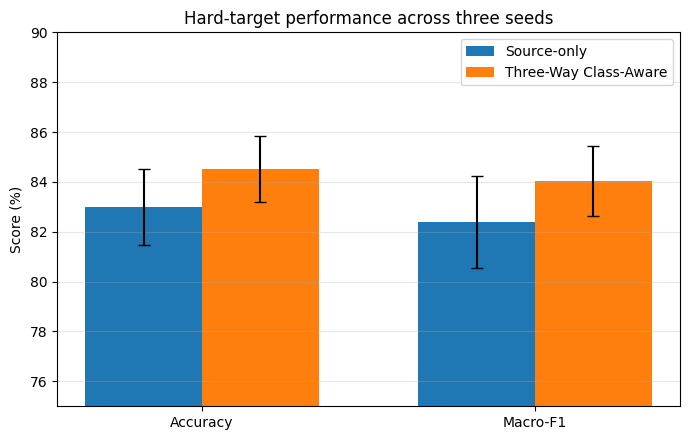

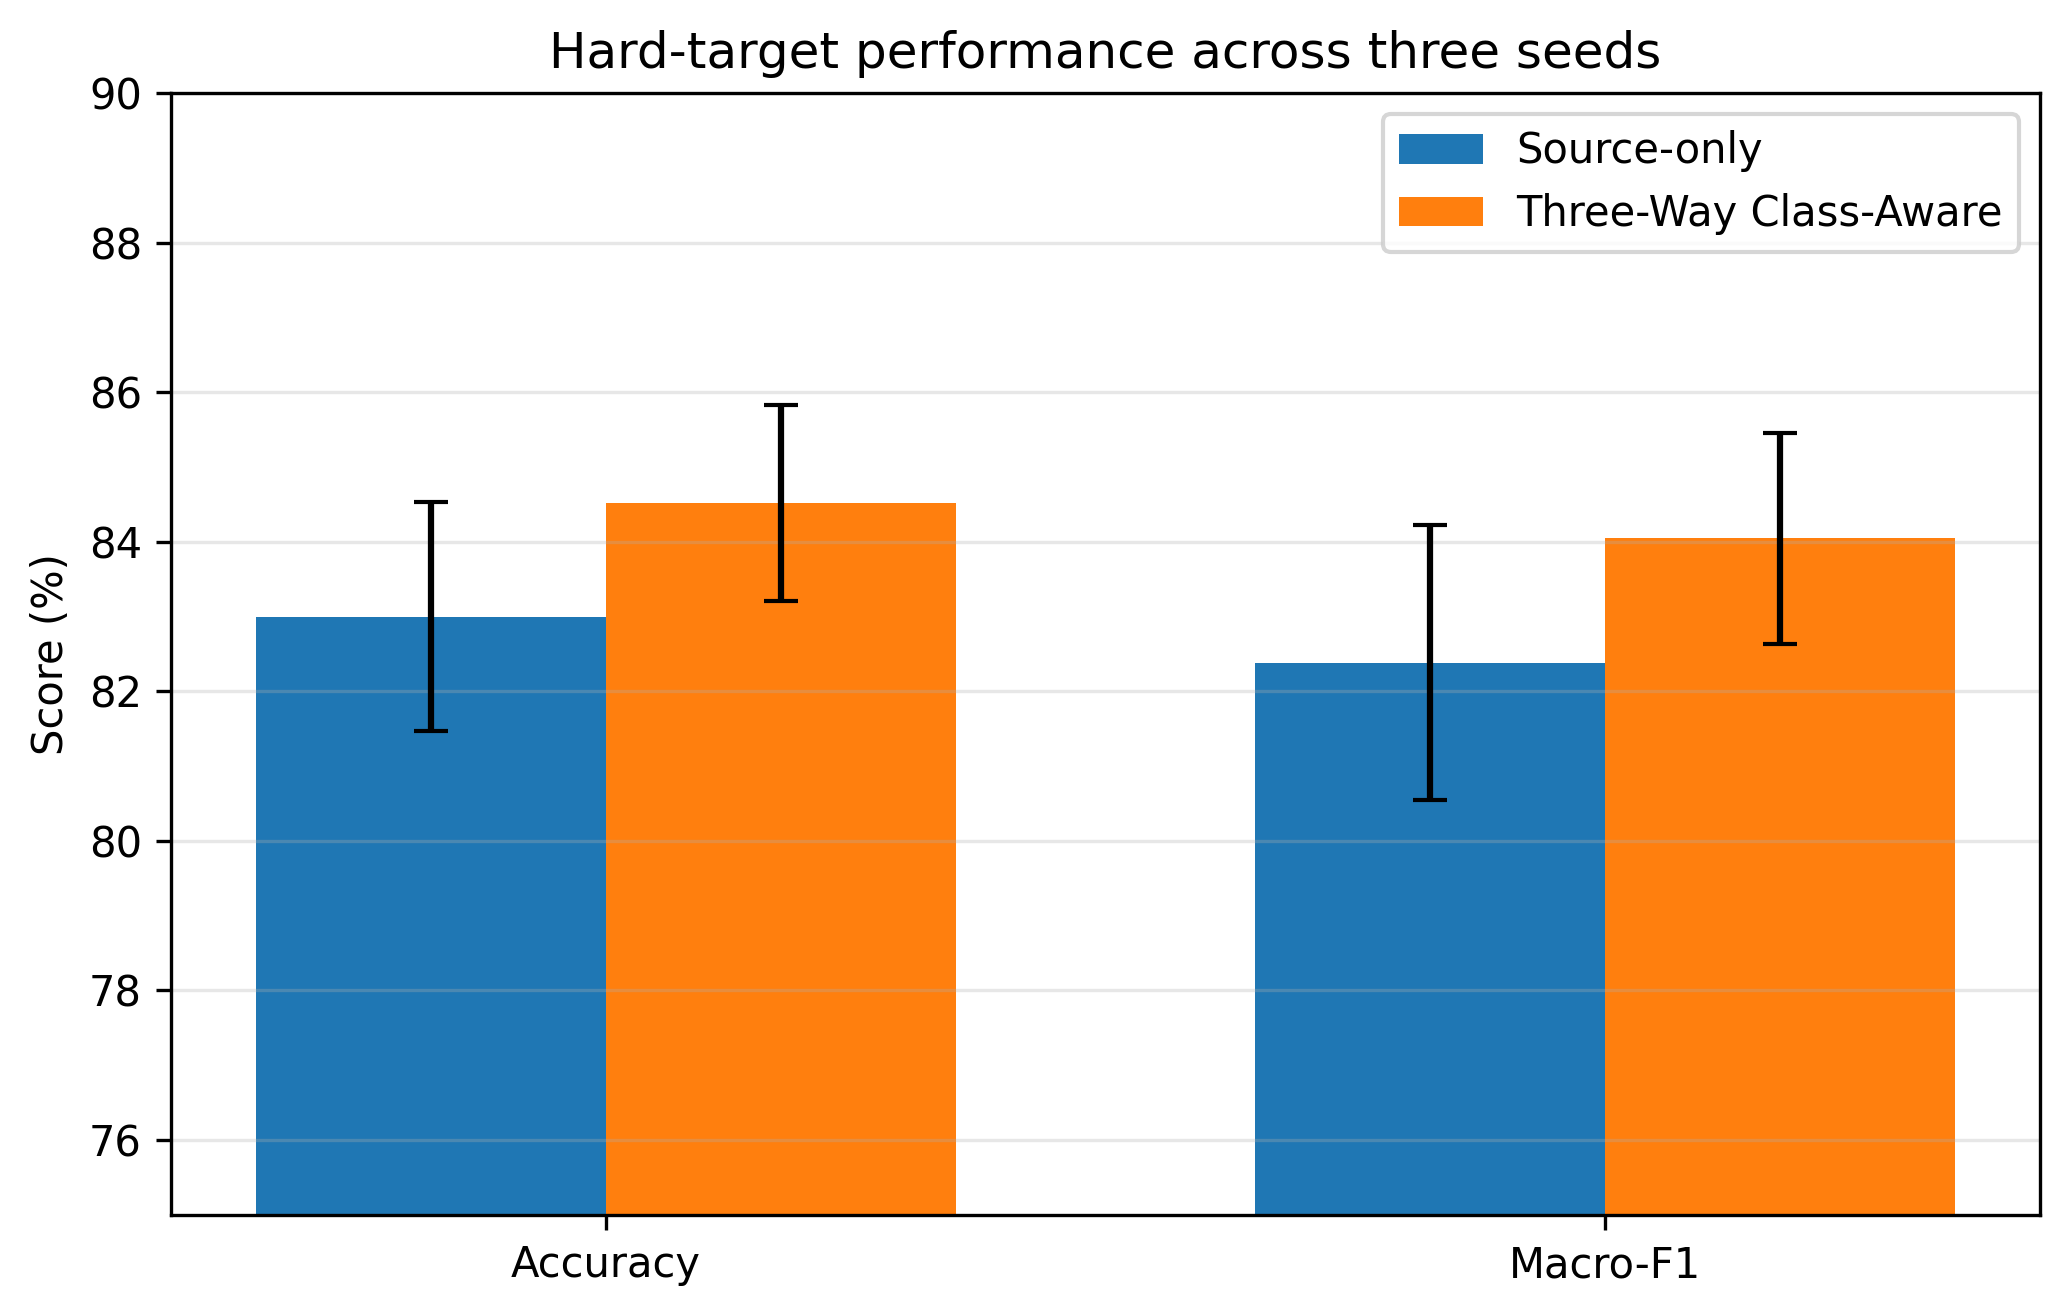

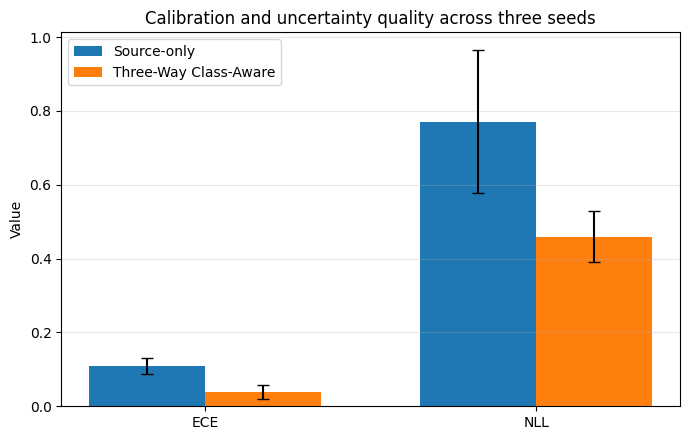

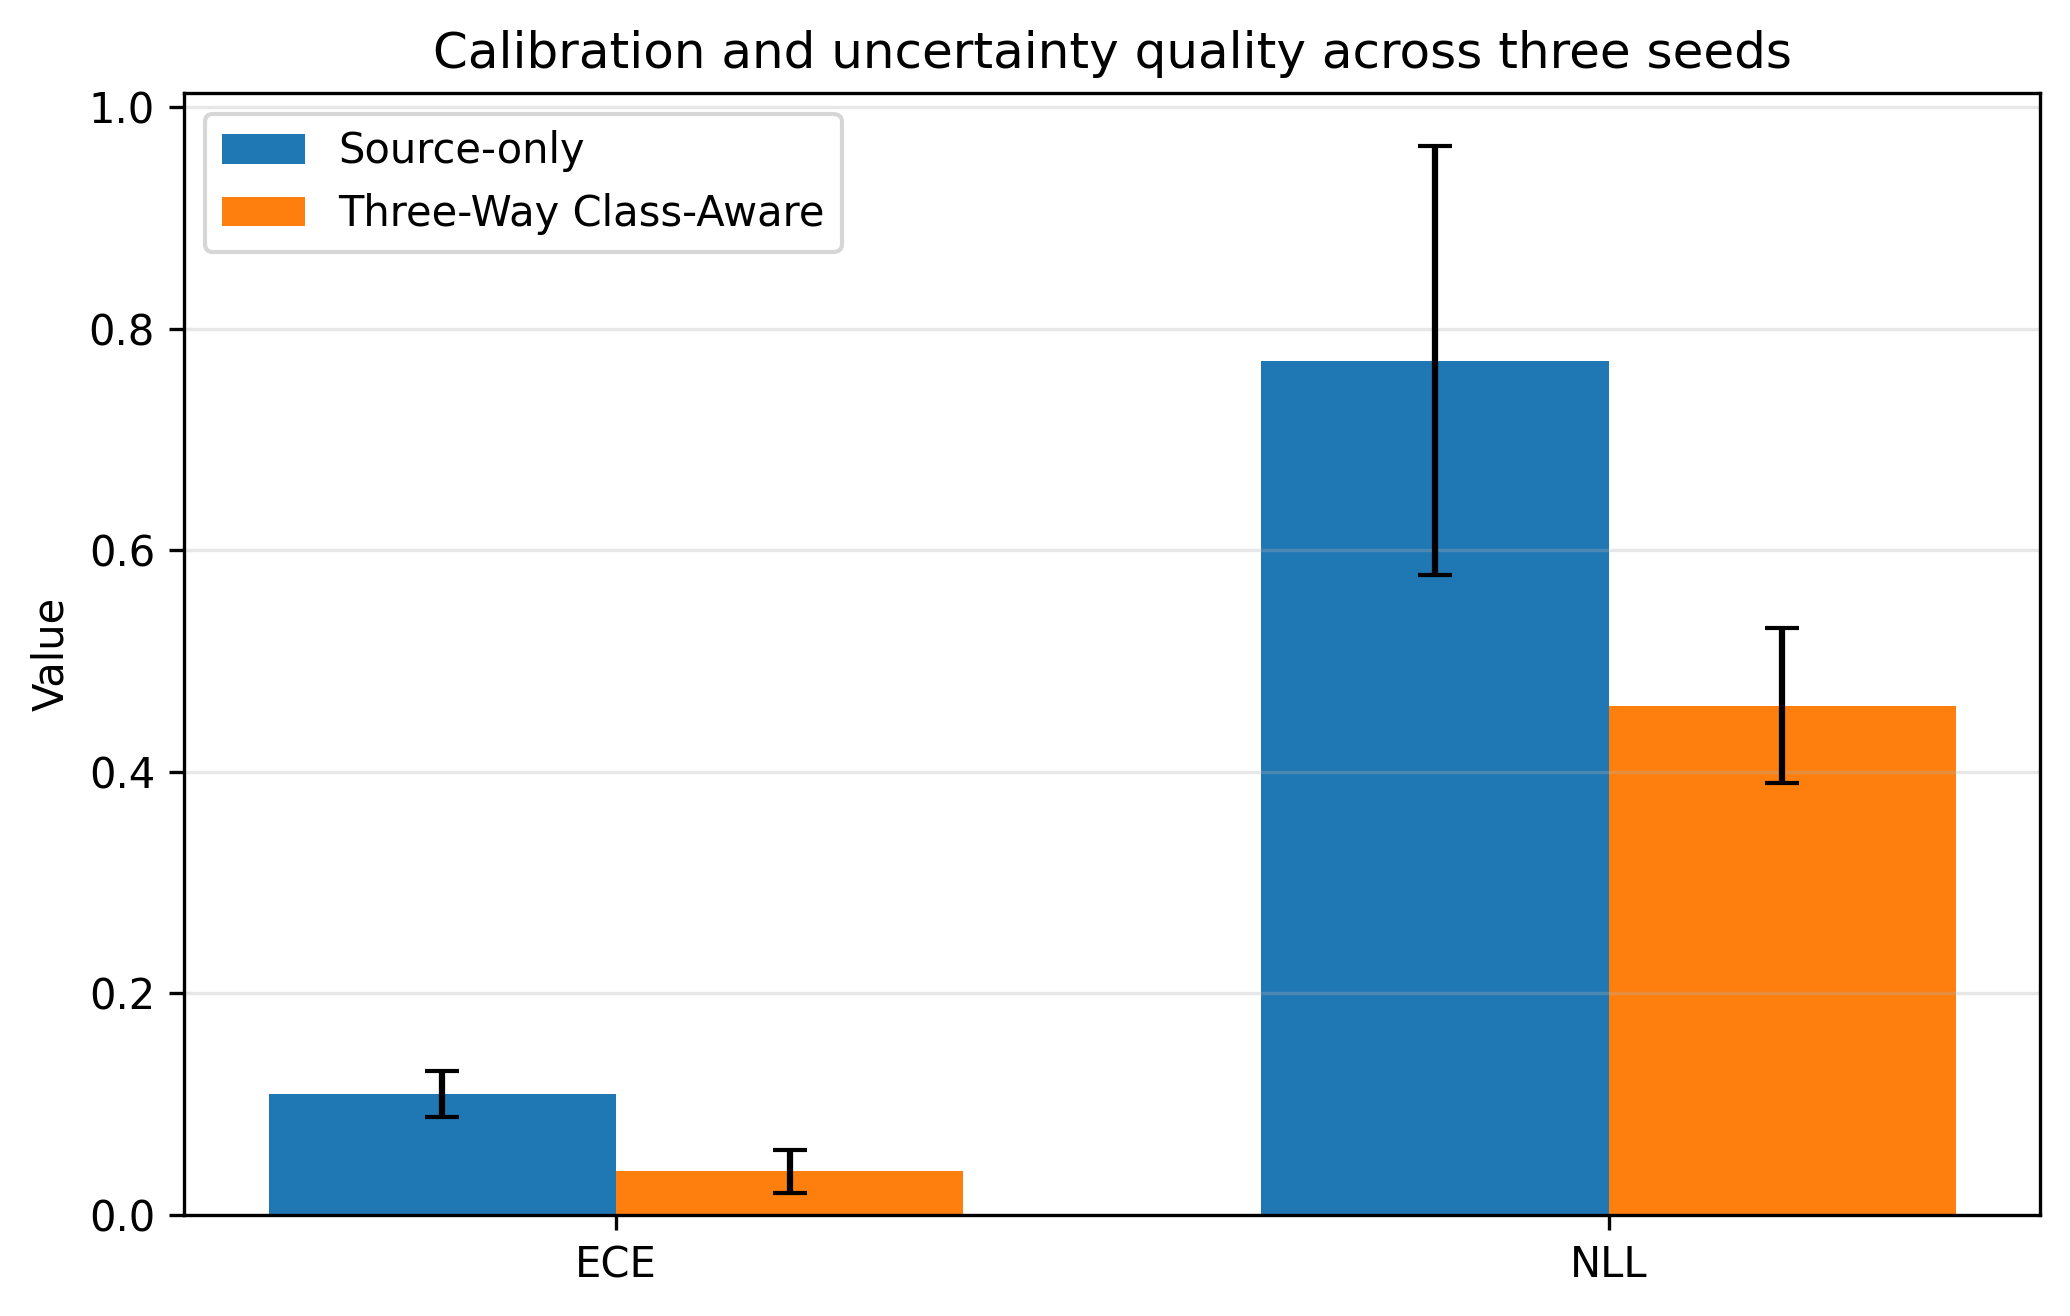

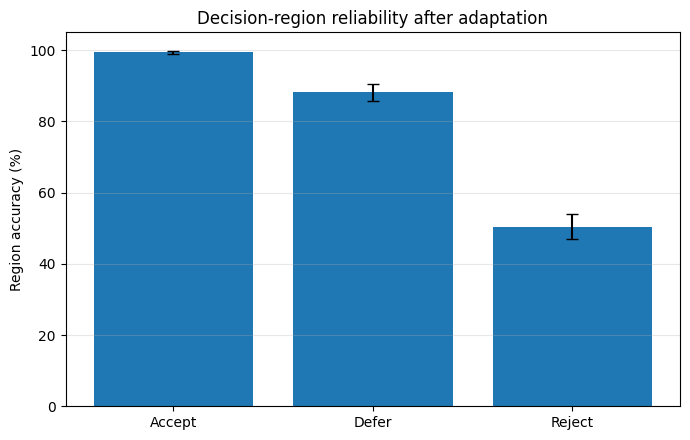

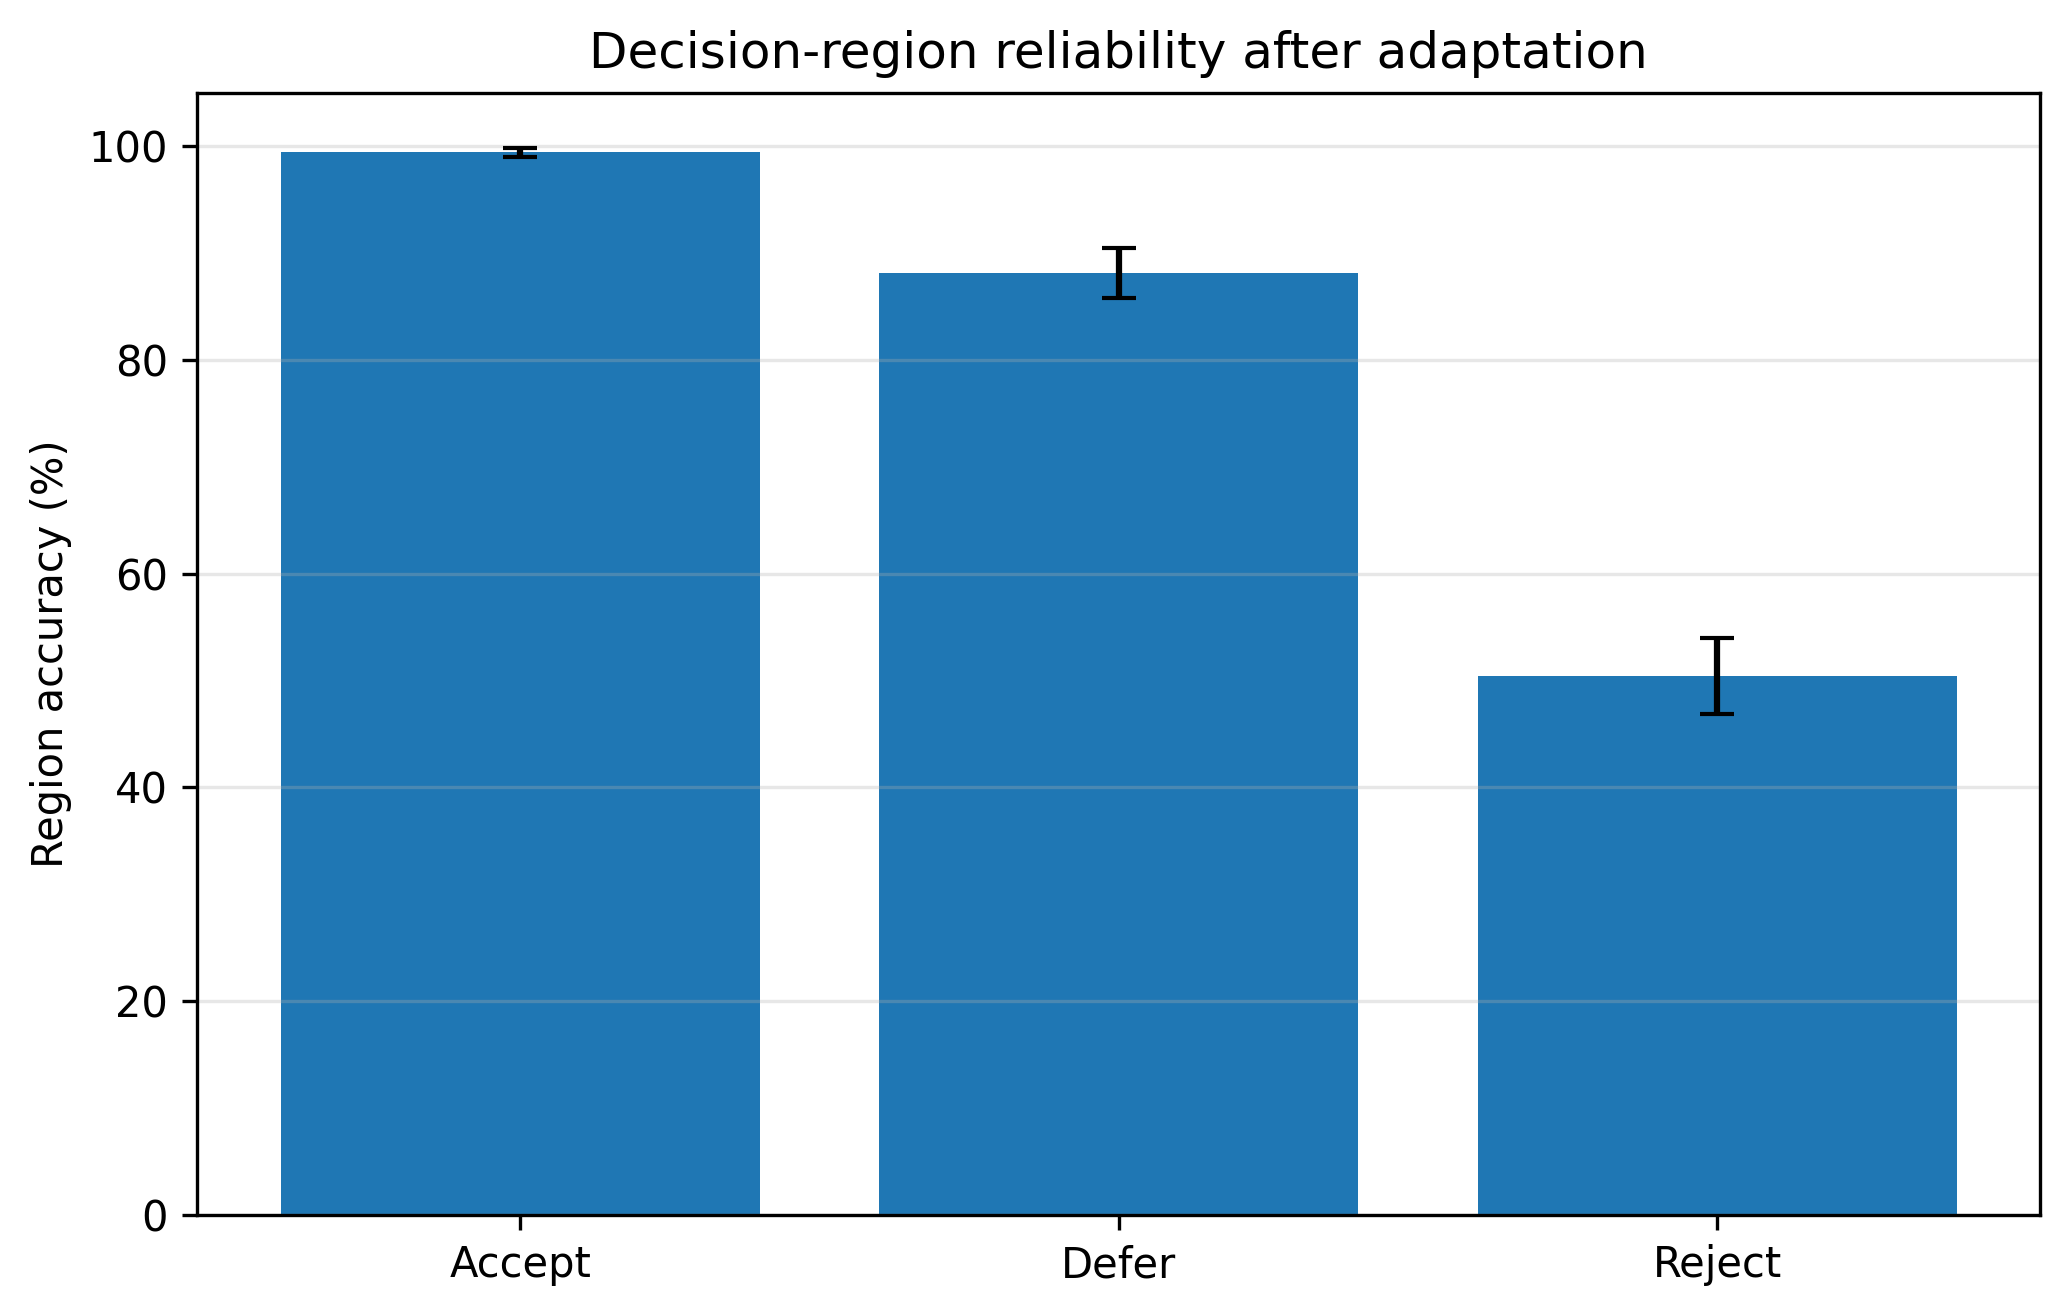

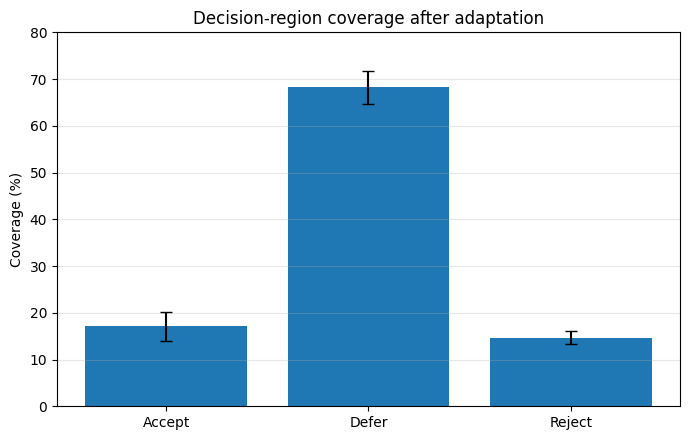

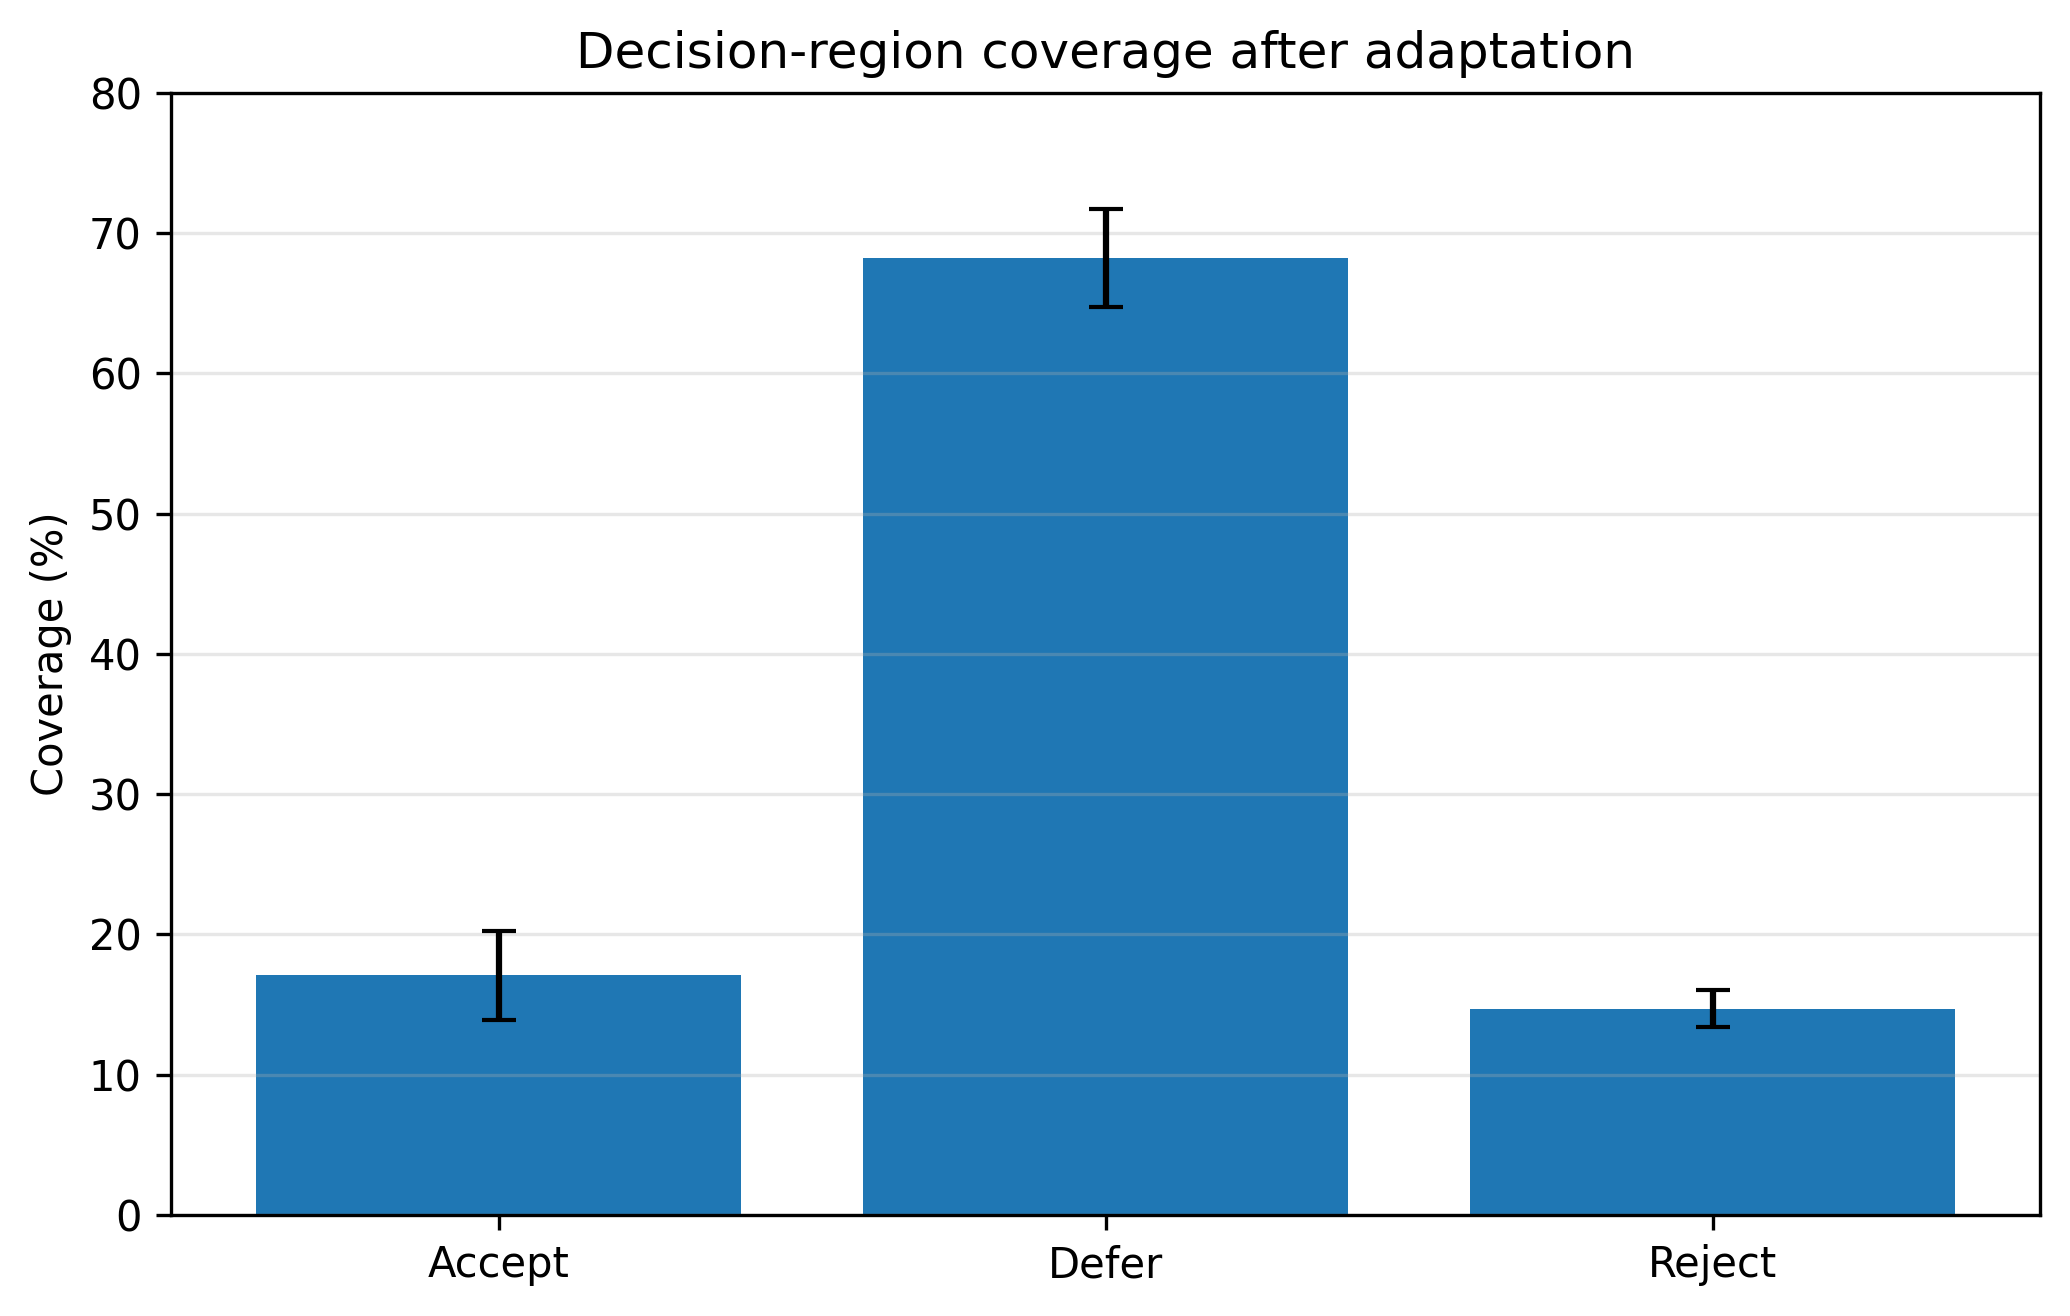

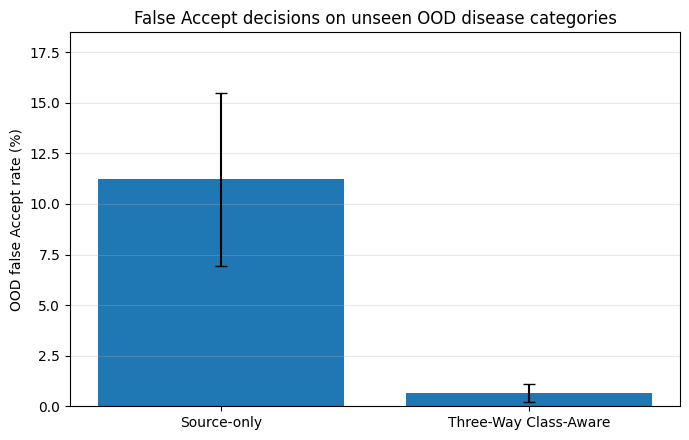

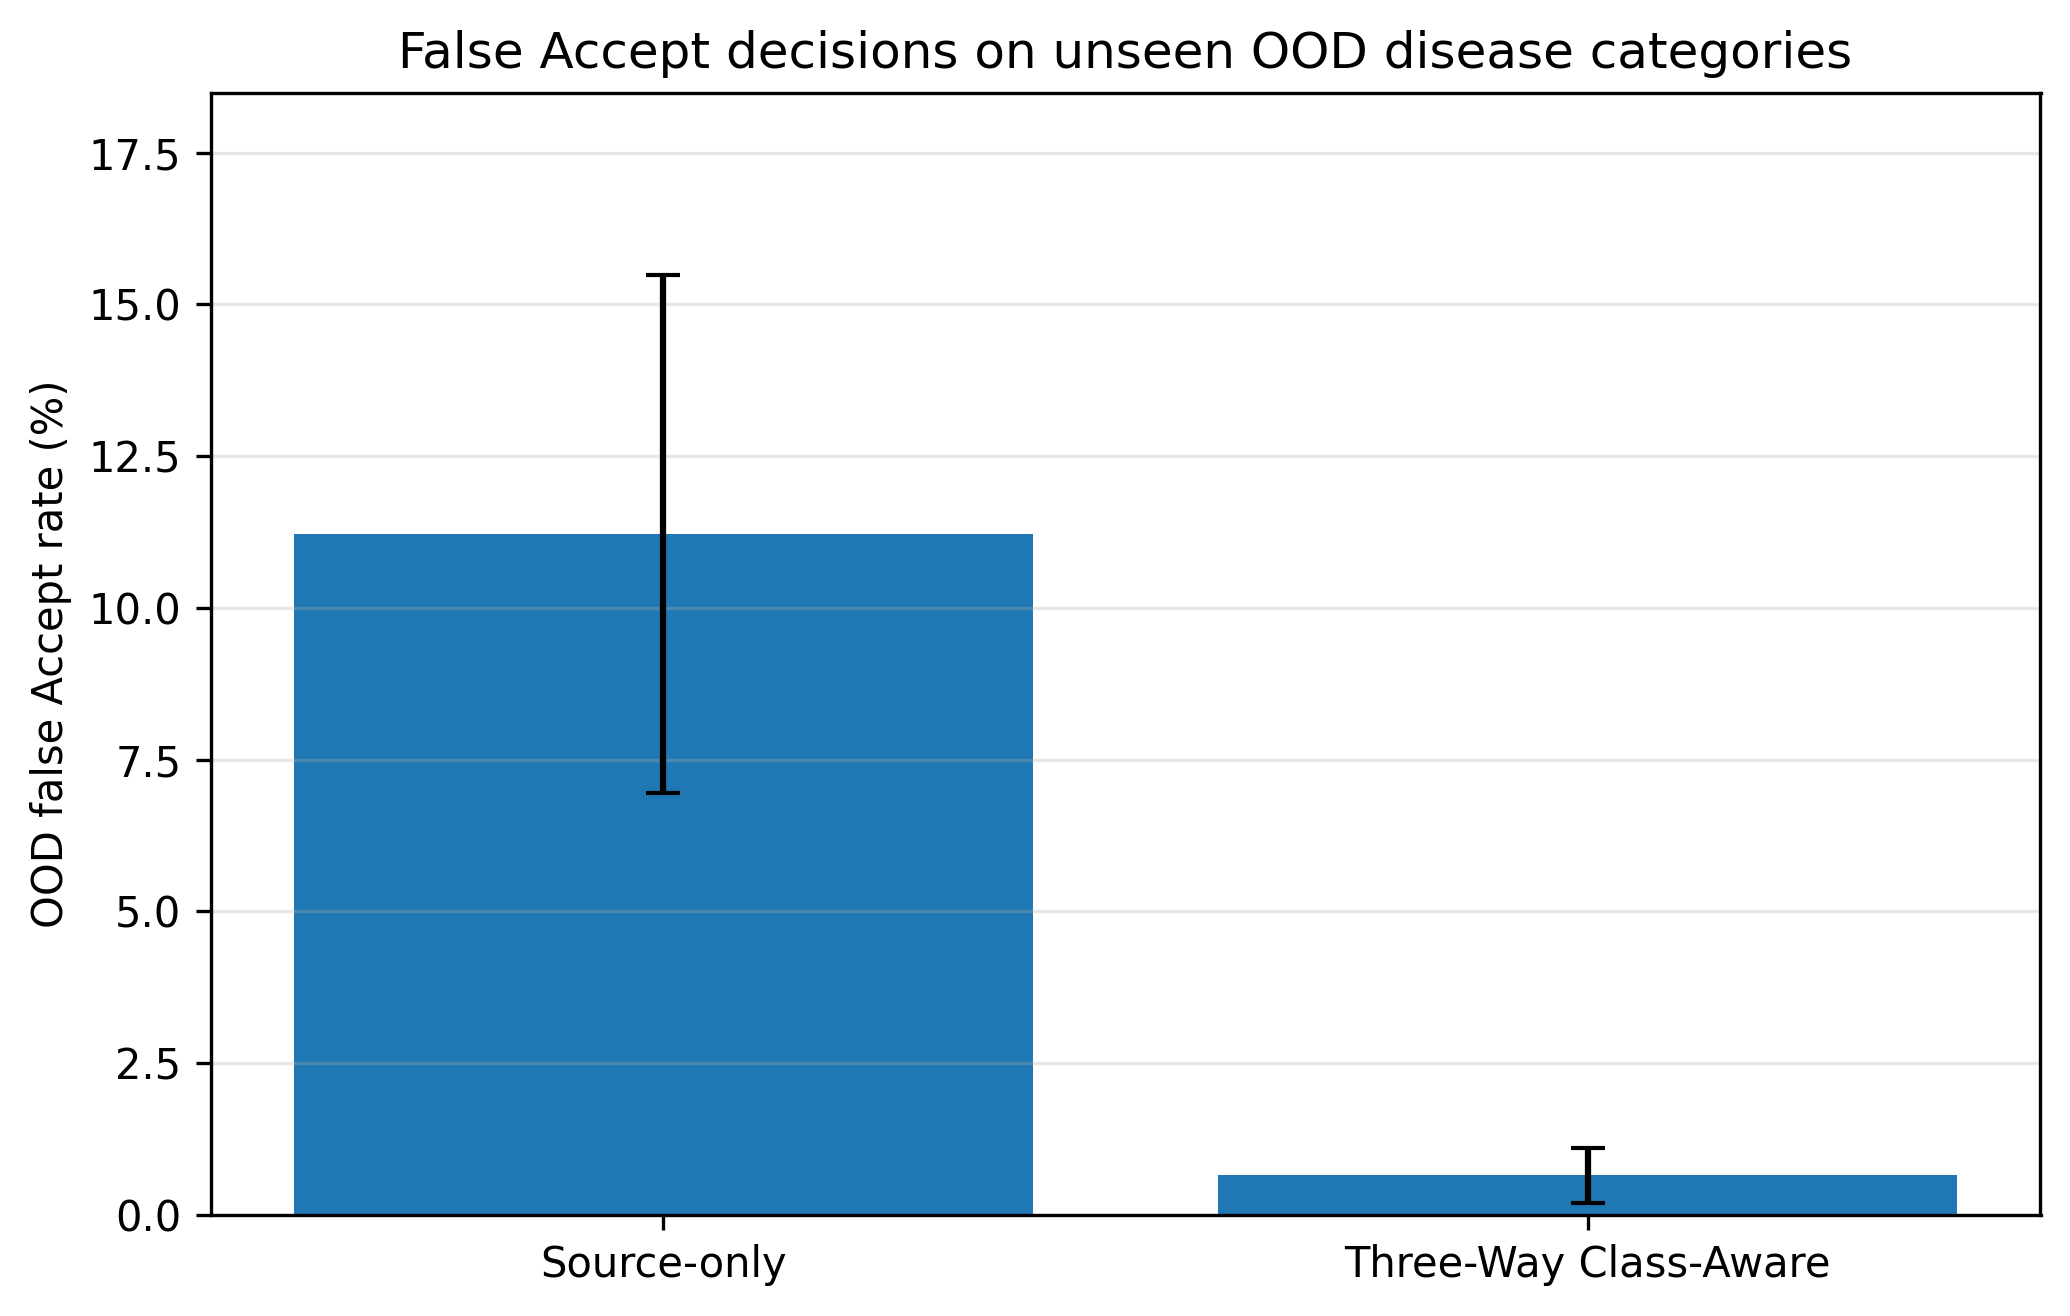


Figures saved:
/kaggle/working/paper_figures/figures_20260905_233948/fig2a_hard_target_accuracy_macro_f1.png
/kaggle/working/paper_figures/figures_20260905_233948/fig2b_calibration_ece_nll.png
/kaggle/working/paper_figures/figures_20260905_233948/fig3a_decision_region_accuracy.png
/kaggle/working/paper_figures/figures_20260905_233948/fig3b_decision_region_coverage.png
/kaggle/working/paper_figures/figures_20260905_233948/fig4_ood_false_accept_comparison.png


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown, Image

WORK_DIR = Path("/kaggle/working")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
FIG_DIR = WORK_DIR / "paper_figures" / f"figures_{timestamp}"
FIG_DIR.mkdir(parents=True, exist_ok=False)

print("Saving figures to:")
print(FIG_DIR)

# ------------------------------------------------------------
# Locate latest result folders
# ------------------------------------------------------------
summary_dir = sorted((WORK_DIR / "results_multiseed_summary").glob("summary_clean_*"))[-1]
post_twd_dir = sorted((WORK_DIR / "results_multiseed_post_twd").glob("post_twd_with_seed42_*"))[-1]
ood_dir = sorted((WORK_DIR / "results_ood_source_vs_proposed").glob("ood_compare_*"))[-1]

print("\nUsing summary folder:", summary_dir)
print("Using post-TWD folder:", post_twd_dir)
print("Using OOD comparison folder:", ood_dir)

# ------------------------------------------------------------
# Load saved results
# ------------------------------------------------------------
all_seed_df = pd.read_csv(summary_dir / "three_seed_hard_target_all_results_clean.csv")
region_df = pd.read_csv(post_twd_dir / "all_3_seed_known_target_region_summary.csv")
ood_accept_df = pd.read_csv(ood_dir / "ood_false_accept_by_seed_method.csv")
ood_delta_df = pd.read_csv(ood_dir / "ood_false_accept_reduction_by_seed.csv")

# Rename method labels for figures
label_map = {
    "ResNet50_SourceOnly": "Source-only",
    "ResNet50_ThreeWayClassAware": "Three-Way Class-Aware",
    "SourceOnly": "Source-only",
    "ThreeWayClassAware": "Three-Way Class-Aware"
}

all_seed_df["method_label"] = all_seed_df["method"].map(label_map)
ood_accept_df["method_label"] = ood_accept_df["method"].map(label_map)

# ------------------------------------------------------------
# Figure 2A: Accuracy and Macro-F1
# ------------------------------------------------------------
perf_summary = (
    all_seed_df
    .groupby("method_label")[["accuracy", "macro_f1"]]
    .agg(["mean", "std"])
)

methods = ["Source-only", "Three-Way Class-Aware"]
metrics = ["accuracy", "macro_f1"]
metric_labels = ["Accuracy", "Macro-F1"]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, method in enumerate(methods):
    means = [perf_summary.loc[method, (m, "mean")] * 100 for m in metrics]
    stds = [perf_summary.loc[method, (m, "std")] * 100 for m in metrics]

    ax.bar(
        x + (i - 0.5) * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=method
    )

ax.set_ylabel("Score (%)")
ax.set_title("Hard-target performance across three seeds")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(75, 90)
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig2a_hard_target_accuracy_macro_f1.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

display(Image(filename=str(fig_path)))

# ------------------------------------------------------------
# Figure 2B: Calibration metrics
# ------------------------------------------------------------
cal_summary = (
    all_seed_df
    .groupby("method_label")[["ece", "nll"]]
    .agg(["mean", "std"])
)

metrics = ["ece", "nll"]
metric_labels = ["ECE", "NLL"]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, method in enumerate(methods):
    means = [cal_summary.loc[method, (m, "mean")] for m in metrics]
    stds = [cal_summary.loc[method, (m, "std")] for m in metrics]

    ax.bar(
        x + (i - 0.5) * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=method
    )

ax.set_ylabel("Value")
ax.set_title("Calibration and uncertainty quality across three seeds")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig2b_calibration_ece_nll.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

display(Image(filename=str(fig_path)))

# ------------------------------------------------------------
# Figure 3A: Region accuracy
# ------------------------------------------------------------
region_order = ["Accept", "Defer", "Reject"]

region_summary = (
    region_df
    .groupby("region")[["region_accuracy", "coverage"]]
    .agg(["mean", "std"])
    .reindex(region_order)
)

x = np.arange(len(region_order))

fig, ax = plt.subplots(figsize=(7, 4.5))

means = region_summary[("region_accuracy", "mean")].values * 100
stds = region_summary[("region_accuracy", "std")].values * 100

ax.bar(x, means, yerr=stds, capsize=4)
ax.set_ylabel("Region accuracy (%)")
ax.set_title("Decision-region reliability after adaptation")
ax.set_xticks(x)
ax.set_xticklabels(region_order)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig3a_decision_region_accuracy.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

display(Image(filename=str(fig_path)))

# ------------------------------------------------------------
# Figure 3B: Region coverage
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

means = region_summary[("coverage", "mean")].values * 100
stds = region_summary[("coverage", "std")].values * 100

ax.bar(x, means, yerr=stds, capsize=4)
ax.set_ylabel("Coverage (%)")
ax.set_title("Decision-region coverage after adaptation")
ax.set_xticks(x)
ax.set_xticklabels(region_order)
ax.set_ylim(0, 80)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig3b_decision_region_coverage.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

display(Image(filename=str(fig_path)))

# ------------------------------------------------------------
# Figure 4: OOD false Accept comparison
# ------------------------------------------------------------
ood_summary = (
    ood_accept_df
    .groupby("method_label")[["ood_false_accept_rate"]]
    .agg(["mean", "std"])
    .reindex(methods)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

means = ood_summary[("ood_false_accept_rate", "mean")].values * 100
stds = ood_summary[("ood_false_accept_rate", "std")].values * 100

ax.bar(methods, means, yerr=stds, capsize=4)
ax.set_ylabel("OOD false Accept rate (%)")
ax.set_title("False Accept decisions on unseen OOD disease categories")
ax.set_ylim(0, max(means + stds) + 3)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = FIG_DIR / "fig4_ood_false_accept_comparison.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

display(Image(filename=str(fig_path)))

# ------------------------------------------------------------
# Save figure source data
# ------------------------------------------------------------
perf_summary.to_csv(FIG_DIR / "fig2a_source_data.csv")
cal_summary.to_csv(FIG_DIR / "fig2b_source_data.csv")
region_summary.to_csv(FIG_DIR / "fig3_source_data.csv")
ood_summary.to_csv(FIG_DIR / "fig4_source_data.csv")

print("\nFigures saved:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(p)

Final fixed package folder:
/kaggle/working/TWD_paper_final_package_FIXED_20260905_234741

Using:
Summary: /kaggle/working/results_multiseed_summary/summary_clean_20260905_231439
Post-TWD: /kaggle/working/results_multiseed_post_twd/post_twd_with_seed42_20260905_232652
OOD: /kaggle/working/results_ood_source_vs_proposed/ood_compare_20260905_232840
Excel saved: /kaggle/working/TWD_paper_final_package_FIXED_20260905_234741/tables/TWD_paper_results_tables_FIXED.xlsx


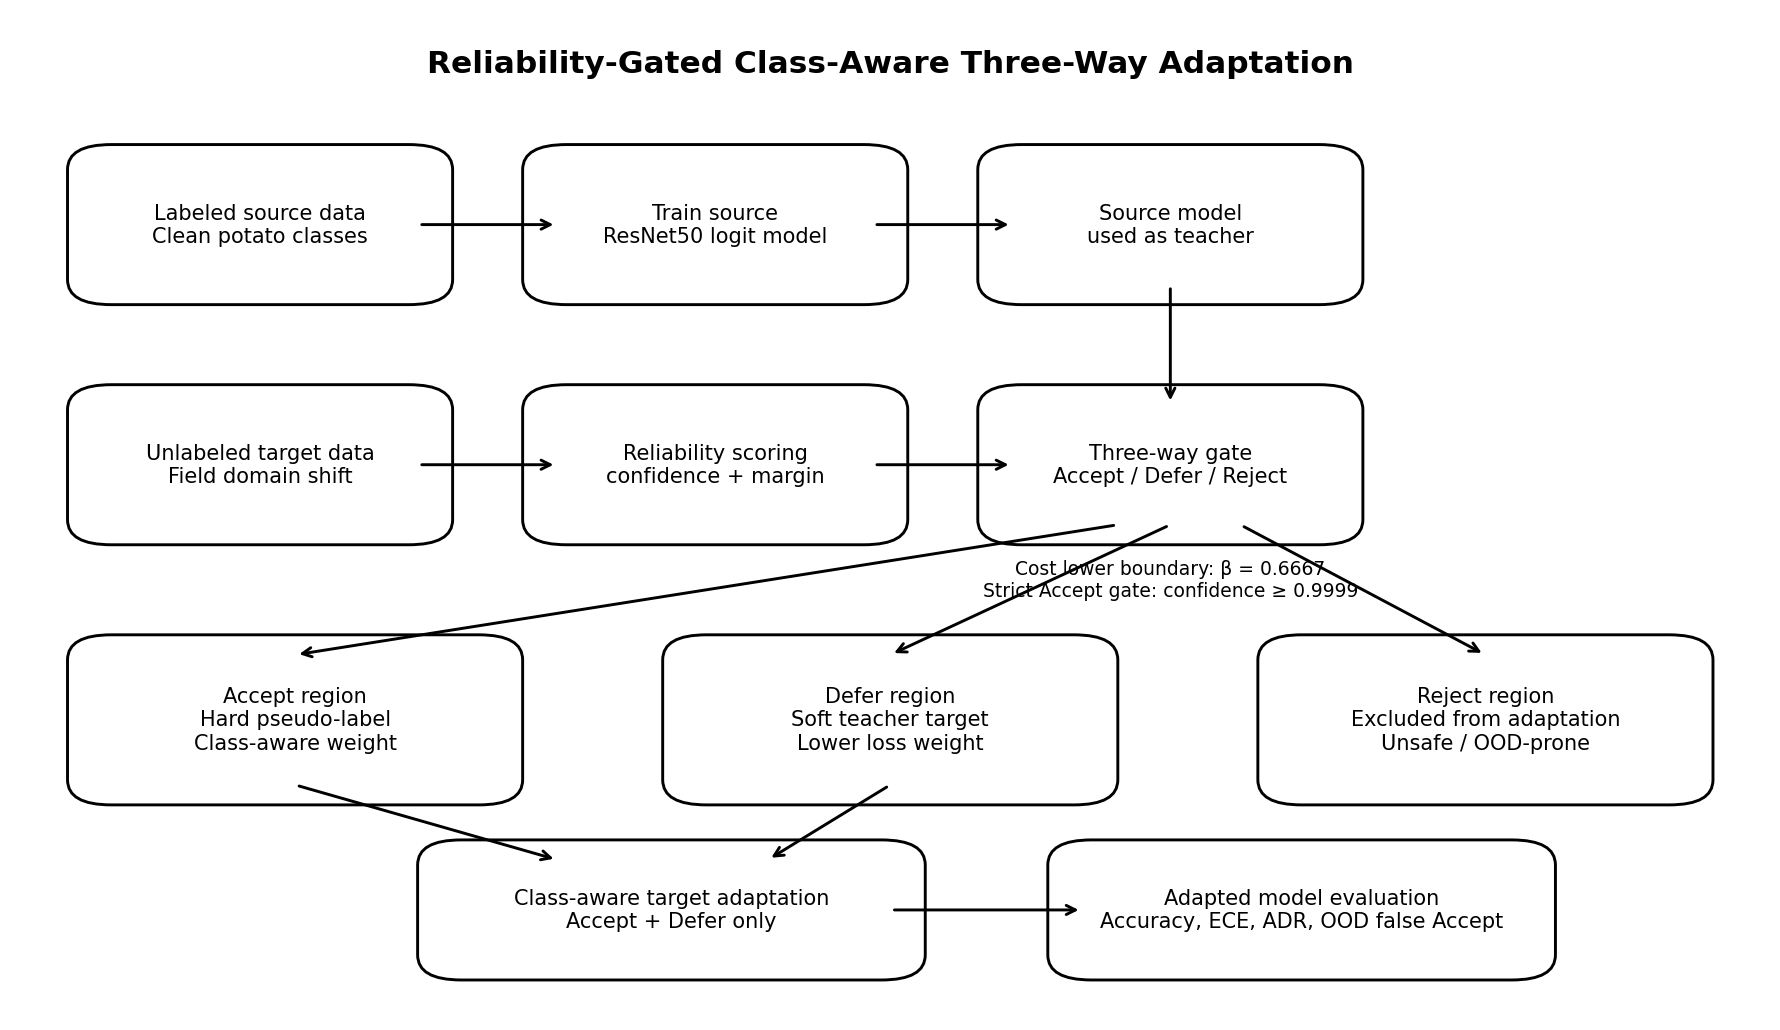

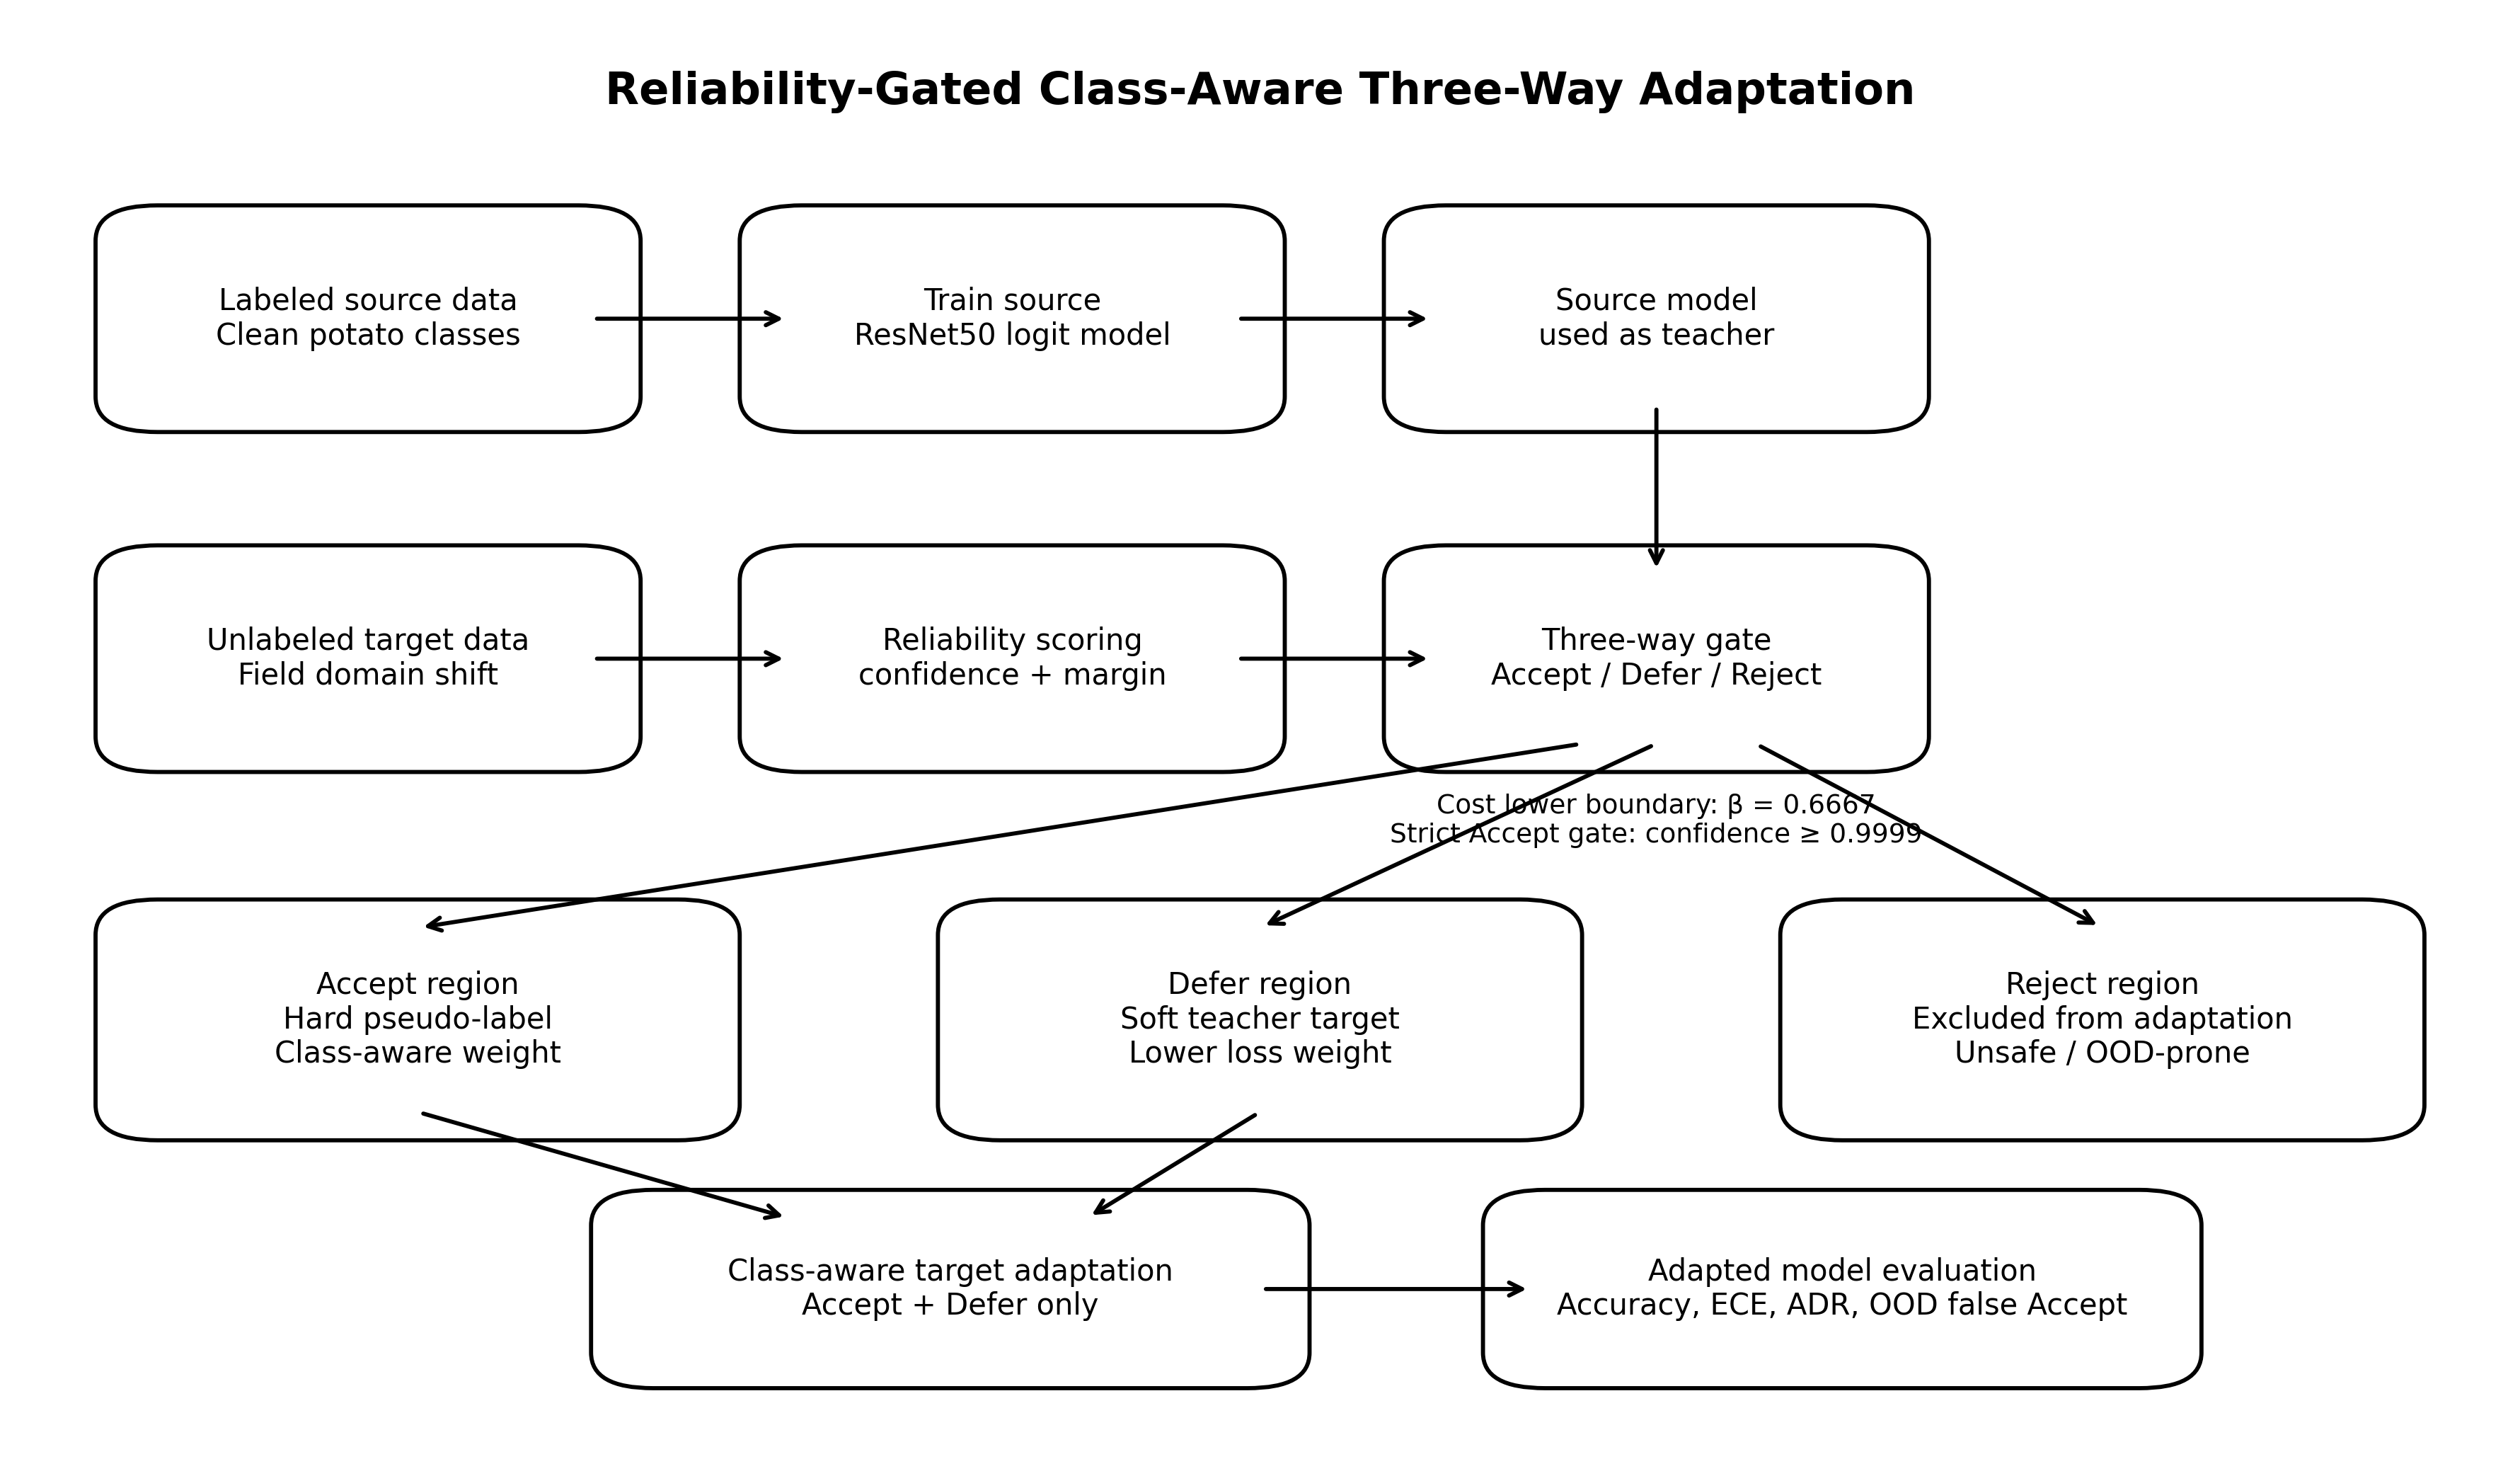

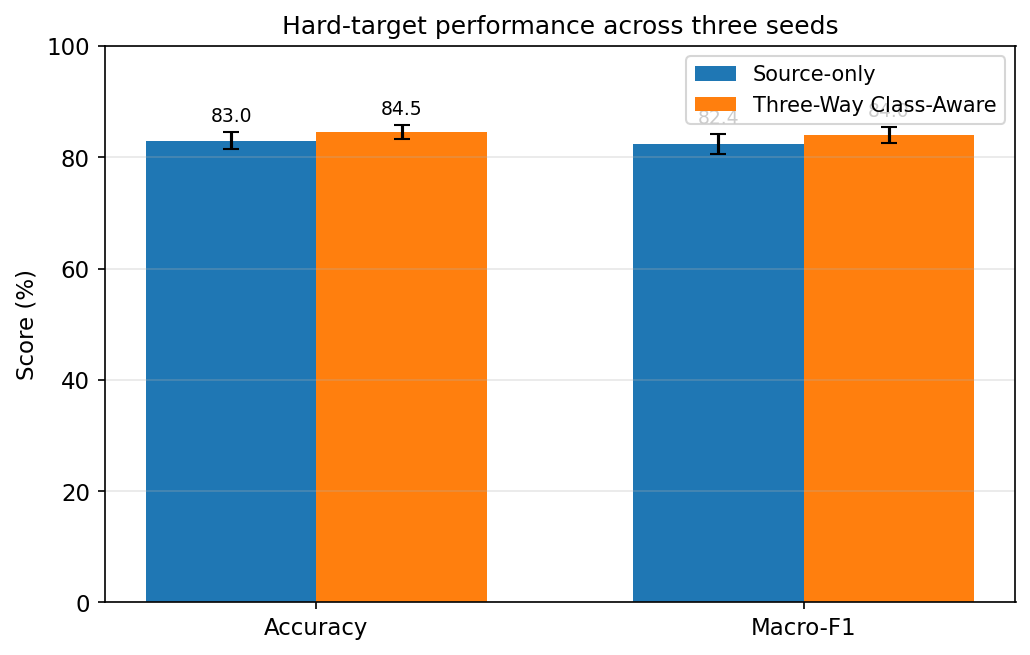

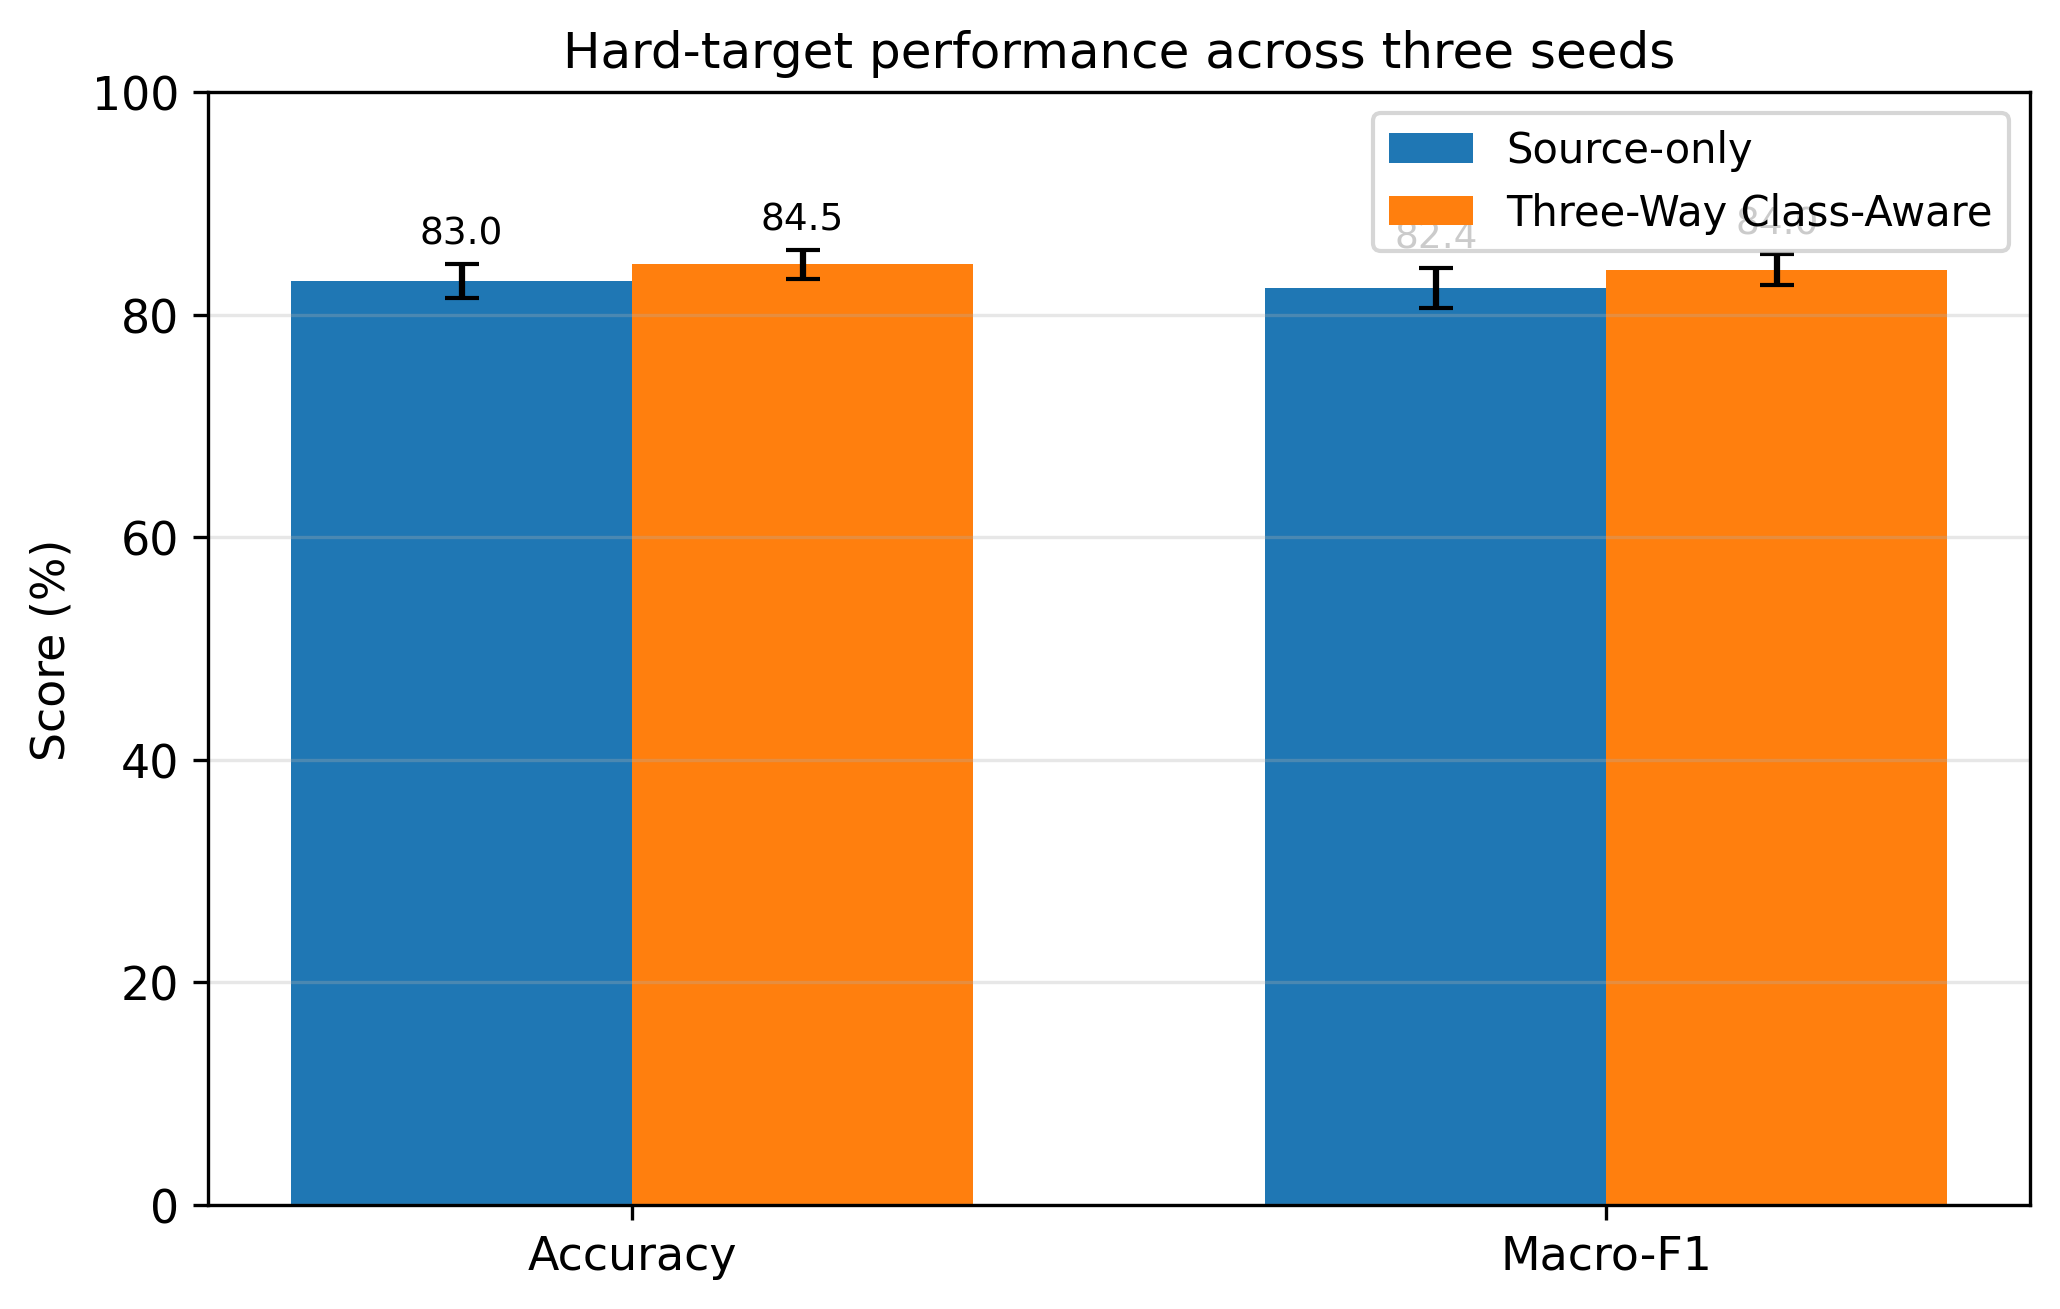

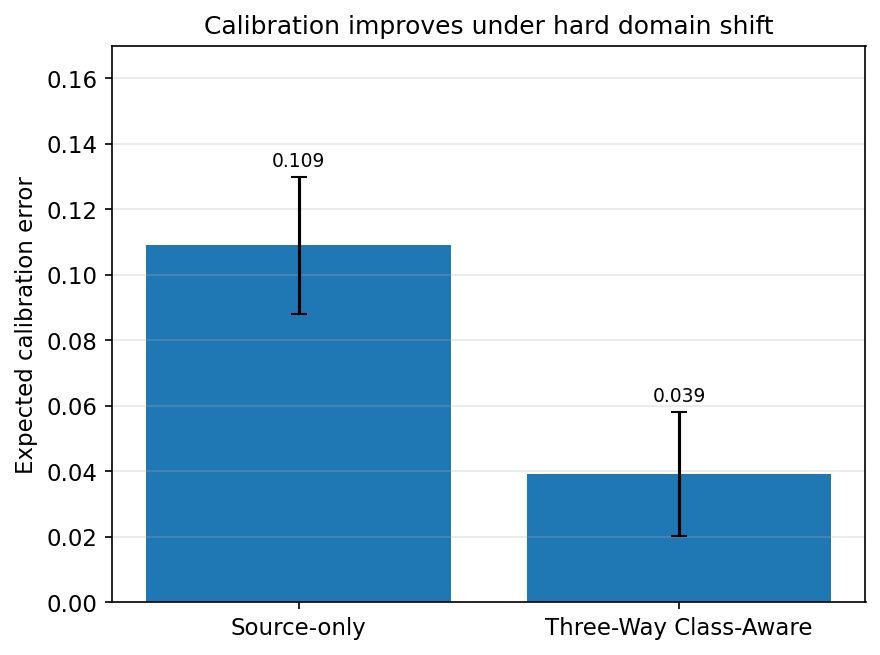

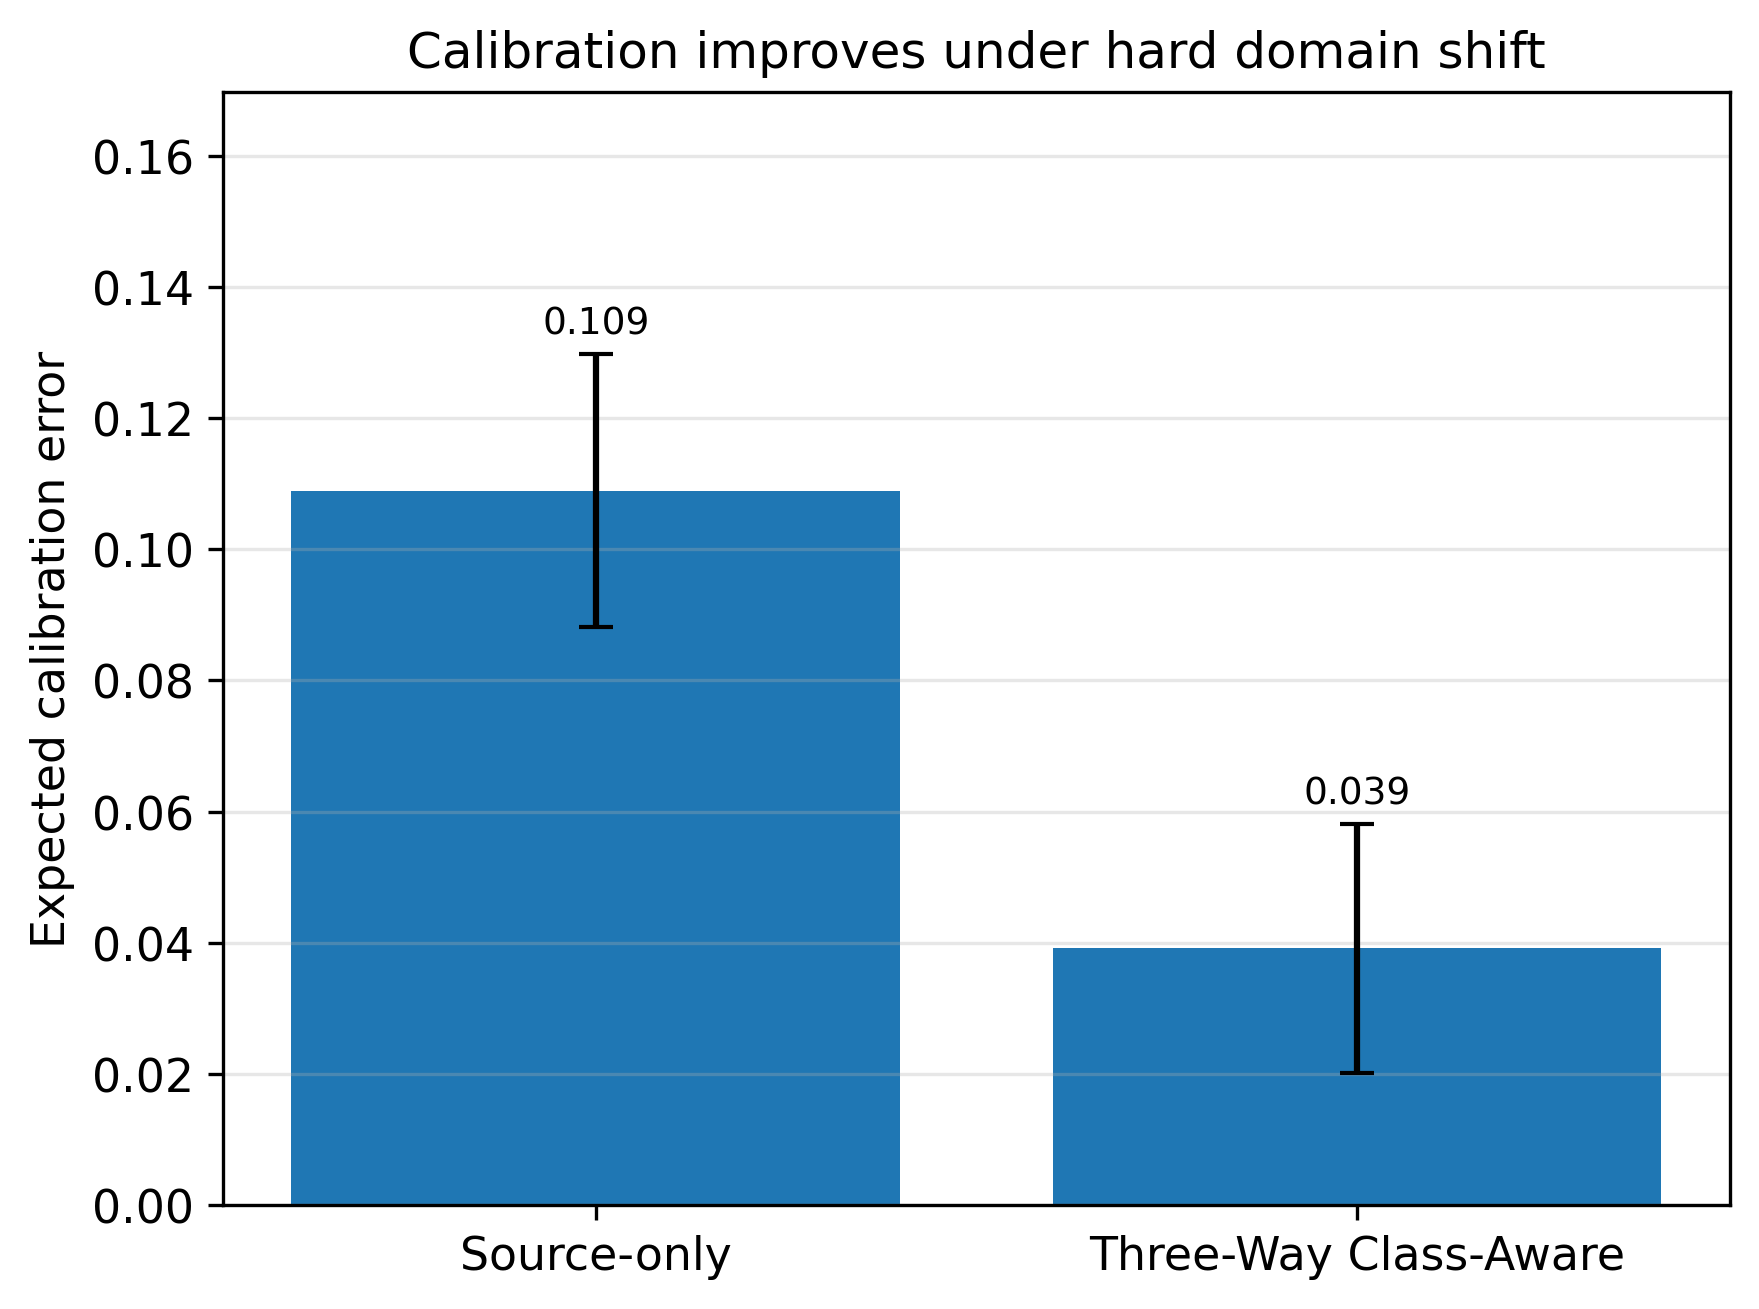

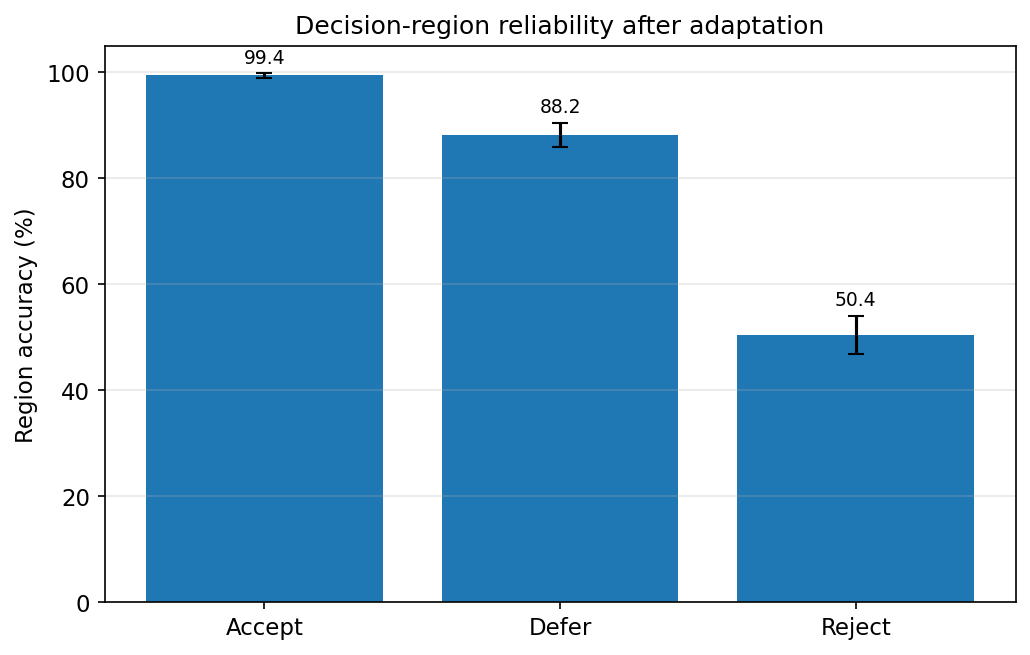

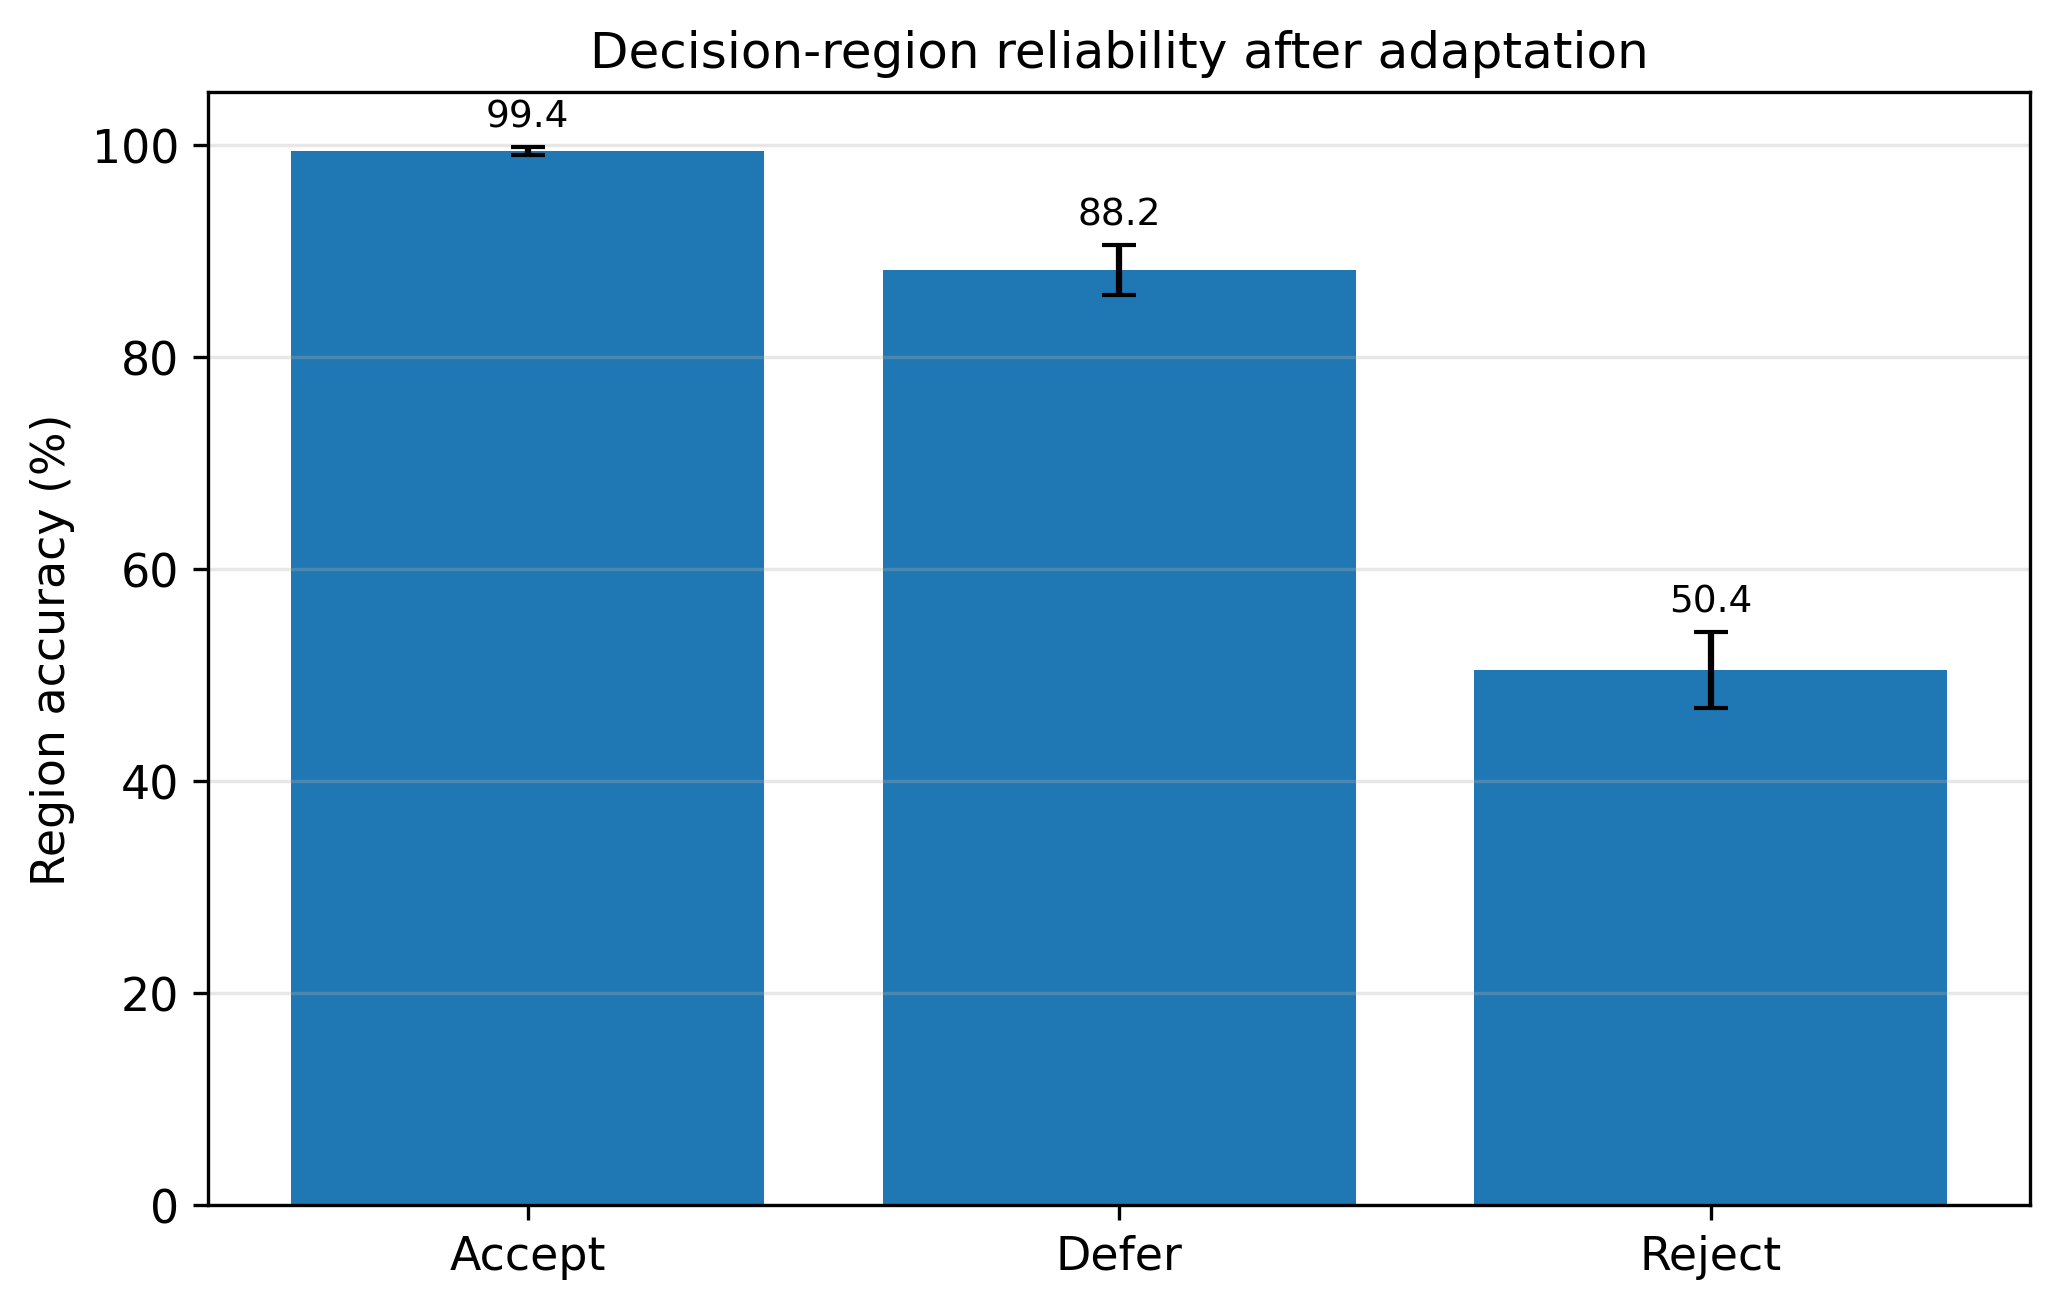

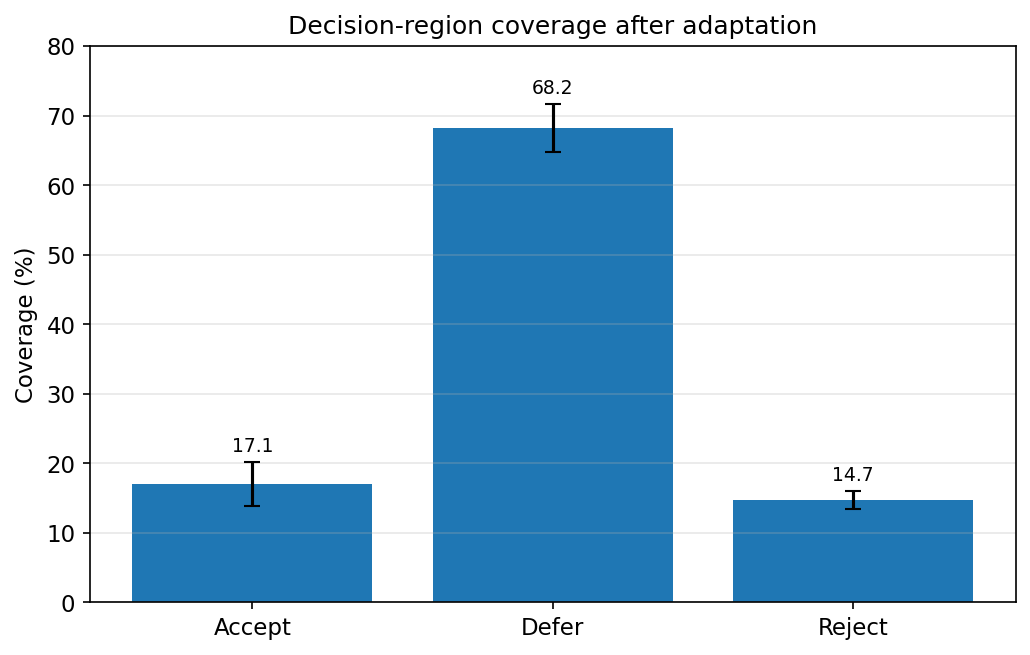

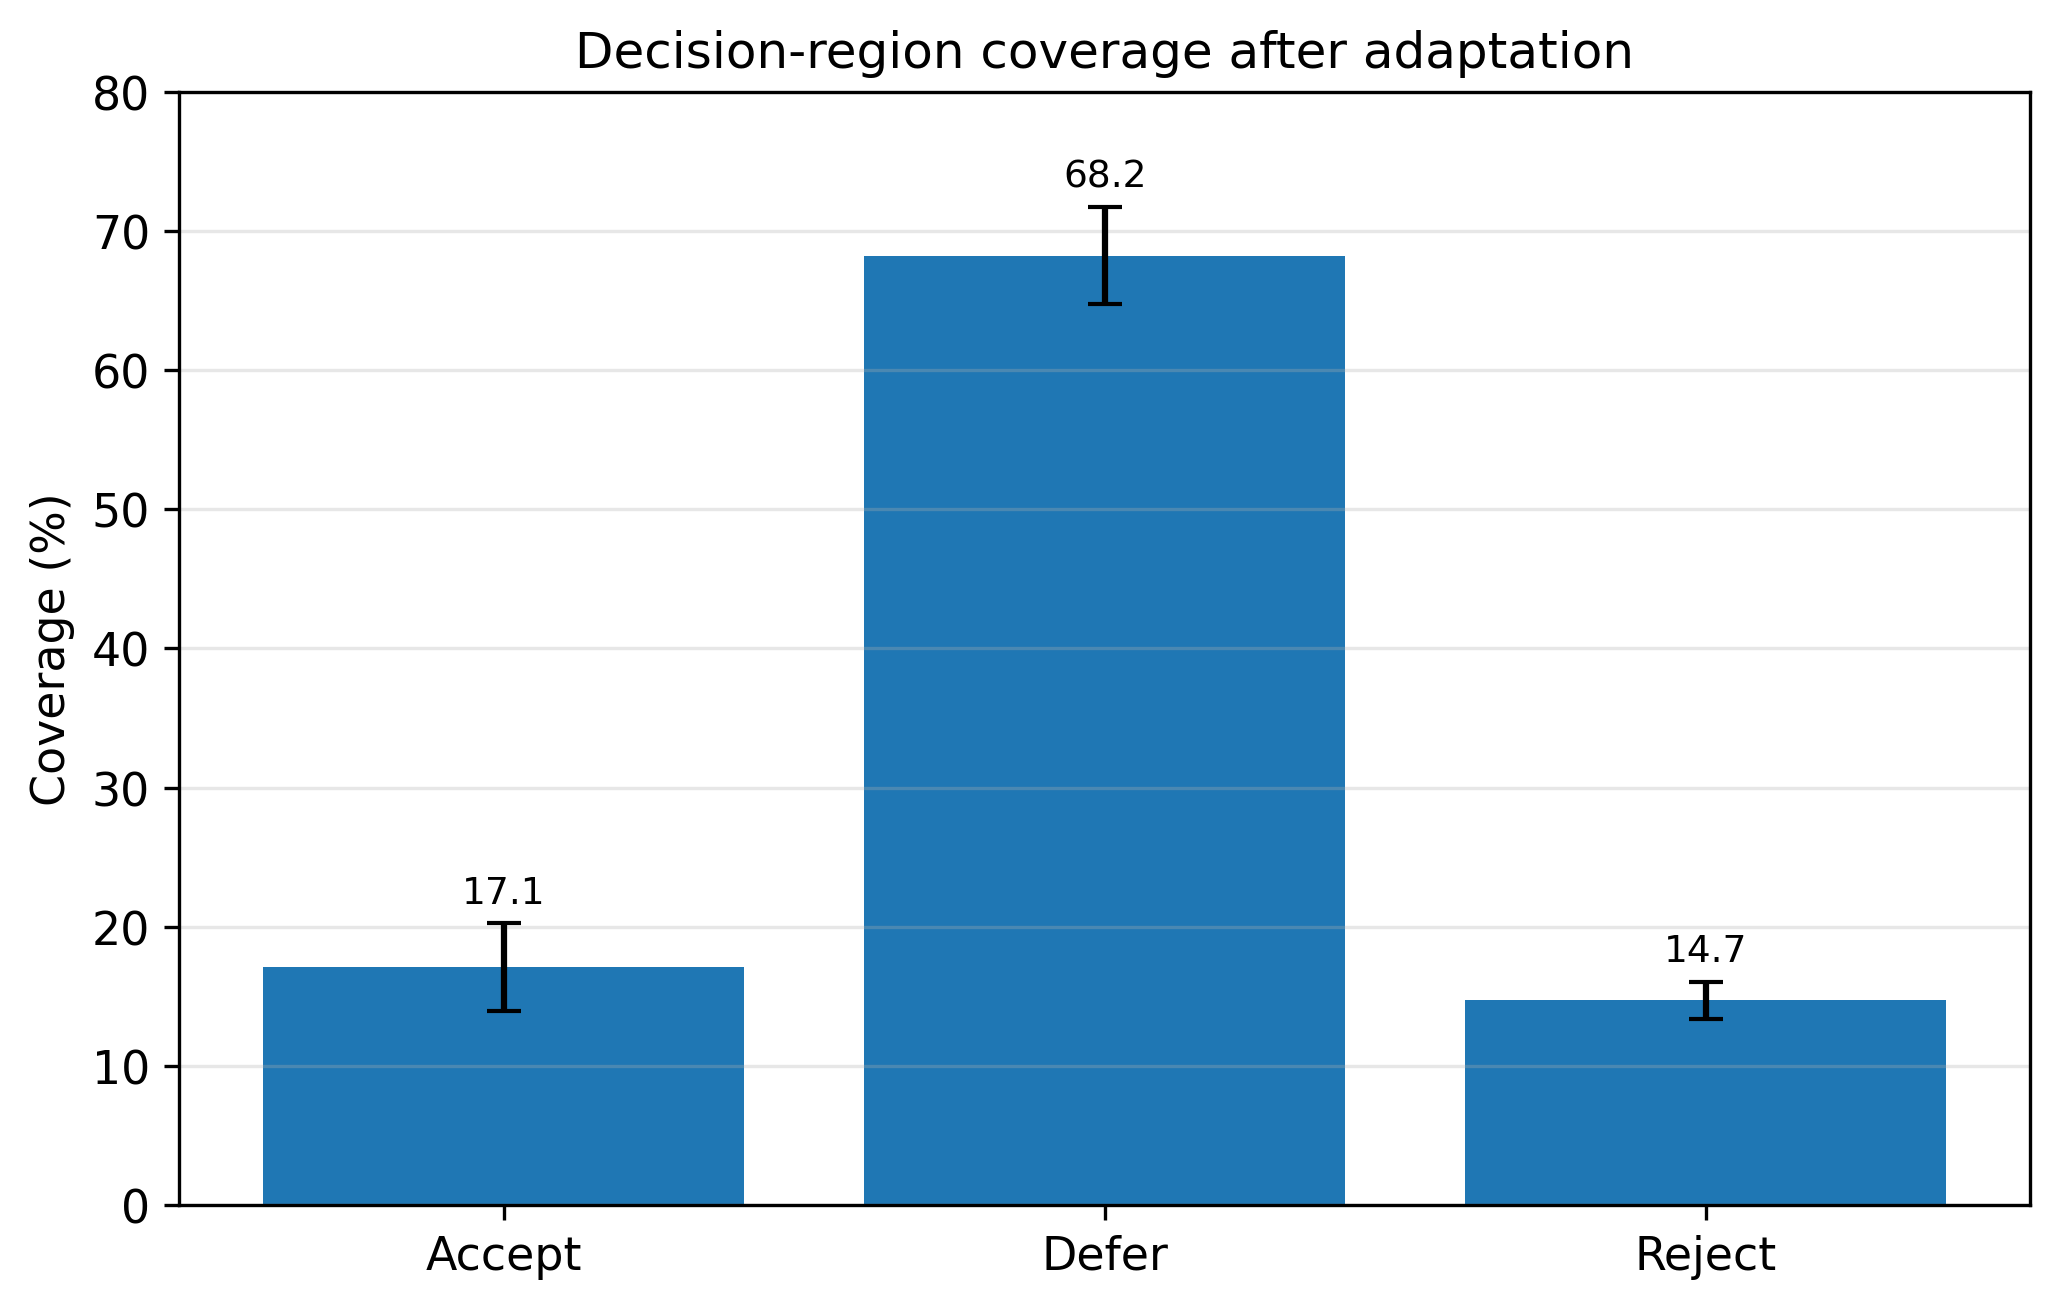

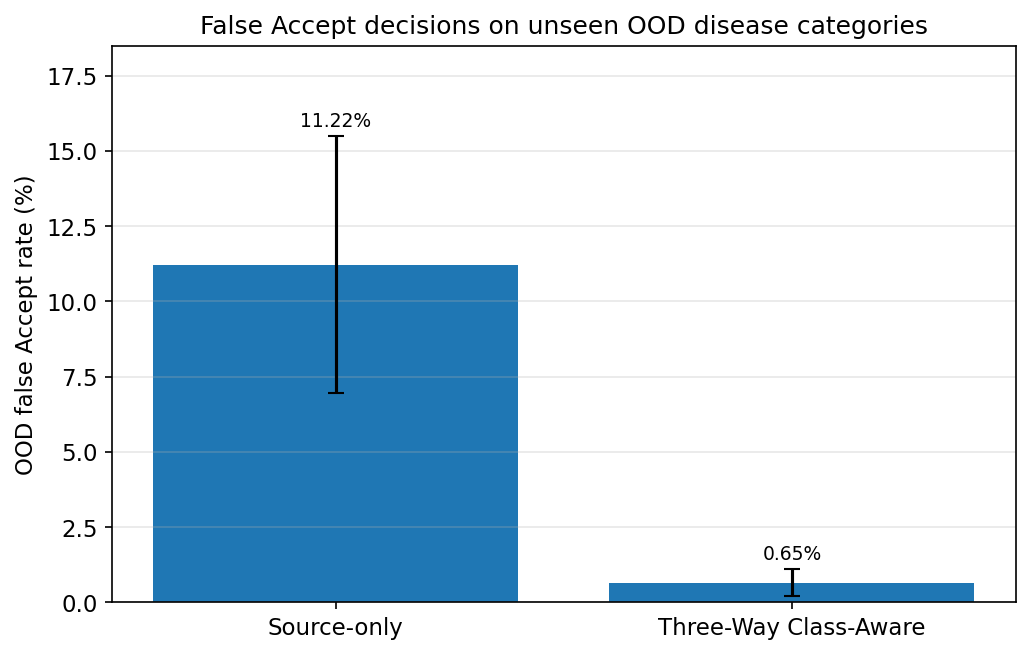

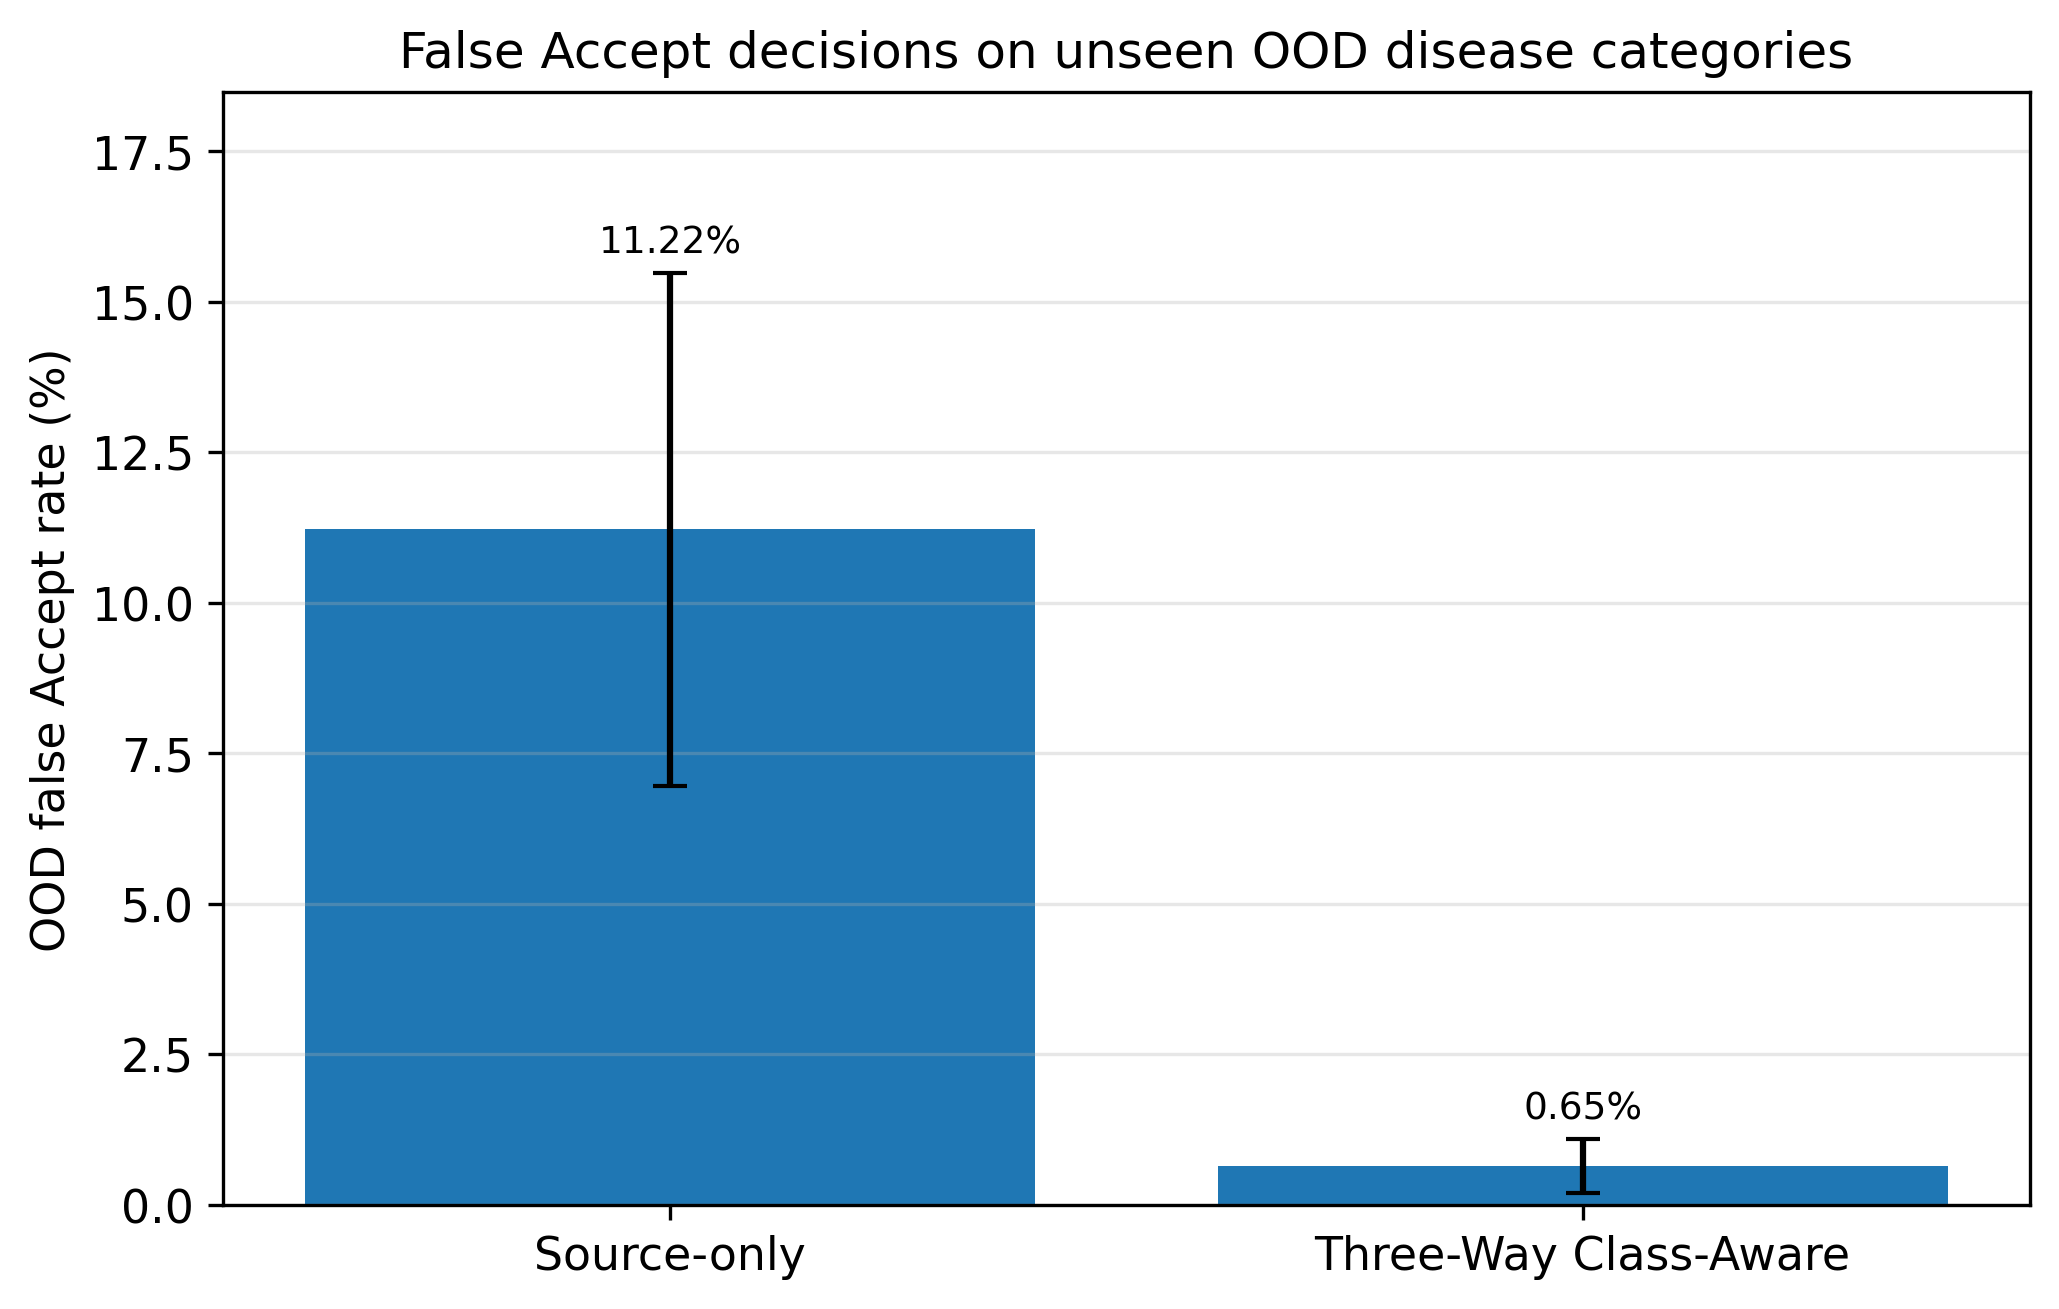


Final TWD Paper Package - Fixed
Generated: 20260905_234741

Main three-seed hard-target result:
- Source-only accuracy: 0.8300 ± 0.0153
- Proposed accuracy: 0.8452 ± 0.0131
- Source-only Macro-F1: 0.8238 ± 0.0183
- Proposed Macro-F1: 0.8404 ± 0.0141
- Source-only ECE: 0.1090 ± 0.0208
- Proposed ECE: 0.0391 ± 0.0190

OOD false Accept:
- Source-only OOD false Accept: 0.1122 ± 0.0426
- Proposed OOD false Accept: 0.0065 ± 0.0045
- Absolute reduction: 0.1057 ± 0.0385
- Relative reduction: 94.7194% ± 2.2843%

Package contents:
- figures/: PNG, PDF, SVG figures
- tables/: CSV and Excel tables
- raw_result_files/: lightweight saved CSV/JSON/TXT outputs

Excluded:
- model files
- raw image files


Final fixed zip created:
/kaggle/working/TWD_paper_final_package_FIXED_20260905_234741.zip
Size MB: 7.67


## Final fixed download

/kaggle/working/TWD_paper_final_package_FIXED_20260905_234741.zip

In [96]:
import os
import shutil
import zipfile
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from IPython.display import display, Image, FileLink, HTML, Markdown

WORK_DIR = Path("/kaggle/working")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

PACKAGE_DIR = WORK_DIR / f"TWD_paper_final_package_FIXED_{timestamp}"
FIG_DIR = PACKAGE_DIR / "figures"
TABLE_DIR = PACKAGE_DIR / "tables"
RAW_DIR = PACKAGE_DIR / "raw_result_files"

FIG_DIR.mkdir(parents=True, exist_ok=False)
TABLE_DIR.mkdir(parents=True, exist_ok=False)
RAW_DIR.mkdir(parents=True, exist_ok=False)

print("Final fixed package folder:")
print(PACKAGE_DIR)

# ------------------------------------------------------------
# Locate latest saved results
# ------------------------------------------------------------
summary_dir = sorted((WORK_DIR / "results_multiseed_summary").glob("summary_clean_*"))[-1]
post_twd_dir = sorted((WORK_DIR / "results_multiseed_post_twd").glob("post_twd_with_seed42_*"))[-1]
ood_dir = sorted((WORK_DIR / "results_ood_source_vs_proposed").glob("ood_compare_*"))[-1]

print("\nUsing:")
print("Summary:", summary_dir)
print("Post-TWD:", post_twd_dir)
print("OOD:", ood_dir)

# ------------------------------------------------------------
# Load tables
# ------------------------------------------------------------
all_seed_df = pd.read_csv(summary_dir / "three_seed_hard_target_all_results_clean.csv")
known_region_df = pd.read_csv(post_twd_dir / "all_3_seed_known_target_region_summary.csv")
ood_region_df = pd.read_csv(post_twd_dir / "all_3_seed_ood_region_summary.csv")
ood_accept_df = pd.read_csv(ood_dir / "ood_false_accept_by_seed_method.csv")
ood_delta_df = pd.read_csv(ood_dir / "ood_false_accept_reduction_by_seed.csv")

label_map = {
    "ResNet50_SourceOnly": "Source-only",
    "ResNet50_ThreeWayClassAware": "Three-Way Class-Aware",
    "SourceOnly": "Source-only",
    "ThreeWayClassAware": "Three-Way Class-Aware"
}

all_seed_df["method_label"] = all_seed_df["method"].map(label_map)
ood_accept_df["method_label"] = ood_accept_df["method"].map(label_map)

metrics = ["accuracy", "macro_f1", "weighted_f1", "ece", "brier", "nll"]
method_order = ["Source-only", "Three-Way Class-Aware"]

# ------------------------------------------------------------
# Create clean summary tables
# ------------------------------------------------------------
paper_summary_rows = []

for method in method_order:
    sub = all_seed_df[all_seed_df["method_label"] == method]
    row = {"method": method}
    for m in metrics:
        row[m] = f"{sub[m].mean():.4f} ± {sub[m].std():.4f}"
    paper_summary_rows.append(row)

paper_summary_df = pd.DataFrame(paper_summary_rows)

delta_rows = []

for seed in sorted(all_seed_df["seed"].unique()):
    src = all_seed_df[
        (all_seed_df["seed"] == seed) &
        (all_seed_df["method_label"] == "Source-only")
    ].iloc[0]

    prop = all_seed_df[
        (all_seed_df["seed"] == seed) &
        (all_seed_df["method_label"] == "Three-Way Class-Aware")
    ].iloc[0]

    delta_rows.append({
        "seed": seed,
        "accuracy_gain_pp": (prop["accuracy"] - src["accuracy"]) * 100,
        "macro_f1_gain_pp": (prop["macro_f1"] - src["macro_f1"]) * 100,
        "weighted_f1_gain_pp": (prop["weighted_f1"] - src["weighted_f1"]) * 100,
        "ece_reduction": src["ece"] - prop["ece"],
        "ece_reduction_percent": ((src["ece"] - prop["ece"]) / src["ece"]) * 100,
        "brier_reduction": src["brier"] - prop["brier"],
        "nll_reduction": src["nll"] - prop["nll"]
    })

delta_df = pd.DataFrame(delta_rows)
delta_summary_df = delta_df.drop(columns=["seed"]).agg(["mean", "std"]).reset_index().rename(columns={"index": "stat"})

region_mean_std = (
    known_region_df
    .groupby("region")[["count", "coverage", "region_accuracy", "mean_confidence", "mean_logit_margin"]]
    .agg(["mean", "std"])
    .reset_index()
)

ood_accept_summary = (
    ood_accept_df
    .groupby("method_label")[["ood_false_accept_rate"]]
    .agg(["mean", "std"])
    .reset_index()
)

ood_delta_summary = (
    ood_delta_df[["absolute_reduction", "relative_reduction_percent"]]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"index": "stat"})
)

def flatten_columns(df):
    df = df.copy()
    new_cols = []
    for col in df.columns:
        if isinstance(col, tuple):
            cleaned = [str(c) for c in col if str(c) != ""]
            new_cols.append("_".join(cleaned))
        else:
            new_cols.append(str(col))
    df.columns = new_cols
    return df

# Flatten MultiIndex tables before Excel
region_mean_std_flat = flatten_columns(region_mean_std)
ood_accept_summary_flat = flatten_columns(ood_accept_summary)

# Save CSV tables
all_seed_df.to_csv(TABLE_DIR / "three_seed_hard_target_all_results.csv", index=False)
paper_summary_df.to_csv(TABLE_DIR / "paper_table_mean_std.csv", index=False)
delta_df.to_csv(TABLE_DIR / "paper_table_per_seed_improvement.csv", index=False)
delta_summary_df.to_csv(TABLE_DIR / "paper_table_improvement_mean_std.csv", index=False)
known_region_df.to_csv(TABLE_DIR / "three_seed_known_target_regions.csv", index=False)
region_mean_std_flat.to_csv(TABLE_DIR / "paper_table_region_mean_std.csv", index=False)
ood_region_df.to_csv(TABLE_DIR / "three_seed_ood_regions.csv", index=False)
ood_accept_df.to_csv(TABLE_DIR / "ood_false_accept_by_seed_method.csv", index=False)
ood_accept_summary_flat.to_csv(TABLE_DIR / "paper_table_ood_false_accept_mean_std.csv", index=False)
ood_delta_df.to_csv(TABLE_DIR / "ood_false_accept_reduction_by_seed.csv", index=False)
ood_delta_summary.to_csv(TABLE_DIR / "paper_table_ood_reduction_mean_std.csv", index=False)

ablation_path = WORK_DIR / "results_comparison" / "hard_target_method_comparison.csv"
ablation_df = pd.read_csv(ablation_path) if ablation_path.exists() else None

if ablation_df is not None:
    ablation_df.to_csv(TABLE_DIR / "seed42_ablation_hard_target_method_comparison.csv", index=False)

# ------------------------------------------------------------
# Excel workbook, fixed
# ------------------------------------------------------------
excel_path = TABLE_DIR / "TWD_paper_results_tables_FIXED.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    all_seed_df.to_excel(writer, sheet_name="3seed_results", index=False)
    paper_summary_df.to_excel(writer, sheet_name="mean_std", index=False)
    delta_df.to_excel(writer, sheet_name="improve_by_seed", index=False)
    delta_summary_df.to_excel(writer, sheet_name="improve_summary", index=False)
    known_region_df.to_excel(writer, sheet_name="known_regions", index=False)
    region_mean_std_flat.to_excel(writer, sheet_name="region_mean_std", index=False)
    ood_region_df.to_excel(writer, sheet_name="ood_regions", index=False)
    ood_accept_df.to_excel(writer, sheet_name="ood_accept", index=False)
    ood_accept_summary_flat.to_excel(writer, sheet_name="ood_accept_summary", index=False)
    ood_delta_df.to_excel(writer, sheet_name="ood_reduction", index=False)
    ood_delta_summary.to_excel(writer, sheet_name="ood_reduction_summary", index=False)

    if ablation_df is not None:
        ablation_df.to_excel(writer, sheet_name="ablation_seed42", index=False)

    for sheet_name, ws in writer.sheets.items():
        ws.freeze_panes = "A2"
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter
            for cell in col:
                value = "" if cell.value is None else str(cell.value)
                max_len = max(max_len, len(value))
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 10), 35)

print("Excel saved:", excel_path)

# ------------------------------------------------------------
# Figure helper
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 150
})

def save_fig(fig, name):
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches="tight")

# ------------------------------------------------------------
# Figure 1: Method framework
# ------------------------------------------------------------
def add_box(ax, x, y, w, h, text, fontsize=10):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.4,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)
    return box

def add_arrow(ax, x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.4, color="black")
    )

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.965,
    "Reliability-Gated Class-Aware Three-Way Adaptation",
    ha="center",
    va="top",
    fontsize=15,
    fontweight="bold"
)

add_box(ax, 0.05, 0.73, 0.18, 0.12, "Labeled source data\nClean potato classes")
add_box(ax, 0.31, 0.73, 0.18, 0.12, "Train source\nResNet50 logit model")
add_box(ax, 0.57, 0.73, 0.18, 0.12, "Source model\nused as teacher")

add_arrow(ax, 0.23, 0.79, 0.31, 0.79)
add_arrow(ax, 0.49, 0.79, 0.57, 0.79)

add_box(ax, 0.05, 0.49, 0.18, 0.12, "Unlabeled target data\nField domain shift")
add_box(ax, 0.31, 0.49, 0.18, 0.12, "Reliability scoring\nconfidence + margin")
add_box(ax, 0.57, 0.49, 0.18, 0.12, "Three-way gate\nAccept / Defer / Reject")

add_arrow(ax, 0.23, 0.55, 0.31, 0.55)
add_arrow(ax, 0.49, 0.55, 0.57, 0.55)
add_arrow(ax, 0.66, 0.73, 0.66, 0.61)

ax.text(
    0.66, 0.455,
    "Cost lower boundary: β = 0.6667\nStrict Accept gate: confidence ≥ 0.9999",
    ha="center",
    va="top",
    fontsize=9
)

add_box(ax, 0.05, 0.23, 0.22, 0.13, "Accept region\nHard pseudo-label\nClass-aware weight")
add_box(ax, 0.39, 0.23, 0.22, 0.13, "Defer region\nSoft teacher target\nLower loss weight")
add_box(ax, 0.73, 0.23, 0.22, 0.13, "Reject region\nExcluded from adaptation\nUnsafe / OOD-prone")

add_arrow(ax, 0.63, 0.49, 0.16, 0.36)
add_arrow(ax, 0.66, 0.49, 0.50, 0.36)
add_arrow(ax, 0.70, 0.49, 0.84, 0.36)

add_box(ax, 0.25, 0.055, 0.25, 0.10, "Class-aware target adaptation\nAccept + Defer only")
add_box(ax, 0.61, 0.055, 0.25, 0.10, "Adapted model evaluation\nAccuracy, ECE, ADR, OOD false Accept")

add_arrow(ax, 0.16, 0.23, 0.31, 0.155)
add_arrow(ax, 0.50, 0.23, 0.43, 0.155)
add_arrow(ax, 0.50, 0.105, 0.61, 0.105)

fig.tight_layout()
save_fig(fig, "fig1_method_framework")
plt.show()
display(Image(filename=str(FIG_DIR / "fig1_method_framework.png")))

# ------------------------------------------------------------
# Figure 2A: Performance
# ------------------------------------------------------------
perf_summary = (
    all_seed_df
    .groupby("method_label")[["accuracy", "macro_f1"]]
    .agg(["mean", "std"])
    .reindex(method_order)
)

metric_keys = ["accuracy", "macro_f1"]
metric_labels = ["Accuracy", "Macro-F1"]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, method in enumerate(method_order):
    means = [perf_summary.loc[method, (m, "mean")] * 100 for m in metric_keys]
    stds = [perf_summary.loc[method, (m, "std")] * 100 for m in metric_keys]
    bars = ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4, label=method)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_ylabel("Score (%)")
ax.set_title("Hard-target performance across three seeds")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_fig(fig, "fig2a_hard_target_performance")
plt.show()
display(Image(filename=str(FIG_DIR / "fig2a_hard_target_performance.png")))

# ------------------------------------------------------------
# Figure 2B: ECE
# ------------------------------------------------------------
ece_summary = (
    all_seed_df
    .groupby("method_label")[["ece"]]
    .agg(["mean", "std"])
    .reindex(method_order)
)

fig, ax = plt.subplots(figsize=(6, 4.5))

means = ece_summary[("ece", "mean")].values
stds = ece_summary[("ece", "std")].values

bars = ax.bar(method_order, means, yerr=stds, capsize=4)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylabel("Expected calibration error")
ax.set_title("Calibration improves under hard domain shift")
ax.set_ylim(0, max(means + stds) + 0.04)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_fig(fig, "fig2b_ece_comparison")
plt.show()
display(Image(filename=str(FIG_DIR / "fig2b_ece_comparison.png")))

# ------------------------------------------------------------
# Figure 3A: Region accuracy
# ------------------------------------------------------------
region_order = ["Accept", "Defer", "Reject"]

region_summary = (
    known_region_df
    .groupby("region")[["region_accuracy", "coverage"]]
    .agg(["mean", "std"])
    .reindex(region_order)
)

x = np.arange(len(region_order))

fig, ax = plt.subplots(figsize=(7, 4.5))

means = region_summary[("region_accuracy", "mean")].values * 100
stds = region_summary[("region_accuracy", "std")].values * 100

bars = ax.bar(x, means, yerr=stds, capsize=4)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_ylabel("Region accuracy (%)")
ax.set_title("Decision-region reliability after adaptation")
ax.set_xticks(x)
ax.set_xticklabels(region_order)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_fig(fig, "fig3a_decision_region_accuracy")
plt.show()
display(Image(filename=str(FIG_DIR / "fig3a_decision_region_accuracy.png")))

# ------------------------------------------------------------
# Figure 3B: Region coverage
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

means = region_summary[("coverage", "mean")].values * 100
stds = region_summary[("coverage", "std")].values * 100

bars = ax.bar(x, means, yerr=stds, capsize=4)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_ylabel("Coverage (%)")
ax.set_title("Decision-region coverage after adaptation")
ax.set_xticks(x)
ax.set_xticklabels(region_order)
ax.set_ylim(0, 80)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_fig(fig, "fig3b_decision_region_coverage")
plt.show()
display(Image(filename=str(FIG_DIR / "fig3b_decision_region_coverage.png")))

# ------------------------------------------------------------
# Figure 4: OOD false Accept
# ------------------------------------------------------------
ood_summary = (
    ood_accept_df
    .groupby("method_label")[["ood_false_accept_rate"]]
    .agg(["mean", "std"])
    .reindex(method_order)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

means = ood_summary[("ood_false_accept_rate", "mean")].values * 100
stds = ood_summary[("ood_false_accept_rate", "std")].values * 100

bars = ax.bar(method_order, means, yerr=stds, capsize=4)
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)

ax.set_ylabel("OOD false Accept rate (%)")
ax.set_title("False Accept decisions on unseen OOD disease categories")
ax.set_ylim(0, max(means + stds) + 3)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_fig(fig, "fig4_ood_false_accept_comparison")
plt.show()
display(Image(filename=str(FIG_DIR / "fig4_ood_false_accept_comparison.png")))

# ------------------------------------------------------------
# README
# ------------------------------------------------------------
src = all_seed_df[all_seed_df["method_label"] == "Source-only"]
prop = all_seed_df[all_seed_df["method_label"] == "Three-Way Class-Aware"]

source_ood = ood_accept_df[ood_accept_df["method_label"] == "Source-only"]["ood_false_accept_rate"]
prop_ood = ood_accept_df[ood_accept_df["method_label"] == "Three-Way Class-Aware"]["ood_false_accept_rate"]

readme_text = f"""
Final TWD Paper Package - Fixed
Generated: {timestamp}

Main three-seed hard-target result:
- Source-only accuracy: {src["accuracy"].mean():.4f} ± {src["accuracy"].std():.4f}
- Proposed accuracy: {prop["accuracy"].mean():.4f} ± {prop["accuracy"].std():.4f}
- Source-only Macro-F1: {src["macro_f1"].mean():.4f} ± {src["macro_f1"].std():.4f}
- Proposed Macro-F1: {prop["macro_f1"].mean():.4f} ± {prop["macro_f1"].std():.4f}
- Source-only ECE: {src["ece"].mean():.4f} ± {src["ece"].std():.4f}
- Proposed ECE: {prop["ece"].mean():.4f} ± {prop["ece"].std():.4f}

OOD false Accept:
- Source-only OOD false Accept: {source_ood.mean():.4f} ± {source_ood.std():.4f}
- Proposed OOD false Accept: {prop_ood.mean():.4f} ± {prop_ood.std():.4f}
- Absolute reduction: {ood_delta_df["absolute_reduction"].mean():.4f} ± {ood_delta_df["absolute_reduction"].std():.4f}
- Relative reduction: {ood_delta_df["relative_reduction_percent"].mean():.4f}% ± {ood_delta_df["relative_reduction_percent"].std():.4f}%

Package contents:
- figures/: PNG, PDF, SVG figures
- tables/: CSV and Excel tables
- raw_result_files/: lightweight saved CSV/JSON/TXT outputs

Excluded:
- model files
- raw image files
"""

(PACKAGE_DIR / "README_final_package_FIXED.txt").write_text(readme_text)
print(readme_text)

# ------------------------------------------------------------
# Copy lightweight raw result files
# ------------------------------------------------------------
source_items = [
    "results_comparison",
    "results_final_summary",
    "results_multiseed_summary",
    "results_multiseed_post_twd",
    "results_ood_source_vs_proposed",
    "results_accept_only_pl",
    "results_threeway_softpl",
    "results_threeway_source_anchor",
    "results_threeway_class_aware",
    "results_logit_source_only",
    "results_zero_shot_twd",
    "results_accept_gate_sweep",
    "results_ood_gate_sweep",
    "results_multiseed",
    "source_clean_manifest.csv",
    "target_mild_pld_manifest.csv",
    "target_hard_irish_manifest.csv",
    "ood_pld_extra_manifest.csv",
    "source_train.csv",
    "source_val.csv",
    "source_test.csv",
    "target_hard_train_unlabeled.csv",
    "target_hard_test_labeled.csv",
    "ood_extra_test.csv"
]

allowed_exts = {".csv", ".json", ".txt"}

def copy_lightweight(src_path, dst_root):
    src_path = Path(src_path)

    if not src_path.exists():
        return

    if src_path.is_file():
        if src_path.suffix.lower() in allowed_exts:
            dst = dst_root / src_path.name
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst)
        return

    for p in src_path.rglob("*"):
        if p.is_file() and p.suffix.lower() in allowed_exts:
            rel = p.relative_to(src_path)
            dst = dst_root / src_path.name / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(p, dst)

for item in source_items:
    copy_lightweight(WORK_DIR / item, RAW_DIR)

# ------------------------------------------------------------
# Zip package
# ------------------------------------------------------------
zip_path = WORK_DIR / f"TWD_paper_final_package_FIXED_{timestamp}.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(PACKAGE_DIR):
        for file in files:
            file_path = Path(root) / file
            arcname = file_path.relative_to(PACKAGE_DIR.parent)
            zipf.write(file_path, arcname=arcname)

print("\nFinal fixed zip created:")
print(zip_path)
print("Size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

os.chdir(WORK_DIR)

display(Markdown("## Final fixed download"))
display(FileLink(zip_path.name))

display(HTML(f"""
<a href="{zip_path.name}" download 
   style="font-size:18px; padding:12px 18px; background:#1a73e8; color:white;
          text-decoration:none; border-radius:6px; display:inline-block;">
   Download {zip_path.name}
</a>
"""))

In [ ]:
import time
from datetime import datetime
from pathlib import Path
from IPython.display import display, Javascript, HTML

alarm_log = Path("/kaggle/working/alarm_after_run_finished.txt")

def loud_alarm():
    display(Javascript("""
    async function playAlarm() {
        const ctx = new (window.AudioContext || window.webkitAudioContext)();

        for (let i = 0; i < 10; i++) {
            const osc = ctx.createOscillator();
            const gain = ctx.createGain();

            osc.type = "square";
            osc.frequency.setValueAtTime(880, ctx.currentTime);
            gain.gain.setValueAtTime(1.0, ctx.currentTime);

            osc.connect(gain);
            gain.connect(ctx.destination);

            osc.start();
            osc.stop(ctx.currentTime + 0.45);

            await new Promise(r => setTimeout(r, 700));
        }
    }
    playAlarm();
    """))

print("Alarm cell started.")
print("This means the previous running cells are done.")
print("Alarm will sound now, then every 5 minutes.")

display(HTML("""
<h2 style="color:red;">✅ RUN FINISHED — ALARM STARTED</h2>
<p>If you hear this, your experiment finished.</p>
"""))

# Sound immediately once
loud_alarm()

# Then repeat every 5 minutes for 2 hours
for i in range(24):
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    msg = f"Alarm {i+1}/24 at {now}"
    print(msg)

    with open(alarm_log, "a") as f:
        f.write(msg + "\n")

    time.sleep(5 * 60)
    loud_alarm()

print("Alarm loop finished.")